# 11. 지하철 접근성과 장애인콜택시 이용 비교 분석

10번 노트북에서 정제한 지하철 장애인 승하차·접근성 시설 데이터와 장애인콜택시 탑승내역 정제 데이터를 비교한다.

분석의 핵심 질문은 다음과 같다.

- 장애인 지하철 이용 수요가 높은 지역과 장애인콜택시 이용 수요가 높은 지역은 겹치는가?
- 콜택시 이용은 구 내 이동과 구 외 이동 중 어디에 더 많이 발생하는가?
- 지하철 접근성 시설이 충분한 지역은 콜택시 의존을 낮출 가능성이 있는가?
- 장애인 승하차 수요는 높은데 엘리베이터·휠체어리프트·안전발판 등 접근성 시설이 부족한 역은 어디인가?

주의: 지하철 데이터는 월별 집계 데이터이고, 콜택시 데이터는 개별 탑승내역이다. 따라서 두 데이터를 직접 1:1로 비교하기보다는 구·월 단위로 집계하여 경향을 비교한다.

## 0. 환경 설정

### 0-1. 라이브러리 로드

In [1]:
from pathlib import Path
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/calltaxi-da-matplotlib')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from matplotlib import font_manager

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid')

# 실행 환경에 설치된 한글 폰트 중 사용 가능한 것을 선택한다.
font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR', 'Arial Unicode MS']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in installed_fonts), 'DejaVu Sans')
plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False
print(f'그래프 폰트: {selected_font}')

def show_result(title, findings, next_steps, conclusion=None, significance=None):
    finding_text = '\n'.join([f'- {item}' for item in findings])
    next_text = '\n'.join([f'- {item}' for item in next_steps])
    conclusion_text = f'\n\n**결론**\n\n- {conclusion}' if conclusion else ''
    significance_text = f'\n\n**유의미성**\n\n- {significance}' if significance else ''
    display(Markdown(f'#### {title}\n\n**결과 해석**\n\n{finding_text}{conclusion_text}{significance_text}\n\n**이 결과를 바탕으로 이어볼 분석**\n\n{next_text}'))


그래프 폰트: AppleGothic


### 0-2. 파일 경로 설정

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

SUBWAY_PATH = PROJECT_ROOT / 'data' / 'processed' / '서울교통공사_장애인_지하철_승하차인원_정제_20251231.csv'
TAXI_PATH = PROJECT_ROOT / 'data' / 'processed' / '서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv'
SUBWAY_DAILY_DIR = PROJECT_ROOT / 'data' / 'raw' / 'subway_monthly'
BUS_RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'bus'
BUS_PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' / 'bus'
BUS_ROUTE_HOUR_PATH = BUS_PROCESSED_DIR / '버스_노선별_시간대별_승하차인원_정제_2025.csv'
BUS_ROUTE_STOP_PATH = BUS_PROCESSED_DIR / '버스_노선정류장별_총승하차인원_정제_2025.csv'
BUS_STOP_HOUR_PATH = BUS_PROCESSED_DIR / '버스_정류장별_시간대별_승하차인원_정제_2025.csv'
BUS_LOWFLOOR_CONGESTION_PATH = BUS_PROCESSED_DIR / '버스_저상노선_시간대별_추정재차인원_혼잡도_2025.csv'

print(f'프로젝트 루트: {PROJECT_ROOT}')
print(f'지하철 정제 데이터: {SUBWAY_PATH}')
print(f'콜택시 정제 데이터: {TAXI_PATH}')
print(f'일별 일반 지하철 승하차 데이터 폴더: {SUBWAY_DAILY_DIR}')
print(f'버스 원본 데이터 폴더: {BUS_RAW_DIR}')
print(f'버스 정제 데이터 폴더: {BUS_PROCESSED_DIR}')


프로젝트 루트: /Users/pakrchansik/Desktop/calltaxi-DA
지하철 정제 데이터: /Users/pakrchansik/Desktop/calltaxi-DA/data/processed/서울교통공사_장애인_지하철_승하차인원_정제_20251231.csv
콜택시 정제 데이터: /Users/pakrchansik/Desktop/calltaxi-DA/data/processed/서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv
일별 일반 지하철 승하차 데이터 폴더: /Users/pakrchansik/Desktop/calltaxi-DA/data/raw/subway_monthly
버스 원본 데이터 폴더: /Users/pakrchansik/Desktop/calltaxi-DA/data/raw/bus
버스 정제 데이터 폴더: /Users/pakrchansik/Desktop/calltaxi-DA/data/processed/bus


### 0-3. 입력 파일 확인

In [3]:
assert SUBWAY_PATH.exists(), f'지하철 정제 파일이 없습니다: {SUBWAY_PATH}'
assert TAXI_PATH.exists(), f'콜택시 정제 파일이 없습니다: {TAXI_PATH}'
assert SUBWAY_DAILY_DIR.exists(), f'일별 일반 지하철 승하차 데이터 폴더가 없습니다: {SUBWAY_DAILY_DIR}'
assert BUS_RAW_DIR.exists(), f'버스 원본 데이터 폴더가 없습니다: {BUS_RAW_DIR}'
assert BUS_ROUTE_HOUR_PATH.exists(), f'버스 노선별 시간대별 정제 파일이 없습니다: {BUS_ROUTE_HOUR_PATH}'
assert BUS_ROUTE_STOP_PATH.exists(), f'버스 노선정류장별 정제 파일이 없습니다: {BUS_ROUTE_STOP_PATH}'
assert BUS_LOWFLOOR_CONGESTION_PATH.exists(), f'저상버스 추정 혼잡도 파일이 없습니다: {BUS_LOWFLOOR_CONGESTION_PATH}'
print('입력 파일 확인 완료')


입력 파일 확인 완료


## 1. 데이터 로드 및 기본 구조 확인

### 1-1. 정제 데이터 로드

서울시 장애인 이동 네비게이터 목적에 맞추기 위해 분석 기준을 서울 25개 구로 제한한다.

- 지하철 데이터: `지역명`이 서울 25개 구인 역만 사용
- 콜택시 데이터: `출발구`와 `목적구`가 모두 서울 25개 구인 이용 건만 사용

따라서 광명시, 성남시, 고양시, 의정부시 등 서울 외 지역은 분석에서 제외한다.


In [4]:
subway = pd.read_csv(SUBWAY_PATH, encoding='utf-8-sig')
taxi = pd.read_csv(TAXI_PATH, encoding='utf-8-sig')

SEOUL_GU = [
    '강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구',
    '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구',
    '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구'
]

subway_raw_rows = len(subway)
taxi_raw_rows = len(taxi)
subway_non_seoul_regions = sorted(set(subway['지역명'].dropna()) - set(SEOUL_GU))
taxi_non_seoul_origin = sorted(set(taxi['출발구'].dropna()) - set(SEOUL_GU))
taxi_non_seoul_destination = sorted(set(taxi['목적구'].dropna()) - set(SEOUL_GU))

# 서울시 장애인 이동 네비게이터 목적에 맞춰 서울 25개 구 기준 데이터만 사용한다.
# 지하철은 역의 지역명이 서울 25개 구인 행만 남긴다.
# 콜택시는 출발구와 목적구가 모두 서울 25개 구인 행만 남긴다.
subway = subway.loc[subway['지역명'].isin(SEOUL_GU)].copy()
taxi = taxi.loc[taxi['출발구'].isin(SEOUL_GU) & taxi['목적구'].isin(SEOUL_GU)].copy()

print(f'지하철 원본 데이터: {subway_raw_rows:,}행 → 서울 구 필터 후 {subway.shape[0]:,}행 × {subway.shape[1]:,}컬럼')
print(f'콜택시 원본 데이터: {taxi_raw_rows:,}행 → 출발·목적 서울 구 필터 후 {taxi.shape[0]:,}행 × {taxi.shape[1]:,}컬럼')
print('지하철에서 제외한 서울 외 지역:', subway_non_seoul_regions)
print(f'콜택시에서 제외 대상 출발구 개수: {len(taxi_non_seoul_origin)}개')
print(f'콜택시에서 제외 대상 목적구 개수: {len(taxi_non_seoul_destination)}개')
print('지하철 데이터 주요 컬럼:', ', '.join(subway.columns[:12]))
print('콜택시 데이터 주요 컬럼:', ', '.join(taxi.columns[:12]))


지하철 원본 데이터: 1,896행 → 서울 구 필터 후 1,788행 × 36컬럼
콜택시 원본 데이터: 1,722,490행 → 출발·목적 서울 구 필터 후 1,588,021행 × 15컬럼
지하철에서 제외한 서울 외 지역: ['고양시덕양구', '광명시', '성남시수정구', '성남시중원구', '의정부시']
콜택시에서 제외 대상 출발구 개수: 33개
콜택시에서 제외 대상 목적구 개수: 51개
지하철 데이터 주요 컬럼: 사용월, 수송연월, 노선명, 호선, 고유역번호(외부역코드), 역명, 지역명, 행정동명, 장애인승차인원수, 장애인하차인원수, 장애인총승하차인원수, 이상치여부
콜택시 데이터 주요 컬럼: 접수일시, 예정일시, 배차일시, 승차일시, 하차일시, 취소일시, 출발구, 출발동, 목적구, 목적동, 이용목적, 요금


### 1-2. 사용 CSV 파일과 분석 활용 목적

이번 분석에서는 기본적으로 앞 단계에서 정제한 processed CSV를 사용한다. 10번 노트북에서 지하철 장애인 승하차인원과 지하철 접근성 시설 정보를 하나의 파일로 합쳤고, 9번 노트북에서 장애인콜택시 탑승내역을 분석 가능한 형태로 정제했다.

따라서 11번 노트북의 비교 단위는 다음과 같이 정리한다.

- 지하철 장애인 데이터: 역·월·구·행정동 단위
- 일별 일반 지하철 승하차 데이터: 혼잡률이 아니라 이용량 집중도를 보기 위한 보조 raw 데이터
- 버스 승하차 데이터: 노선·정류장·시간대별 승차/하차 인원을 정제해 저상버스 대안 가능성과 버스 혼잡 가능성을 보기 위한 데이터
- 콜택시 데이터: 개별 탑승내역 단위
- 비교 분석: 두 데이터를 구·월 단위로 집계한 뒤 비교


In [5]:
analysis_dataset_info = pd.DataFrame([
    {
        '사용 CSV': SUBWAY_PATH.name,
        '데이터 단계': 'processed',
        '행 수': len(subway),
        '컬럼 수': subway.shape[1],
        '분석에서의 역할': '장애인 지하철 이용 수요와 역별 접근성 시설 현황 분석',
        '주요 사용 컬럼': '사용월, 노선명, 역명, 지역명, 행정동명, 장애인총승하차인원수, 운행엘리베이터수, 휠체어리프트수, 안전발판수',
        '주의사항': '월별 집계 데이터이므로 일별 이용량으로 해석하지 않는다.',
    },
    {
        '사용 CSV': TAXI_PATH.name,
        '데이터 단계': 'processed',
        '행 수': len(taxi),
        '컬럼 수': taxi.shape[1],
        '분석에서의 역할': '장애인콜택시 출발/도착 지역, 구 내·구 외 이동, 이동거리·요금 분석',
        '주요 사용 컬럼': '승차일시, 출발구, 출발동, 목적구, 목적동, 승차거리, 요금, 차량구분, 장애유형',
        '주의사항': '개별 탑승내역 데이터이며, 지하철 데이터와 비교하기 위해 2025-01~2025-12 승차 완료 건만 분석에 사용한다.',
    },
])

for _, row in analysis_dataset_info.iterrows():
    print(f"[{row['데이터 단계']}] {row['사용 CSV']}")
    print(f"- 크기: {row['행 수']:,}행 × {row['컬럼 수']:,}컬럼")
    print(f"- 역할: {row['분석에서의 역할']}")
    print(f"- 주요 컬럼: {row['주요 사용 컬럼']}")
    print(f"- 주의사항: {row['주의사항']}\n")


[processed] 서울교통공사_장애인_지하철_승하차인원_정제_20251231.csv
- 크기: 1,788행 × 36컬럼
- 역할: 장애인 지하철 이용 수요와 역별 접근성 시설 현황 분석
- 주요 컬럼: 사용월, 노선명, 역명, 지역명, 행정동명, 장애인총승하차인원수, 운행엘리베이터수, 휠체어리프트수, 안전발판수
- 주의사항: 월별 집계 데이터이므로 일별 이용량으로 해석하지 않는다.

[processed] 서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv
- 크기: 1,588,021행 × 15컬럼
- 역할: 장애인콜택시 출발/도착 지역, 구 내·구 외 이동, 이동거리·요금 분석
- 주요 컬럼: 승차일시, 출발구, 출발동, 목적구, 목적동, 승차거리, 요금, 차량구분, 장애유형
- 주의사항: 개별 탑승내역 데이터이며, 지하철 데이터와 비교하기 위해 2025-01~2025-12 승차 완료 건만 분석에 사용한다.



### 1-3. 지하철 장애인 승하차인원 데이터 해석 기준

이 분석에서 사용하는 `서울교통공사_역별 월별 장애인 승하차인원 정보`는 서울교통공사가 제공한 1~8호선 역별·월별 장애인 승하차인원 데이터이다. 공식 설명에 따르면 데이터는 `호선`, `역번호`, `역이름`, `승하차 구분`, `월별 장애인 승하차인원`으로 구성되어 있으며, `장애인권종에는 동반무임 권종도 함께 포함`된다.

따라서 이 데이터는 다음과 같이 해석한다.

- 장애인 전용 개찰구를 통과한 횟수로 단정하지 않는다.
- 역별·월별로 집계된 `장애인권종` 기준 승차/하차 인원으로 해석한다.
- 장애인권종에는 장애인 본인 이용뿐 아니라 동반무임 권종도 포함될 수 있다.
- 서울교통공사 관할 구간에 한정된 데이터이므로, 수도권 전체 지하철 장애인 이용량으로 일반화하지 않는다.
- 동일한 사람이 여러 번 이용하면 이용 횟수만큼 집계될 수 있으므로, `장애인 이용자 수`가 아니라 `장애인권종 이용 건수/승하차 인원`에 가깝게 해석한다.

출처: [서울열린데이터광장 - 서울교통공사_역별 월별 장애인 승하차인원 정보](https://data.seoul.go.kr/dataList/OA-22478/F/1/datasetView.do)


### 1-4. 분석용 날짜·월 컬럼 생성

In [6]:
subway['사용월'] = subway['사용월'].astype('string').str.slice(0, 7)
subway['사용월_날짜'] = pd.to_datetime(subway['사용월'] + '-01', errors='coerce')

for column in ['접수일시', '예정일시', '배차일시', '승차일시', '하차일시', '취소일시']:
    if column in taxi.columns:
        taxi[column] = pd.to_datetime(taxi[column], errors='coerce')

# 지하철 데이터와 비교하기 위해 분석 기간은 지하철 사용월 범위로 맞춘다.
ANALYSIS_MONTHS = sorted(subway['사용월'].dropna().unique())
ANALYSIS_START_MONTH = ANALYSIS_MONTHS[0]
ANALYSIS_END_MONTH = ANALYSIS_MONTHS[-1]

# 실제 이용이 완료된 건은 승차·하차·요금·거리 정보가 모두 정상인 건으로 정의한다.
taxi['이용월'] = taxi['승차일시'].dt.strftime('%Y-%m')
taxi['분석기간포함여부'] = taxi['이용월'].isin(ANALYSIS_MONTHS).astype('int64')
taxi['승차기록여부'] = taxi['승차일시'].notna().astype('int64')
taxi['운행완료여부'] = (
    taxi['승차일시'].notna()
    & taxi['하차일시'].notna()
    & taxi['요금'].notna()
    & taxi['승차거리'].gt(0)
).astype('int64')
taxi['이용완료여부'] = (taxi['운행완료여부'].eq(1) & taxi['분석기간포함여부'].eq(1)).astype('int64')
taxi['구내이동여부'] = taxi['출발구'].eq(taxi['목적구']).astype('int64')
taxi['구외이동여부'] = taxi['출발구'].ne(taxi['목적구']).astype('int64')

out_of_period_completed = taxi.loc[taxi['운행완료여부'].eq(1) & taxi['분석기간포함여부'].eq(0), '이용월'].value_counts().sort_index()
started_but_incomplete = taxi.loc[
    taxi['승차일시'].notna()
    & (taxi['하차일시'].isna() | taxi['요금'].isna() | taxi['승차거리'].le(0))
]

print(f'분석 기간: {ANALYSIS_START_MONTH} ~ {ANALYSIS_END_MONTH}')
print('지하철 사용월:', ANALYSIS_MONTHS)
print('콜택시 원본 이용월:', sorted(taxi['이용월'].dropna().unique()))
print(f'분석 기간 내 콜택시 이용완료 건수: {taxi["이용완료여부"].sum():,}건 / 전체 {len(taxi):,}건')
print(f'승차일시는 있지만 하차/요금/거리 정보가 부족해 제외한 미완료 건수: {len(started_but_incomplete):,}건')
if len(out_of_period_completed) > 0:
    print('분석 기간 밖 이용완료 건 제외:')
    print(out_of_period_completed.to_string())

분석 기간: 2025-01 ~ 2025-12
지하철 사용월: ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']
콜택시 원본 이용월: ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
분석 기간 내 콜택시 이용완료 건수: 1,362,650건 / 전체 1,588,021건
승차일시는 있지만 하차/요금/거리 정보가 부족해 제외한 미완료 건수: 56건
분석 기간 밖 이용완료 건 제외:
이용월
2026-01    18


### 1-5. 주요 컬럼 결측 확인

In [7]:
subway_required = ['사용월', '노선명', '역명', '지역명', '행정동명', '장애인총승하차인원수', '운행엘리베이터수', '안전발판수']
taxi_required = ['승차일시', '하차일시', '취소일시', '출발구', '출발동', '목적구', '목적동', '승차거리', '요금']

subway_missing = subway[subway_required].isna().sum().to_frame('결측 수')
taxi_missing = taxi[taxi_required].isna().sum().to_frame('결측 수')

print('지하철 분석 주요 컬럼 결측 수')
display(subway_missing)

print('콜택시 분석 주요 컬럼 결측 수')
display(taxi_missing)

# 콜택시 결측은 취소/미완료 운행과 연결되어 있는지 별도로 확인한다.
taxi_missing_context = pd.Series({
    '전체 행 수': len(taxi),
    '승차일시 결측 행 수': taxi['승차일시'].isna().sum(),
    '승차일시 결측 & 취소일시 있음': (taxi['승차일시'].isna() & taxi['취소일시'].notna()).sum(),
    '승차일시 결측 & 취소일시 없음': (taxi['승차일시'].isna() & taxi['취소일시'].isna()).sum(),
    '요금 결측 행 수': taxi['요금'].isna().sum(),
    '요금 결측 & 승차거리 0': (taxi['요금'].isna() & taxi['승차거리'].eq(0)).sum(),
    '승차일시 있음 & 요금 결측': (taxi['승차일시'].notna() & taxi['요금'].isna()).sum(),
})

print('콜택시 결측 발생 맥락')
display(taxi_missing_context.to_frame('건수'))
print('해석: 승차일시와 요금 결측은 대부분 취소 또는 미완료 운행에서 발생한다. 따라서 이후 콜택시 이용 분석은 승차·하차·요금·거리 정보가 모두 정상이고 분석 기간에 포함되는 이용완료 건만 사용한다.')

지하철 분석 주요 컬럼 결측 수


,결측 수
사용월,0
노선명,0
역명,0
지역명,0
행정동명,0
장애인총승하차인원수,0
운행엘리베이터수,0
안전발판수,0


콜택시 분석 주요 컬럼 결측 수


,결측 수
승차일시,225297
하차일시,225353
취소일시,1362782
출발구,0
출발동,0
목적구,0
목적동,0
승차거리,0
요금,225353


콜택시 결측 발생 맥락


,건수
전체 행 수,1588021
승차일시 결측 행 수,225297
승차일시 결측 & 취소일시 있음,225239
승차일시 결측 & 취소일시 없음,58
요금 결측 행 수,225353
요금 결측 & 승차거리 0,225353
승차일시 있음 & 요금 결측,56


해석: 승차일시와 요금 결측은 대부분 취소 또는 미완료 운행에서 발생한다. 따라서 이후 콜택시 이용 분석은 승차·하차·요금·거리 정보가 모두 정상이고 분석 기간에 포함되는 이용완료 건만 사용한다.


### 1-6. 분석 흐름 정리

이번 노트북은 장애인콜택시 이용 패턴 단독 분석 섹션을 제외하고, 네비게이터 판단에 직접 연결되는 비교·접근성 분석 중심으로 정리한다.

```text
2-1. 월별·호선별 장애인 지하철 이용 흐름 분석
   - 세부 분석: 2-1-1 월별·호선별 승하차 추이, 2-1-2 호선별·월별 이용량 비교, 2-1-3 2호선 이용량 요인 탐색
   - 다음으로 이어지는 이유: 지하철 이용 수요의 전체 흐름을 본 뒤, 실제 역 단위 수요와 시설 부담으로 내려가기 위함

2-2. 역 단위 장애인 지하철 이용량 분석
   - 세부 분석: 2-2-1 전체 역별 이용량 비교, 2-2-2 구별 분포와 시설 현황, 2-2-3 이용량 대비 시설 수 비교, 2-2-4 부담 역의 구별 분포
   - 다음으로 이어지는 이유: 네비게이터에서 주의 안내가 필요한 역과 지역을 찾기 위함

2-3. 지역 단위 장애인 지하철 이용량 분석
   - 세부 분석: 2-3-1 구별 지하철 이용량 비교, 2-3-2 콜택시 출발·도착 수요 방향 비교
   - 다음으로 이어지는 이유: 서울 25개 구 기준으로 지하철 수요와 콜택시 수요가 같은 방향인지 확인하기 위함

3-1 ~ 3-3. 지하철 이용 수요와 콜택시 수요 비교
   - 세부 분석: 구별 수요 비교, 산점도 관계 확인, 수요 불균형 지역과 접근성 부족 조건 결합
   - 다음으로 이어지는 이유: 두 교통수단의 수요 관계가 약할 때 어떤 지역을 따로 봐야 하는지 정리하기 위함

4-1 ~ 4-3. 지하철 접근성 시설 충분성 분석
   - 세부 분석: 시설 현황 요약, 역별 부족 조건, 역별 시설 보유 현황
   - 다음으로 이어지는 이유: 실제 네비게이터에서 역별 시설 안내와 주의 안내로 연결하기 위함

5-1. 핵심 분석 결과 종합
   - 세부 분석: 핵심 대시보드
   - 다음으로 이어지는 이유: 앞선 분석을 한 화면에서 요약하기 위함

```


In [8]:
analysis_flow = pd.DataFrame([
    {'번호': '2-1', '분석 주제': '월별·호선별 장애인 지하철 이용 흐름 분석', '세부 분석': '2-1-1 월별·호선별 승하차 추이, 2-1-2 호선별·월별 이용량 비교, 2-1-3 2호선 이용량 요인 탐색', '다음으로 이어지는 이유': '2호선의 높은 이용량을 노선 규모와 접근성 시설 측면에서 확인한 뒤, 역별 수요로 내려감'},
    {'번호': '2-2', '분석 주제': '역 단위 장애인 지하철 이용량 분석', '세부 분석': '2-2-1 전체 역별 이용량 비교, 2-2-2 구별 분포와 시설 현황, 2-2-3 이용량 대비 시설 수 비교, 2-2-4 부담 역의 구별 분포', '다음으로 이어지는 이유': '역별 이용량과 시설 부담을 확인한 뒤, 구별 수요 분석으로 넘어감'},
    {'번호': '2-3', '분석 주제': '지역 단위 장애인 지하철 이용량 분석', '세부 분석': '2-3-1 구별 지하철 이용량 비교, 2-3-2 콜택시 출발·도착 수요 방향 비교', '다음으로 이어지는 이유': '서울 25개 구 기준으로 지하철 수요와 콜택시 수요가 같은 방향인지 확인함'},
    {'번호': '2-4', '분석 주제': '비교 분석용 콜택시 집계 데이터 준비', '세부 분석': '출발구·목적구·구내/구외 이동 집계 변수 생성', '다음으로 이어지는 이유': '콜택시 단독 분석은 제외하고, 지하철과의 비교에 필요한 최소 집계만 준비함'},
    {'번호': '3-1', '분석 주제': '지역별 지하철 수요와 콜택시 수요 비교 분석', '세부 분석': '3-1-1 구별 수요 시각 비교', '다음으로 이어지는 이유': '두 수요가 함께 높은지, 한쪽만 높은지 관계를 확인해야 함'},
    {'번호': '3-2', '분석 주제': '지하철 수요와 콜택시 수요 관계 분석', '세부 분석': '3-2-1 출발·도착·총수요 산점도 관계 확인', '다음으로 이어지는 이유': '지하철 수요와 콜택시 수요가 같은 방향으로 움직이는지 확인함'},
    {'번호': '3-3', '분석 주제': '수요와 접근성 부족 조건 결합 분석', '세부 분석': '3-3-1 수요와 접근성 부족 지표', '다음으로 이어지는 이유': '수요 불균형 지역과 접근성 부족 지역을 함께 해석함'},
    {'번호': '4-1', '분석 주제': '지하철 접근성 시설 전체 현황 분석', '세부 분석': '4-1-1 시설 현황 요약', '다음으로 이어지는 이유': '전체 시설 현황만으로는 어떤 역이 취약한지 알 수 없음'},
    {'번호': '4-2', '분석 주제': '역별 접근성 부족 조건 분석', '세부 분석': '4-2-1 이용량과 부족 조건 비교', '다음으로 이어지는 이유': '부족한 역과 반대로 시설이 잘 갖춰진 역을 비교해야 함'},
    {'번호': '4-3', '분석 주제': '역별 접근성 시설 보유 현황 분석', '세부 분석': '4-3-1 전체 역별 시설 보유 현황', '다음으로 이어지는 이유': '역별 시설 정보를 네비게이터 안내 후보로 변환할 수 있음'},
    {'번호': '5-1', '분석 주제': '핵심 분석 결과 종합', '세부 분석': '5-1-1 핵심 대시보드', '다음으로 이어지는 이유': '앞선 분석 결과를 개발 판단용으로 요약함'},
])

display(analysis_flow)
show_result(
    '1-6. 분석 흐름 정리',
    [
        '장애인콜택시 이용 패턴 단독 분석과 콜택시 주요 이동 구간 분석은 제외하고, 지하철 수요·접근성·콜택시 수요 비교에 필요한 분석만 남겼다.',
        '5번 핵심 분석 결과 종합에서 노트북을 마무리하도록 정리했다.',
        '비교 분석에 필요한 콜택시 집계는 2-4에서 준비 데이터로만 생성한다.',
    ],
    [
        '월별·호선별 지하철 이용 흐름을 확인한 뒤 역 단위와 구 단위로 내려가 비교한다.',
        '콜택시 단독 패턴 해석이 아니라 지하철 접근성 판단에 연결되는 비교 결과만 유지한다.',
    ],
    conclusion='11번 분석은 네비게이터 개발에 직접 연결되는 지하철 접근성 및 지하철-콜택시 비교 흐름으로 정리했다.',
    significance='분석 목적과 맞지 않는 콜택시 단독 분석을 제거해, 이후 결과가 서비스 판단 기준과 더 직접적으로 연결된다.'
)


,번호,분석 주제,세부 분석,다음으로 이어지는 이유
0,2-1,월별·호선별 장애인 지하철 이용 흐름 분석,"2-1-1 월별·호선별 승하차 추이, 2-1-2 호선별·월별 이용량 비교, 2-1-...","2호선의 높은 이용량을 노선 규모와 접근성 시설 측면에서 확인한 뒤, 역별 수요로 내려감"
1,2-2,역 단위 장애인 지하철 이용량 분석,"2-2-1 전체 역별 이용량 비교, 2-2-2 구별 분포와 시설 현황, 2-2-3 ...","역별 이용량과 시설 부담을 확인한 뒤, 구별 수요 분석으로 넘어감"
2,2-3,지역 단위 장애인 지하철 이용량 분석,"2-3-1 구별 지하철 이용량 비교, 2-3-2 콜택시 출발·도착 수요 방향 비교",서울 25개 구 기준으로 지하철 수요와 콜택시 수요가 같은 방향인지 확인함
3,2-4,비교 분석용 콜택시 집계 데이터 준비,출발구·목적구·구내/구외 이동 집계 변수 생성,"콜택시 단독 분석은 제외하고, 지하철과의 비교에 필요한 최소 집계만 준비함"
4,3-1,지역별 지하철 수요와 콜택시 수요 비교 분석,3-1-1 구별 수요 시각 비교,"두 수요가 함께 높은지, 한쪽만 높은지 관계를 확인해야 함"
5,3-2,지하철 수요와 콜택시 수요 관계 분석,3-2-1 출발·도착·총수요 산점도 관계 확인,지하철 수요와 콜택시 수요가 같은 방향으로 움직이는지 확인함
6,3-3,수요와 접근성 부족 조건 결합 분석,3-3-1 수요와 접근성 부족 지표,수요 불균형 지역과 접근성 부족 지역을 함께 해석함
7,4-1,지하철 접근성 시설 전체 현황 분석,4-1-1 시설 현황 요약,전체 시설 현황만으로는 어떤 역이 취약한지 알 수 없음
8,4-2,역별 접근성 부족 조건 분석,4-2-1 이용량과 부족 조건 비교,부족한 역과 반대로 시설이 잘 갖춰진 역을 비교해야 함
9,4-3,역별 접근성 시설 보유 현황 분석,4-3-1 전체 역별 시설 보유 현황,역별 시설 정보를 네비게이터 안내 후보로 변환할 수 있음


#### 1-6. 분석 흐름 정리

**결과 해석**

- 장애인콜택시 이용 패턴 단독 분석과 콜택시 주요 이동 구간 분석은 제외하고, 지하철 수요·접근성·콜택시 수요 비교에 필요한 분석만 남겼다.
- 5번 핵심 분석 결과 종합에서 노트북을 마무리하도록 정리했다.
- 비교 분석에 필요한 콜택시 집계는 2-4에서 준비 데이터로만 생성한다.

**결론**

- 11번 분석은 네비게이터 개발에 직접 연결되는 지하철 접근성 및 지하철-콜택시 비교 흐름으로 정리했다.

**유의미성**

- 분석 목적과 맞지 않는 콜택시 단독 분석을 제거해, 이후 결과가 서비스 판단 기준과 더 직접적으로 연결된다.

**이 결과를 바탕으로 이어볼 분석**

- 월별·호선별 지하철 이용 흐름을 확인한 뒤 역 단위와 구 단위로 내려가 비교한다.
- 콜택시 단독 패턴 해석이 아니라 지하철 접근성 판단에 연결되는 비교 결과만 유지한다.

## 2. 장애인 지하철 이용 수요 분석

### 2-1. 월별·호선별 장애인 지하철 이용 흐름 분석

#### 2-1-1. 월별·호선별 장애인 승하차 추이 확인

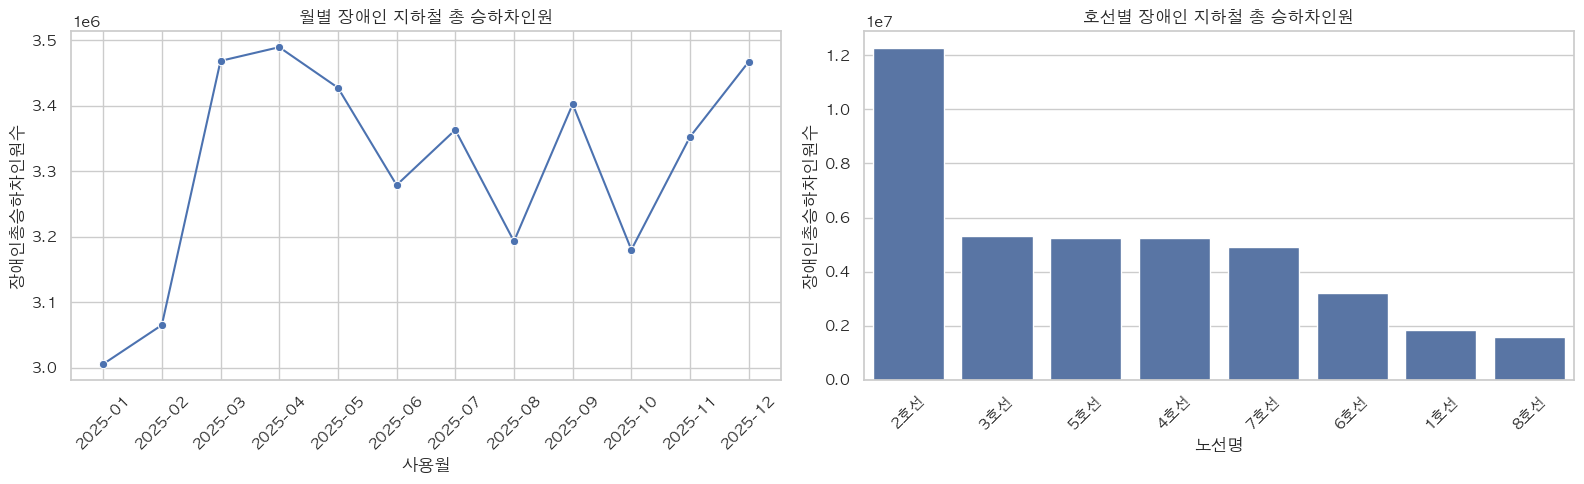

In [9]:
subway_monthly = subway.groupby('사용월', as_index=False).agg(
    장애인승차인원수=('장애인승차인원수', 'sum'),
    장애인하차인원수=('장애인하차인원수', 'sum'),
    장애인총승하차인원수=('장애인총승하차인원수', 'sum'),
)
subway_line_base = subway.copy()
subway_line_base['역표시명'] = subway_line_base['노선명'].astype(str) + ' ' + subway_line_base['역명'].astype(str)
subway_line = subway_line_base.groupby('노선명', as_index=False).agg(
    장애인총승하차인원수=('장애인총승하차인원수', 'sum'),
    역수=('역표시명', 'nunique'),
).sort_values('장애인총승하차인원수', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=subway_monthly, x='사용월', y='장애인총승하차인원수', marker='o', ax=axes[0])
axes[0].set_title('월별 장애인 지하철 총 승하차인원')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=subway_line, x='노선명', y='장애인총승하차인원수', ax=axes[1])
axes[1].set_title('호선별 장애인 지하철 총 승하차인원')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [10]:
show_result(
    '2-1-1 결과: 월별·호선별 장애인 지하철 이용 흐름',
    [
        f'분석 기간은 {ANALYSIS_START_MONTH}부터 {ANALYSIS_END_MONTH}까지이며, 월별 지하철 장애인 총 승하차인원은 최소 {subway_monthly["장애인총승하차인원수"].min():,.0f}명, 최대 {subway_monthly["장애인총승하차인원수"].max():,.0f}명이다.',
        f'가장 이용량이 많은 월은 {subway_monthly.loc[subway_monthly["장애인총승하차인원수"].idxmax(), "사용월"]}이다.',
        f'호선 기준으로는 {subway_line.iloc[0]["노선명"]}의 장애인 이용량이 가장 크다.',
    ],
    [
        '호선별·월별 이용량을 2-1-2에서 같은 기준으로 비교한다.',
        '호선별 이용량 차이가 역별·구별 수요 차이로 이어지는지 2-2와 2-3에서 확인한다.',
    ],
    conclusion='월별 전체 이용량과 호선별 총량을 함께 보면 장애인 지하철 이용은 시간 흐름과 노선 특성에 따라 차이가 난다. 다만 이 단계는 전체 흐름을 보는 분석이므로, 특정 호선의 이용량이 높은 이유를 시설·역 수·지역 연결성 중 하나로 바로 단정할 수는 없다. 따라서 다음 단계에서는 호선별 월별 이용량을 같은 기준으로 비교하고, 이후 역 단위로 내려가 실제 수요가 어느 역에 집중되는지 확인해야 한다.',
    significance='분석 기간 전체의 월별·호선별 흐름을 파악하는 데는 유의미하다. 다만 외부 요인이나 계절성을 통제한 통계 검정은 아니므로, 원인 해석보다는 이후 세부 분석의 출발점으로 활용하는 것이 적절하다.'
)


#### 2-1-1 결과: 월별·호선별 장애인 지하철 이용 흐름

**결과 해석**

- 분석 기간은 2025-01부터 2025-12까지이며, 월별 지하철 장애인 총 승하차인원은 최소 3,005,308명, 최대 3,489,308명이다.
- 가장 이용량이 많은 월은 2025-04이다.
- 호선 기준으로는 2호선의 장애인 이용량이 가장 크다.

**결론**

- 월별 전체 이용량과 호선별 총량을 함께 보면 장애인 지하철 이용은 시간 흐름과 노선 특성에 따라 차이가 난다. 다만 이 단계는 전체 흐름을 보는 분석이므로, 특정 호선의 이용량이 높은 이유를 시설·역 수·지역 연결성 중 하나로 바로 단정할 수는 없다. 따라서 다음 단계에서는 호선별 월별 이용량을 같은 기준으로 비교하고, 이후 역 단위로 내려가 실제 수요가 어느 역에 집중되는지 확인해야 한다.

**유의미성**

- 분석 기간 전체의 월별·호선별 흐름을 파악하는 데는 유의미하다. 다만 외부 요인이나 계절성을 통제한 통계 검정은 아니므로, 원인 해석보다는 이후 세부 분석의 출발점으로 활용하는 것이 적절하다.

**이 결과를 바탕으로 이어볼 분석**

- 호선별·월별 이용량을 2-1-2에서 같은 기준으로 비교한다.
- 호선별 이용량 차이가 역별·구별 수요 차이로 이어지는지 2-2와 2-3에서 확인한다.

#### 2-1-2. 호선별·월별 장애인 이용량 비교

2-1-1에서 월별 전체 흐름과 호선별 총량을 확인했으므로, 여기서는 각 호선의 월별 이용량을 같은 기준으로 비교한다.  
전월 대비 증감률이나 증감량은 사용하지 않는다. 1월·2월처럼 계절적으로 이용량이 낮은 달 때문에 3월 변화가 과하게 강조될 수 있기 때문이다.

확인 기준은 다음과 같다.

- 호선별·월별 실제 장애인 총 승하차인원을 히트맵으로 비교한다. 칸 안의 숫자는 보기 쉽게 만 명 단위로 표시한다.
- 월별로 어떤 호선의 이용량 비중이 큰지 누적 막대그래프로 확인한다.
- 이 결과를 바탕으로 2-2에서 이용량이 큰 호선의 역들이 실제로 어떤 역인지 확인한다.


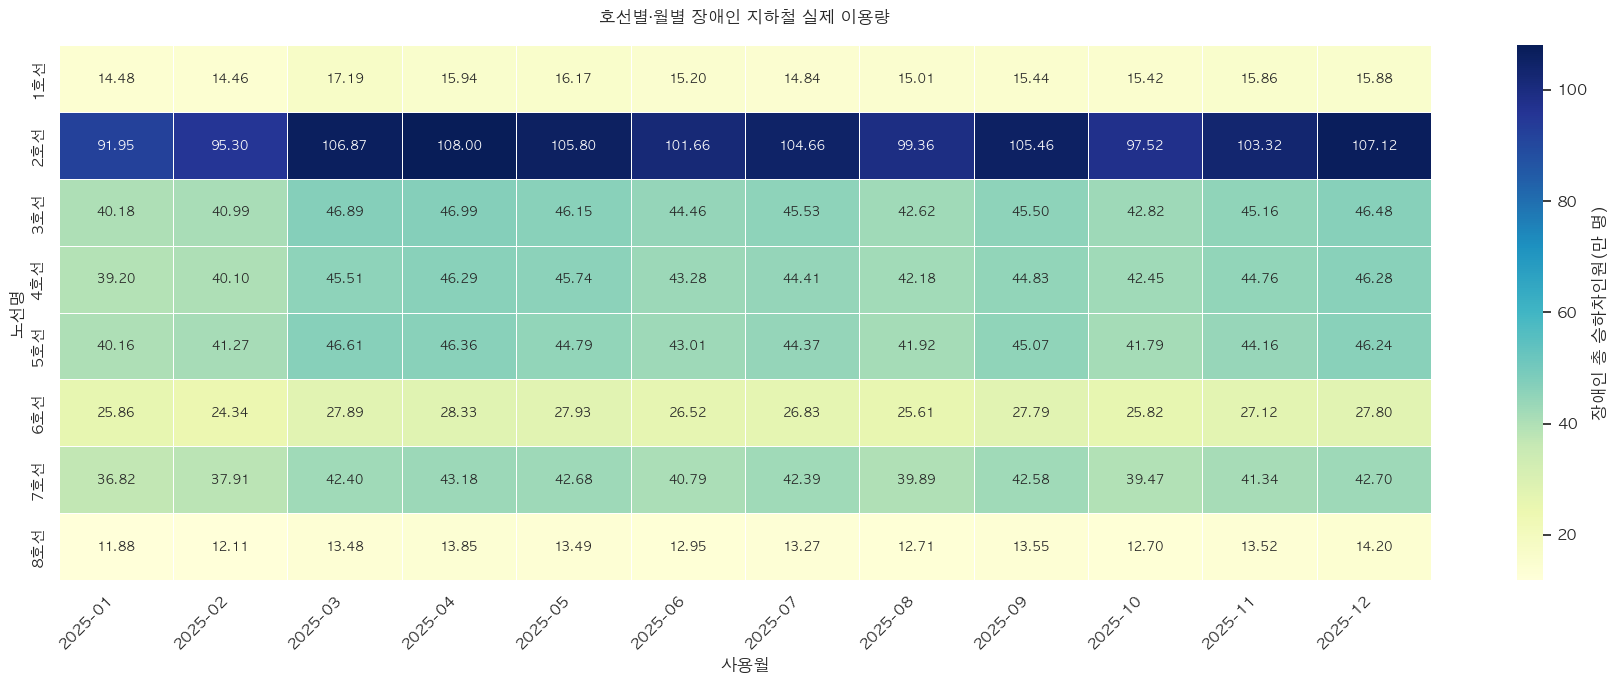

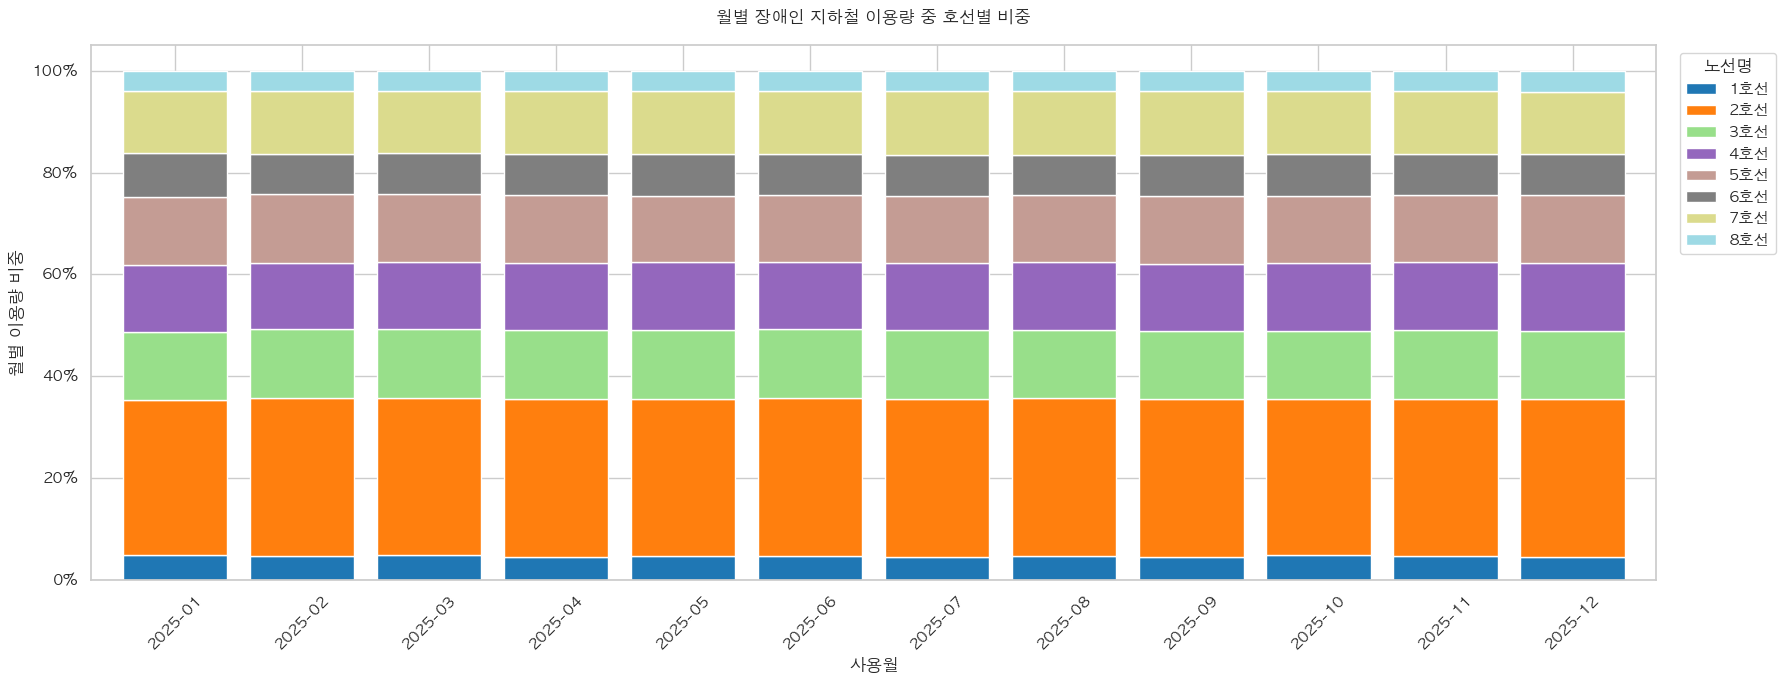

In [11]:
subway_line_monthly = subway.groupby(['사용월', '노선명'], as_index=False).agg(
    장애인총승하차인원수=('장애인총승하차인원수', 'sum')
)

line_monthly_pivot = subway_line_monthly.pivot_table(
    index='사용월',
    columns='노선명',
    values='장애인총승하차인원수',
    fill_value=0,
).reindex(ANALYSIS_MONTHS)

line_monthly_share = line_monthly_pivot.div(line_monthly_pivot.sum(axis=1), axis=0).fillna(0)
line_monthly_pivot_10k = line_monthly_pivot / 10000

plt.figure(figsize=(18, 7))
ax = sns.heatmap(
    line_monthly_pivot_10k.T,
    cmap='YlGnBu',
    linewidths=0.7,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    cbar_kws={'label': '장애인 총 승하차인원(만 명)'},
)
ax.set_title('호선별·월별 장애인 지하철 실제 이용량', pad=16)
ax.set_xlabel('사용월')
ax.set_ylabel('노선명')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(18, 7))
line_monthly_share.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.82)
ax.set_title('월별 장애인 지하철 이용량 중 호선별 비중', pad=16)
ax.set_xlabel('사용월')
ax.set_ylabel('월별 이용량 비중')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='노선명', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [12]:
top_line_by_month = line_monthly_pivot.idxmax(axis=1)
top_line_count = top_line_by_month.value_counts()
overall_top_line = subway_line.iloc[0]['노선명']

show_result(
    '2-1-2 결과: 호선별·월별 장애인 이용량 비교',
    [
        f'월별 이용량 히트맵 기준으로 각 월의 이용량 1위 호선은 {top_line_count.index[0]}이 가장 자주 나타났다({top_line_count.iloc[0]}개월).',
        f'분석 기간 전체 합계 기준 이용량이 가장 큰 호선은 {overall_top_line}이다.',
        '전월 대비 증감률/증감량은 사용하지 않고, 실제 이용량과 월별 비중으로 각 호선을 같은 기준에서 비교했다.',
    ],
    [
        '호선별 이용량 차이가 실제로 어떤 역의 높은 이용량에서 나오는지 2-2 역 단위 분석에서 확인한다.',
        '이용량이 큰 역들이 어느 구에 분포하는지 2-3 구별 분석에서 확인한다.',
    ],
    conclusion='호선별·월별 실제 이용량을 비교한 결과, 특정 호선의 이용량 우위가 한 달의 일시적 변화가 아니라 분석 기간 전반에서 반복되는지 확인할 수 있다. 이 분석은 전월 대비 증감률을 사용하지 않기 때문에 1월·2월의 낮은 이용량 때문에 3월이 과장되는 문제를 피할 수 있다. 따라서 이후 분석은 월별 변동보다 실제 이용량이 큰 호선, 특히 2호선의 역별 수요 구조를 확인하는 방향으로 이어지는 것이 적절하다.',
    significance='전월 대비가 아닌 실제 이용량과 월별 비중을 비교하므로 호선별 이용 규모 차이를 직관적으로 보는 데 유의미하다. 하지만 왜 특정 호선 이용량이 큰지까지 설명하지는 못하므로 역 수, 연결구 수, 시설 현황과 결합해야 한다.'
)


#### 2-1-2 결과: 호선별·월별 장애인 이용량 비교

**결과 해석**

- 월별 이용량 히트맵 기준으로 각 월의 이용량 1위 호선은 2호선이 가장 자주 나타났다(12개월).
- 분석 기간 전체 합계 기준 이용량이 가장 큰 호선은 2호선이다.
- 전월 대비 증감률/증감량은 사용하지 않고, 실제 이용량과 월별 비중으로 각 호선을 같은 기준에서 비교했다.

**결론**

- 호선별·월별 실제 이용량을 비교한 결과, 특정 호선의 이용량 우위가 한 달의 일시적 변화가 아니라 분석 기간 전반에서 반복되는지 확인할 수 있다. 이 분석은 전월 대비 증감률을 사용하지 않기 때문에 1월·2월의 낮은 이용량 때문에 3월이 과장되는 문제를 피할 수 있다. 따라서 이후 분석은 월별 변동보다 실제 이용량이 큰 호선, 특히 2호선의 역별 수요 구조를 확인하는 방향으로 이어지는 것이 적절하다.

**유의미성**

- 전월 대비가 아닌 실제 이용량과 월별 비중을 비교하므로 호선별 이용 규모 차이를 직관적으로 보는 데 유의미하다. 하지만 왜 특정 호선 이용량이 큰지까지 설명하지는 못하므로 역 수, 연결구 수, 시설 현황과 결합해야 한다.

**이 결과를 바탕으로 이어볼 분석**

- 호선별 이용량 차이가 실제로 어떤 역의 높은 이용량에서 나오는지 2-2 역 단위 분석에서 확인한다.
- 이용량이 큰 역들이 어느 구에 분포하는지 2-3 구별 분석에서 확인한다.

#### 2-1-3. 2호선 이용량이 큰 이유 탐색: 노선 규모와 접근성 시설 비교

2-1-1과 2-1-2에서 2호선의 장애인 이용량이 크게 나타났으므로, 여기서는 그 이유를 두 방향으로 나누어 확인한다.

- 노선 규모 요인: 분석 대상 역 수, 연결되는 구 수, 역당 평균 이용량
- 접근성 시설 요인: 역당 운행 엘리베이터 수, 역당 휠체어리프트 수, 역당 안전발판 수

이 분석은 2호선 이용량이 큰 이유를 확정하는 인과분석이 아니라, 2호선의 높은 이용량이 `시설이 많아서인지`, `역과 연결 지역이 많아서인지`, 또는 `두 요인이 함께 나타나는지`를 탐색하기 위한 비교이다.


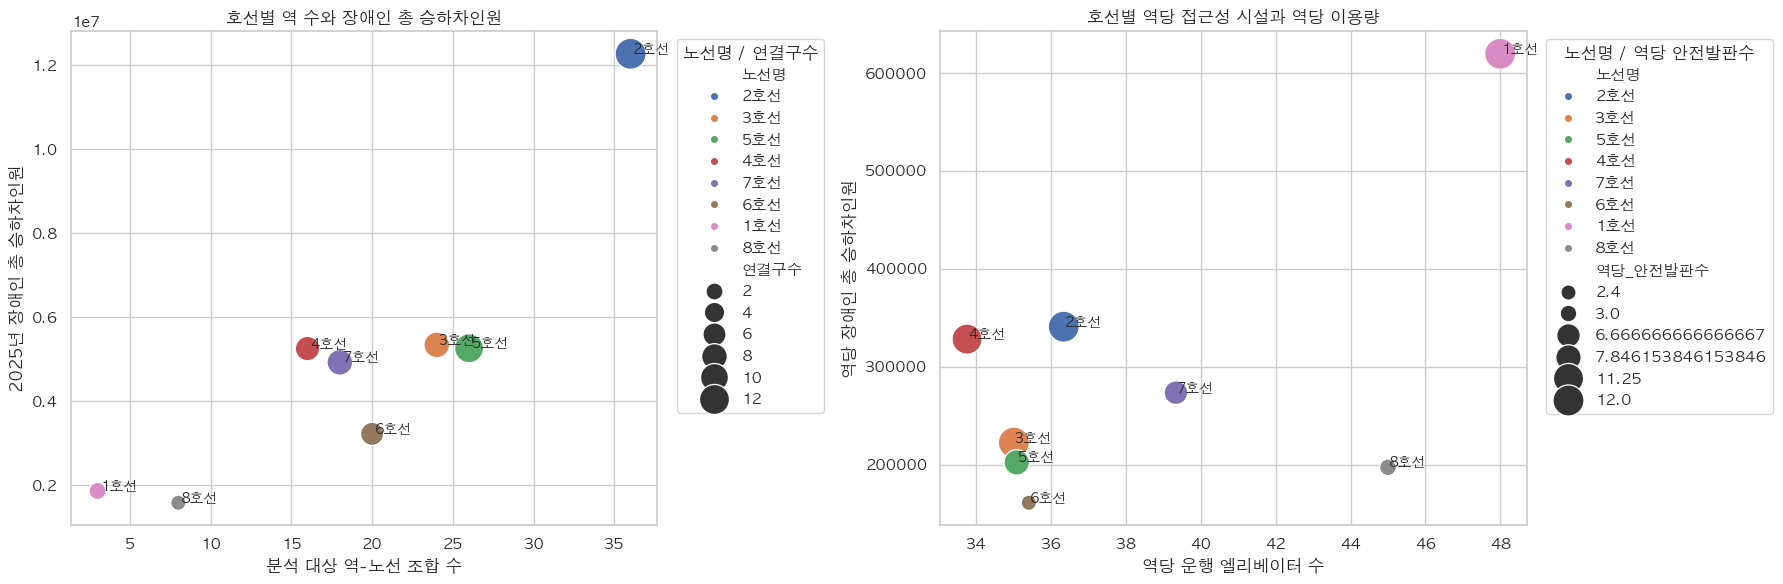

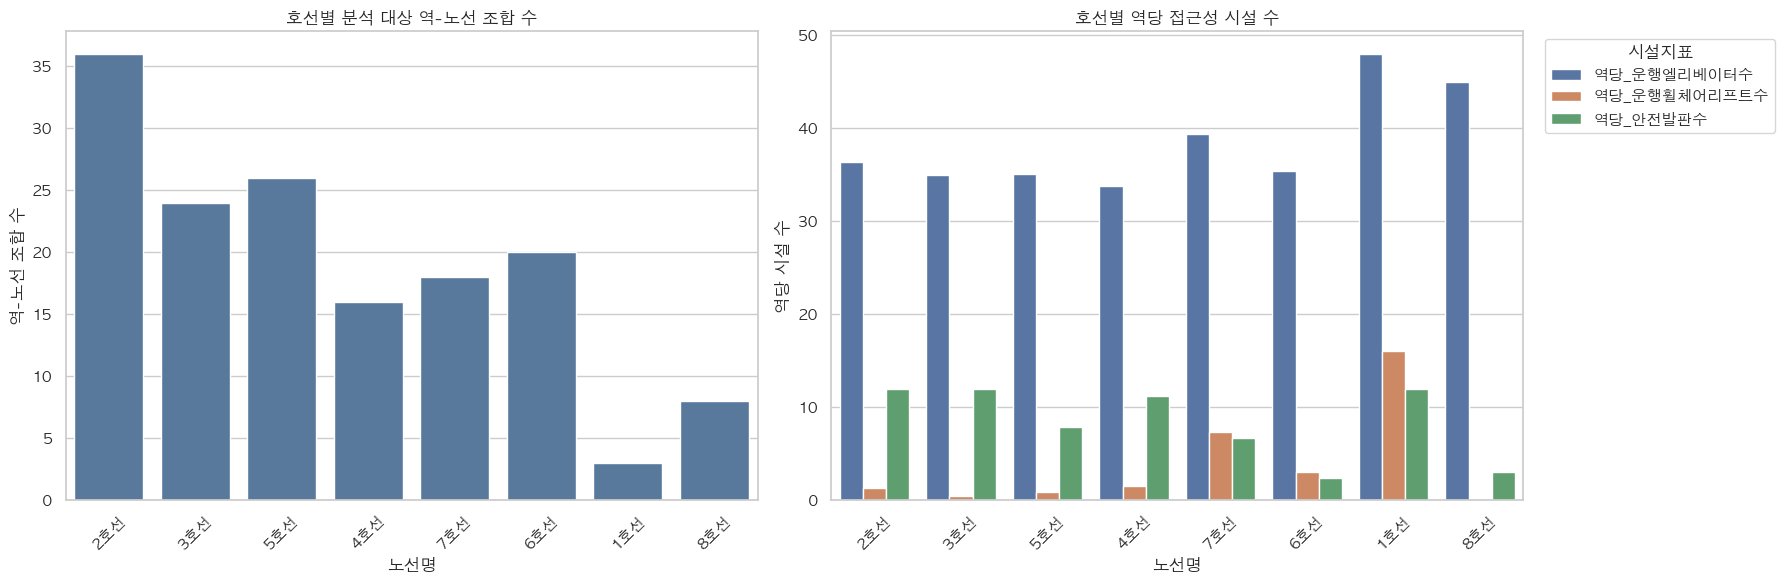

In [13]:
line_reason_base = subway.copy()
line_reason_base['역표시명'] = line_reason_base['노선명'].astype(str) + ' ' + line_reason_base['역명'].astype(str)
line_reason = line_reason_base.groupby('노선명', as_index=False).agg(
    장애인총승하차인원수=('장애인총승하차인원수', 'sum'),
    역수=('역표시명', 'nunique'),
    연결구수=('지역명', 'nunique'),
    운행엘리베이터수=('운행엘리베이터수', 'sum'),
    운행휠체어리프트수=('운행휠체어리프트수', 'sum'),
    안전발판수=('안전발판수', 'sum'),
)
line_reason['역당_장애인승하차인원수'] = line_reason['장애인총승하차인원수'] / line_reason['역수']
line_reason['역당_운행엘리베이터수'] = line_reason['운행엘리베이터수'] / line_reason['역수']
line_reason['역당_운행휠체어리프트수'] = line_reason['운행휠체어리프트수'] / line_reason['역수']
line_reason['역당_안전발판수'] = line_reason['안전발판수'] / line_reason['역수']
line_reason = line_reason.sort_values('장애인총승하차인원수', ascending=False).reset_index(drop=True)

line_reason_long = line_reason.melt(
    id_vars='노선명',
    value_vars=['역수', '연결구수', '역당_장애인승하차인원수', '역당_운행엘리베이터수', '역당_운행휠체어리프트수', '역당_안전발판수'],
    var_name='비교지표',
    value_name='값',
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.scatterplot(
    data=line_reason,
    x='역수',
    y='장애인총승하차인원수',
    size='연결구수',
    hue='노선명',
    sizes=(120, 500),
    ax=axes[0],
)
for _, row in line_reason.iterrows():
    axes[0].text(row['역수'] + 0.15, row['장애인총승하차인원수'], row['노선명'], fontsize=10)
axes[0].set_title('호선별 역 수와 장애인 총 승하차인원')
axes[0].set_xlabel('분석 대상 역-노선 조합 수')
axes[0].set_ylabel('2025년 장애인 총 승하차인원')
axes[0].legend(title='노선명 / 연결구수', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.scatterplot(
    data=line_reason,
    x='역당_운행엘리베이터수',
    y='역당_장애인승하차인원수',
    size='역당_안전발판수',
    hue='노선명',
    sizes=(120, 500),
    ax=axes[1],
)
for _, row in line_reason.iterrows():
    axes[1].text(row['역당_운행엘리베이터수'] + 0.03, row['역당_장애인승하차인원수'], row['노선명'], fontsize=10)
axes[1].set_title('호선별 역당 접근성 시설과 역당 이용량')
axes[1].set_xlabel('역당 운행 엘리베이터 수')
axes[1].set_ylabel('역당 장애인 총 승하차인원')
axes[1].legend(title='노선명 / 역당 안전발판수', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=line_reason, x='노선명', y='역수', ax=axes[0], color='#4C78A8')
axes[0].set_title('호선별 분석 대상 역-노선 조합 수')
axes[0].set_xlabel('노선명')
axes[0].set_ylabel('역-노선 조합 수')
axes[0].tick_params(axis='x', rotation=45)

facility_per_station = line_reason.melt(
    id_vars='노선명',
    value_vars=['역당_운행엘리베이터수', '역당_운행휠체어리프트수', '역당_안전발판수'],
    var_name='시설지표',
    value_name='역당시설수',
)
sns.barplot(data=facility_per_station, x='노선명', y='역당시설수', hue='시설지표', ax=axes[1])
axes[1].set_title('호선별 역당 접근성 시설 수')
axes[1].set_xlabel('노선명')
axes[1].set_ylabel('역당 시설 수')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='시설지표', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [14]:
line2_reason = line_reason.loc[line_reason['노선명'].eq('2호선')].iloc[0]
line2_station_rank = int(line_reason['역수'].rank(ascending=False, method='min')[line_reason['노선명'].eq('2호선')].iloc[0])
line2_total_rank = int(line_reason['장애인총승하차인원수'].rank(ascending=False, method='min')[line_reason['노선명'].eq('2호선')].iloc[0])
line2_ev_rank = int(line_reason['역당_운행엘리베이터수'].rank(ascending=False, method='min')[line_reason['노선명'].eq('2호선')].iloc[0])
line2_lift_rank = int(line_reason['역당_운행휠체어리프트수'].rank(ascending=False, method='min')[line_reason['노선명'].eq('2호선')].iloc[0])

show_result(
    '2-1-3 결과: 2호선 이용량이 큰 이유 탐색',
    [
        f'2호선은 장애인 총 승하차인원 기준 {line2_total_rank}위이고, 분석 대상 역 수는 {line2_reason["역수"]:.0f}개로 {line2_station_rank}위이다.',
        f'2호선의 연결 구 수는 {line2_reason["연결구수"]:.0f}개이며, 역당 장애인 총 승하차인원은 {line2_reason["역당_장애인승하차인원수"]:,.0f}명이다.',
        f'접근성 시설은 역당 운행 엘리베이터 수 {line2_reason["역당_운행엘리베이터수"]:.2f}개({line2_ev_rank}위), 역당 운행 휠체어리프트 수 {line2_reason["역당_운행휠체어리프트수"]:.2f}개({line2_lift_rank}위)로 비교했다.',
        '따라서 2호선 이용량은 접근성 시설 하나만으로 설명하기보다, 역 수와 연결 지역이 많은 노선 규모 요인과 역당 이용량을 함께 봐야 한다.',
    ],
    [
        '2-2에서 2호선 안에서도 어떤 역이 실제 이용량을 크게 만드는지 역 단위로 확인한다.',
        '2-3에서 2호선 주요 역들이 어느 구의 지하철 수요를 키우는지 지역 단위로 확인한다.',
    ],
    conclusion='2호선의 높은 이용량은 단순히 엘리베이터나 휠체어리프트가 많기 때문이라고 보기 어렵다. 2호선은 분석 대상 역 수와 연결 구 수가 많아 갈 수 있는 지역 자체가 넓고, 그만큼 장애인권종 승하차가 발생할 기회도 많다. 따라서 2호선은 접근성 시설의 영향과 노선 규모의 영향이 함께 나타나는 노선으로 해석해야 하며, 다음 분석에서는 2호선 내부에서도 어떤 역이 실제 이용량을 크게 만드는지 확인해야 한다.',
    significance='2호선의 높은 이용량을 시설 요인과 노선 규모 요인으로 나눠 보는 데 유의미하다. 단, 상관·비교 분석 수준이므로 시설이 많아서 이용량이 증가했다고 인과적으로 단정할 수는 없다.'
)


#### 2-1-3 결과: 2호선 이용량이 큰 이유 탐색

**결과 해석**

- 2호선은 장애인 총 승하차인원 기준 1위이고, 분석 대상 역 수는 36개로 1위이다.
- 2호선의 연결 구 수는 13개이며, 역당 장애인 총 승하차인원은 340,842명이다.
- 접근성 시설은 역당 운행 엘리베이터 수 36.33개(4위), 역당 운행 휠체어리프트 수 1.33개(5위)로 비교했다.
- 따라서 2호선 이용량은 접근성 시설 하나만으로 설명하기보다, 역 수와 연결 지역이 많은 노선 규모 요인과 역당 이용량을 함께 봐야 한다.

**결론**

- 2호선의 높은 이용량은 단순히 엘리베이터나 휠체어리프트가 많기 때문이라고 보기 어렵다. 2호선은 분석 대상 역 수와 연결 구 수가 많아 갈 수 있는 지역 자체가 넓고, 그만큼 장애인권종 승하차가 발생할 기회도 많다. 따라서 2호선은 접근성 시설의 영향과 노선 규모의 영향이 함께 나타나는 노선으로 해석해야 하며, 다음 분석에서는 2호선 내부에서도 어떤 역이 실제 이용량을 크게 만드는지 확인해야 한다.

**유의미성**

- 2호선의 높은 이용량을 시설 요인과 노선 규모 요인으로 나눠 보는 데 유의미하다. 단, 상관·비교 분석 수준이므로 시설이 많아서 이용량이 증가했다고 인과적으로 단정할 수는 없다.

**이 결과를 바탕으로 이어볼 분석**

- 2-2에서 2호선 안에서도 어떤 역이 실제 이용량을 크게 만드는지 역 단위로 확인한다.
- 2-3에서 2호선 주요 역들이 어느 구의 지하철 수요를 키우는지 지역 단위로 확인한다.

### 2-2. 역 단위 장애인 지하철 이용량 분석

#### 2-2-1. 역-노선 조합 기준 장애인 이용량 비교

이번 수정부터는 같은 역명이라도 호선이 다르면 다른 역으로 본다. 예를 들어 `시청(1호선)`과 `시청(2호선)`은 이동 동선, 승강장, 엘리베이터 위치가 다를 수 있으므로 하나로 합치지 않는다.

그래프와 표는 전체 역을 길게 모두 나열하지 않고, 보기 쉽게 상위 5개와 하위 5개만 보여준다.

- 기준 단위: `노선명 + 역명`
- 상위 5개: 장애인 총 승하차인원이 가장 많은 역-노선 조합
- 하위 5개: 장애인 총 승하차인원이 가장 적은 역-노선 조합
- 분포 그래프: 전체 경향을 보기 위한 히스토그램/박스플롯만 유지


분석 대상 전체 역-노선 조합 수: 151개
같은 역명이라도 호선이 다르면 별도 조합으로 계산한다. 고유 역명 수: 133개


,구분,전체순위,노선명,역명,지역명,행정동명,장애인총승하차인원수,장애인총승하차인원수_만명,운행엘리베이터수,안전발판수
0,상위 5개,1,1호선,서울역,중구,회현동,1064429,106.4429,4,1
1,상위 5개,2,2호선,신도림,구로구,신도림동,896846,89.6846,4,1
2,상위 5개,3,2호선,신림,관악구,서원동,894073,89.4073,3,1
3,상위 5개,4,2호선,잠실(송파구청),송파구,잠실6동,763306,76.3306,4,1
4,상위 5개,5,2호선,선릉,강남구,삼성2동,696988,69.6988,3,1
5,하위 5개,151,6호선,삼각지(전쟁기념관),용산구,한강로동,16455,1.6455,5,0
6,하위 5개,150,4호선,삼각지(전쟁기념관),용산구,한강로동,21176,2.1176,5,1
7,하위 5개,149,4호선,남태령,서초구,방배2동,22795,2.2795,3,1
8,하위 5개,148,2호선,신답,성동구,용답동,31022,3.1022,2,1
9,하위 5개,147,2호선,도림천,구로구,신도림동,33742,3.3742,2,1


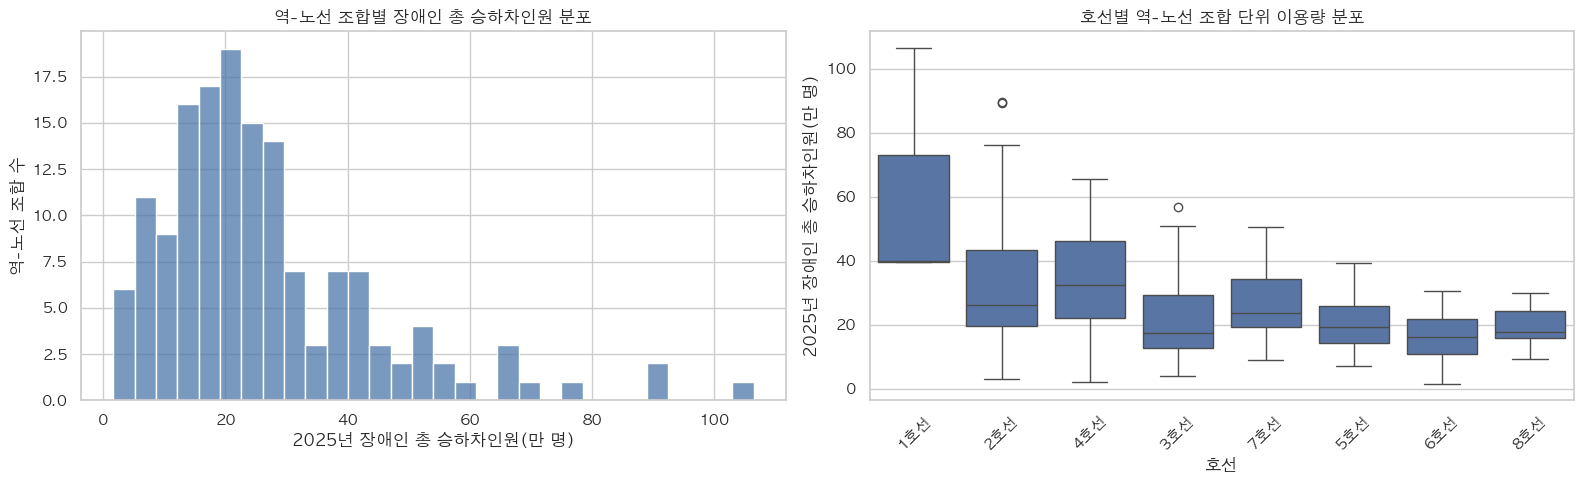

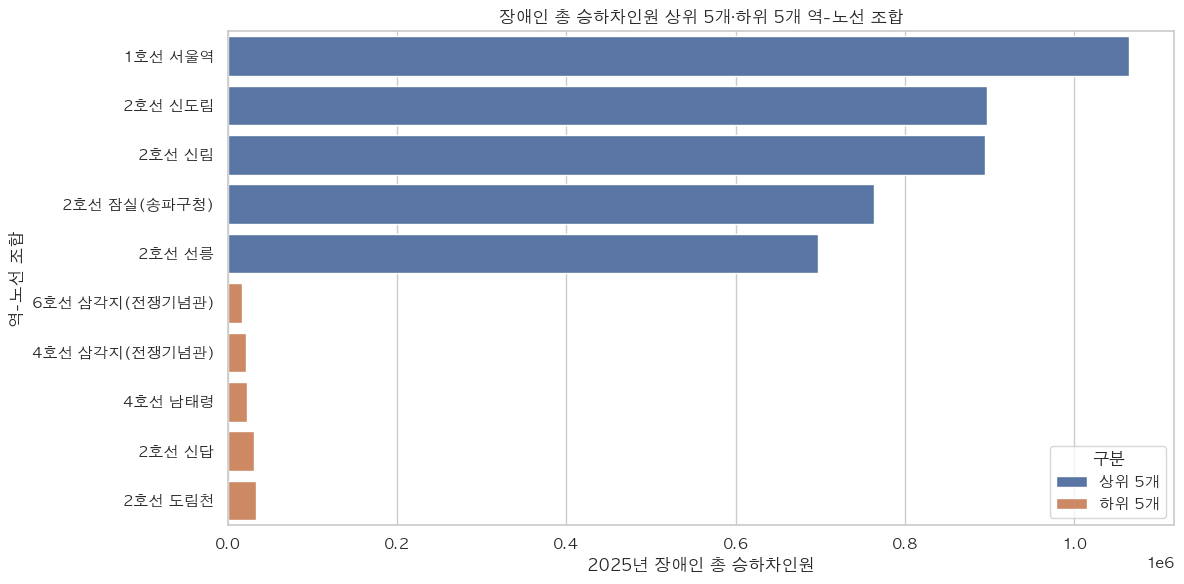

In [15]:
station_demand = subway.groupby(['노선명', '역명', '지역명', '행정동명'], as_index=False).agg(
    장애인총승하차인원수=('장애인총승하차인원수', 'sum'),
    장애인월평균승하차인원수=('장애인총승하차인원수', 'mean'),
    운행엘리베이터수=('운행엘리베이터수', 'max'),
    휠체어리프트수=('휠체어리프트수', 'max'),
    안전발판수=('안전발판수', 'max'),
    휠체어접근가능화장실수=('휠체어접근가능화장실수', 'max'),
    휠체어급속충전기수=('휠체어급속충전기수', 'max'),
).sort_values('장애인총승하차인원수', ascending=False).reset_index(drop=True)

station_demand['전체순위'] = np.arange(1, len(station_demand) + 1)
station_demand['호선내순위'] = station_demand.groupby('노선명')['장애인총승하차인원수'].rank(
    ascending=False, method='min'
).astype('int64')
station_demand['역표시명'] = station_demand['노선명'] + ' ' + station_demand['역명']
station_demand['장애인총승하차인원수_만명'] = station_demand['장애인총승하차인원수'] / 10000

station_top5 = station_demand.nlargest(5, '장애인총승하차인원수').copy()
station_bottom5 = station_demand.nsmallest(5, '장애인총승하차인원수').copy()
station_top_bottom = pd.concat([
    station_top5.assign(구분='상위 5개'),
    station_bottom5.assign(구분='하위 5개'),
], ignore_index=True)

print(f'분석 대상 전체 역-노선 조합 수: {len(station_demand):,}개')
print(f'같은 역명이라도 호선이 다르면 별도 조합으로 계산한다. 고유 역명 수: {station_demand["역명"].nunique():,}개')

display(station_top_bottom[[
    '구분', '전체순위', '노선명', '역명', '지역명', '행정동명',
    '장애인총승하차인원수', '장애인총승하차인원수_만명', '운행엘리베이터수', '안전발판수'
]])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(data=station_demand, x='장애인총승하차인원수_만명', bins=30, ax=axes[0], color='#4C78A8')
axes[0].set_title('역-노선 조합별 장애인 총 승하차인원 분포')
axes[0].set_xlabel('2025년 장애인 총 승하차인원(만 명)')
axes[0].set_ylabel('역-노선 조합 수')

sns.boxplot(data=station_demand, x='노선명', y='장애인총승하차인원수_만명', ax=axes[1])
axes[1].set_title('호선별 역-노선 조합 단위 이용량 분포')
axes[1].set_xlabel('호선')
axes[1].set_ylabel('2025년 장애인 총 승하차인원(만 명)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=station_top_bottom, y='역표시명', x='장애인총승하차인원수', hue='구분', dodge=False)
plt.title('장애인 총 승하차인원 상위 5개·하위 5개 역-노선 조합')
plt.xlabel('2025년 장애인 총 승하차인원')
plt.ylabel('역-노선 조합')
plt.tight_layout()
plt.show()


In [16]:
top_station = station_top5.iloc[0]
bottom_station = station_bottom5.iloc[0]
transfer_name_count = int((station_demand.groupby('역명')['노선명'].nunique() > 1).sum())
show_result(
    '2-2-1 결과: 역-노선 조합 기준 장애인 이용량 비교',
    [
        f'분석 대상은 총 {len(station_demand):,}개 역-노선 조합이다. 고유 역명 기준으로는 {station_demand["역명"].nunique():,}개이며, 여러 호선에 걸친 역명은 {transfer_name_count:,}개다.',
        f'장애인 총 승하차인원이 가장 많은 조합은 {top_station["역명"]}({top_station["노선명"]})이며, 총 {top_station["장애인총승하차인원수"]:,.0f}명이다.',
        f'장애인 총 승하차인원이 가장 적은 조합은 {bottom_station["역명"]}({bottom_station["노선명"]})이며, 총 {bottom_station["장애인총승하차인원수"]:,.0f}명이다.',
        '같은 역명이라도 호선이 다르면 승강장과 접근성 시설 조건이 다를 수 있어 별도 조합으로 보는 것이 더 적절하다.',
    ],
    [
        '상위 5개와 하위 5개 조합의 시설 현황을 비교한다.',
        '역-노선 조합 기준으로 구별 집계와 시설 부담 분석을 다시 계산한다.',
    ],
    conclusion='역명을 하나로 합치면 환승역의 호선별 차이가 사라질 수 있다. 역-노선 조합 기준으로 보면 같은 역명 안에서도 호선별 이용량과 시설 조건이 다르게 나타날 수 있으므로, 이후 접근성 분석은 이 기준을 유지하는 것이 맞다.',
    significance='호선별 승강장과 시설 동선 차이를 반영할 수 있어, 장애인 네비게이터 관점에서 더 현실적인 분석 단위가 된다.'
)


#### 2-2-1 결과: 역-노선 조합 기준 장애인 이용량 비교

**결과 해석**

- 분석 대상은 총 151개 역-노선 조합이다. 고유 역명 기준으로는 133개이며, 여러 호선에 걸친 역명은 18개다.
- 장애인 총 승하차인원이 가장 많은 조합은 서울역(1호선)이며, 총 1,064,429명이다.
- 장애인 총 승하차인원이 가장 적은 조합은 삼각지(전쟁기념관)(6호선)이며, 총 16,455명이다.
- 같은 역명이라도 호선이 다르면 승강장과 접근성 시설 조건이 다를 수 있어 별도 조합으로 보는 것이 더 적절하다.

**결론**

- 역명을 하나로 합치면 환승역의 호선별 차이가 사라질 수 있다. 역-노선 조합 기준으로 보면 같은 역명 안에서도 호선별 이용량과 시설 조건이 다르게 나타날 수 있으므로, 이후 접근성 분석은 이 기준을 유지하는 것이 맞다.

**유의미성**

- 호선별 승강장과 시설 동선 차이를 반영할 수 있어, 장애인 네비게이터 관점에서 더 현실적인 분석 단위가 된다.

**이 결과를 바탕으로 이어볼 분석**

- 상위 5개와 하위 5개 조합의 시설 현황을 비교한다.
- 역-노선 조합 기준으로 구별 집계와 시설 부담 분석을 다시 계산한다.

#### 2-2-2. 상위 5개·하위 5개 역-노선 조합의 시설 현황 확인

2-2-1에서 계산한 역-노선 조합 중 이용량 상위 5개와 하위 5개만 비교한다.

전체 역을 모두 표로 보여주면 읽기 어렵기 때문에, 여기서는 다음만 확인한다.

- 장애인 이용량 상위 5개 역-노선 조합의 시설 현황
- 장애인 이용량 하위 5개 역-노선 조합의 시설 현황
- 구별 역-노선 조합 수 분포

주의: 시설 수가 많다는 사실만으로 접근성이 충분하다고 단정하지 않는다. 역 규모와 이용량이 큰 환승역은 시설 수요도 함께 크기 때문에, 시설 현황은 이용량과 함께 해석한다.


,구분,이용량순위,노선명,역명,지역표시명,장애인총승하차인원수,총이용량_만명,운행엘리베이터수,휠체어리프트수,안전발판수,휠체어접근가능화장실수,휠체어급속충전기수,접근성시설합계,시설없는항목수
0,상위 5개,1,1호선,서울역,중구,1064429,106.4429,4,0,1,1,0,6,2
1,상위 5개,2,2호선,신도림,구로구,896846,89.6846,4,0,1,2,1,8,1
2,상위 5개,3,2호선,신림,관악구,894073,89.4073,3,0,1,1,0,5,2
3,상위 5개,4,2호선,잠실(송파구청),송파구,763306,76.3306,4,1,1,1,0,7,1
4,상위 5개,5,2호선,선릉,강남구,696988,69.6988,3,0,1,1,1,6,1
5,하위 5개,151,6호선,삼각지(전쟁기념관),용산구,16455,1.6455,5,0,0,0,0,5,4
6,하위 5개,150,4호선,삼각지(전쟁기념관),용산구,21176,2.1176,5,0,1,1,1,8,1
7,하위 5개,149,4호선,남태령,서초구,22795,2.2795,3,0,1,1,0,5,2
8,하위 5개,148,2호선,신답,성동구,31022,3.1022,2,0,1,1,0,4,2
9,하위 5개,147,2호선,도림천,구로구,33742,3.3742,2,0,1,0,0,3,3


,지역표시명,역노선조합수,전체역총이용량,평균접근성시설수,시설없는항목평균,구분
0,송파구,21,4330367,5.428571,2.095238,역-노선 조합 수 상위 5개 구
1,강남구,14,3387404,5.071429,2.142857,역-노선 조합 수 상위 5개 구
2,중구,13,4363819,4.615385,2.153846,역-노선 조합 수 상위 5개 구
3,서초구,13,3528251,5.923077,1.692308,역-노선 조합 수 상위 5개 구
4,마포구,13,2863372,5.384615,1.769231,역-노선 조합 수 상위 5개 구
5,금천구,1,505802,8.000000,2.000000,역-노선 조합 수 하위 5개 구
6,동작구,1,330897,5.000000,3.000000,역-노선 조합 수 하위 5개 구
7,강동구,1,246482,4.000000,3.000000,역-노선 조합 수 하위 5개 구
8,중랑구,2,552778,5.500000,1.500000,역-노선 조합 수 하위 5개 구
9,강서구,2,428383,6.000000,2.500000,역-노선 조합 수 하위 5개 구


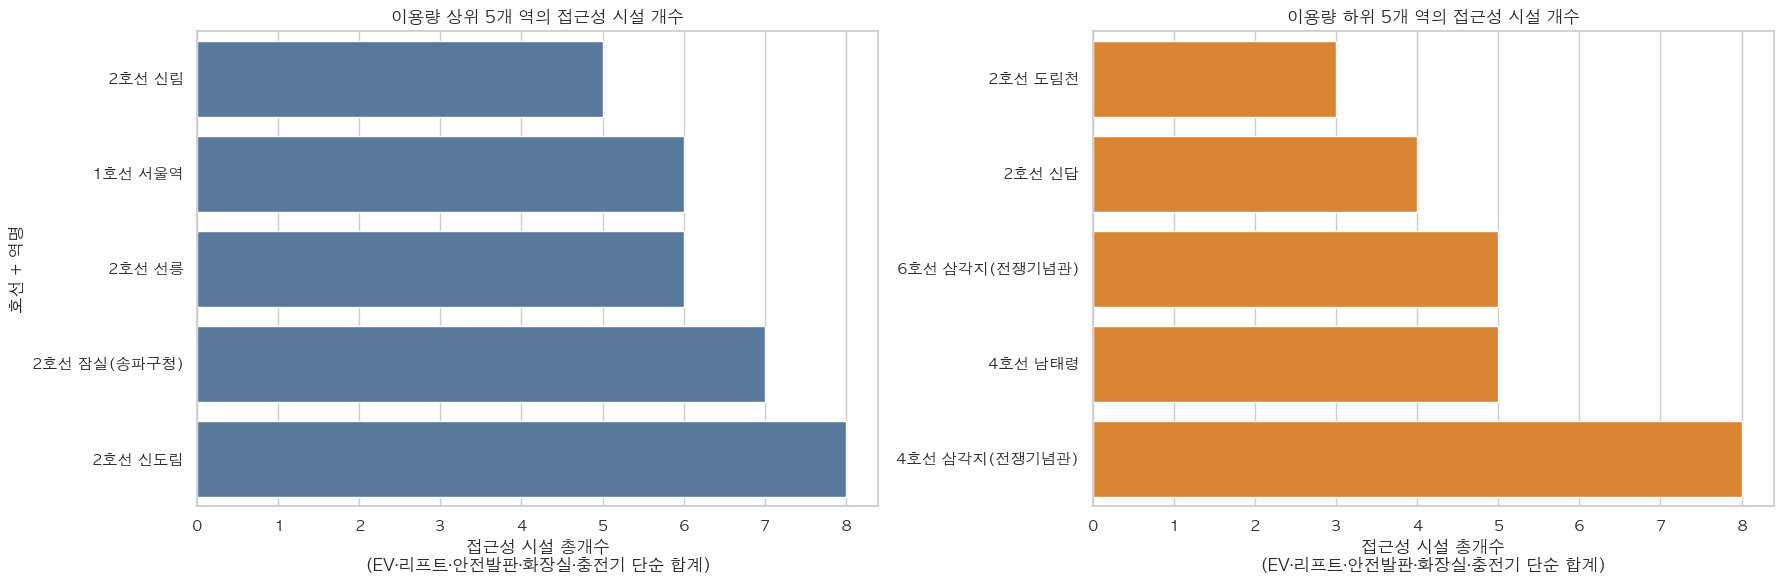

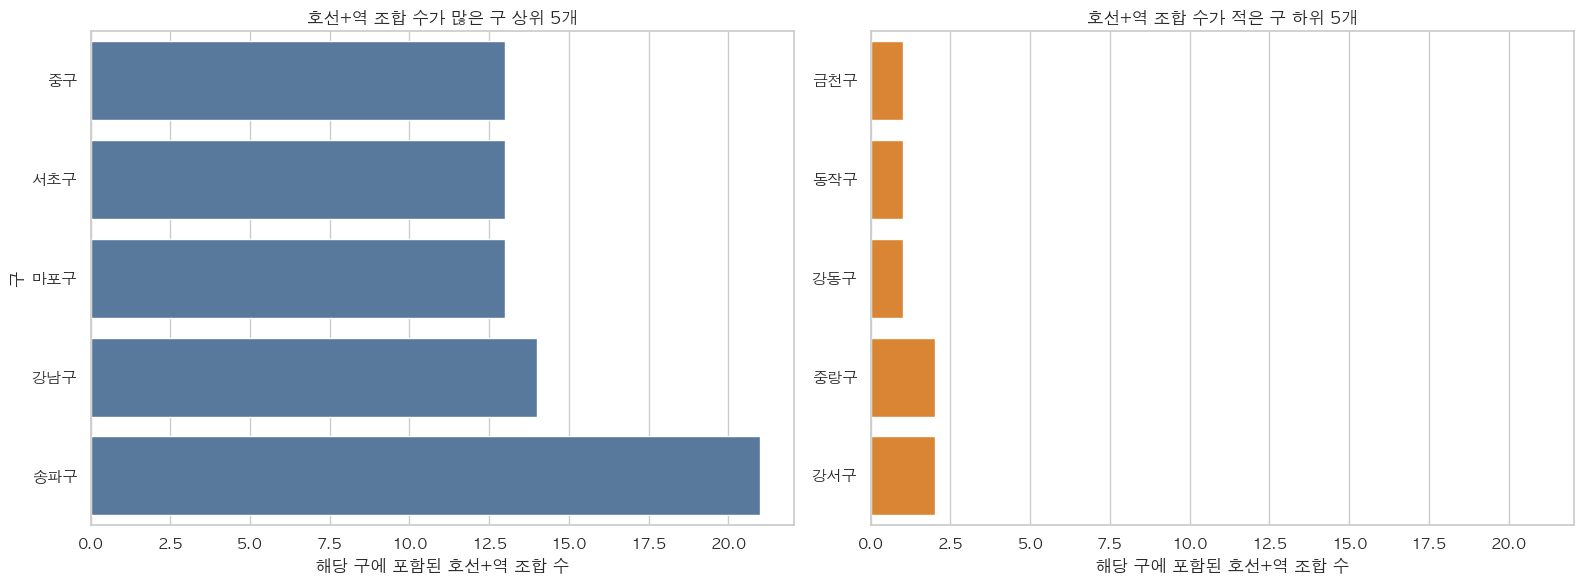

In [17]:
high_demand_stations = station_demand.sort_values('장애인총승하차인원수', ascending=False).copy()
high_demand_stations['이용량순위'] = np.arange(1, len(high_demand_stations) + 1)
high_demand_stations['총이용량_만명'] = high_demand_stations['장애인총승하차인원수'] / 10000

facility_columns = [
    '운행엘리베이터수',
    '휠체어리프트수',
    '안전발판수',
    '휠체어접근가능화장실수',
    '휠체어급속충전기수',
]
for column in facility_columns:
    high_demand_stations[column] = pd.to_numeric(high_demand_stations[column], errors='coerce').fillna(0)

high_demand_stations['접근성시설합계'] = high_demand_stations[facility_columns].sum(axis=1)
high_demand_stations['시설없는항목수'] = high_demand_stations[facility_columns].eq(0).sum(axis=1)
high_demand_stations['지역표시명'] = high_demand_stations['지역명'].fillna('지역 미상')
high_demand_stations['역표시명'] = high_demand_stations['노선명'] + ' ' + high_demand_stations['역명']

station_display_columns = [
    '구분', '이용량순위', '노선명', '역명', '지역표시명',
    '장애인총승하차인원수', '총이용량_만명',
    *facility_columns, '접근성시설합계', '시설없는항목수',
]
facility_top_bottom = pd.concat([
    high_demand_stations.head(5).assign(구분='상위 5개'),
    high_demand_stations.tail(5).sort_values('장애인총승하차인원수').assign(구분='하위 5개'),
], ignore_index=True)

display(facility_top_bottom[station_display_columns])

high_demand_by_district = (
    high_demand_stations.groupby('지역표시명', as_index=False)
    .agg(
        역노선조합수=('역표시명', 'count'),
        전체역총이용량=('장애인총승하차인원수', 'sum'),
        평균접근성시설수=('접근성시설합계', 'mean'),
        시설없는항목평균=('시설없는항목수', 'mean'),
    )
    .sort_values(['역노선조합수', '전체역총이용량'], ascending=[False, False])
)

district_top_bottom = pd.concat([
    high_demand_by_district.head(5).assign(구분='역-노선 조합 수 상위 5개 구'),
    high_demand_by_district.tail(5).sort_values('역노선조합수').assign(구분='역-노선 조합 수 하위 5개 구'),
], ignore_index=True)
display(district_top_bottom)

facility_top_plot = facility_top_bottom[facility_top_bottom['구분'].eq('상위 5개')].sort_values('접근성시설합계', ascending=True)
facility_bottom_plot = facility_top_bottom[facility_top_bottom['구분'].eq('하위 5개')].sort_values('접근성시설합계', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
sns.barplot(data=facility_top_plot, y='역표시명', x='접근성시설합계', color='#4C78A8', ax=axes[0])
axes[0].set_title('이용량 상위 5개 역의 접근성 시설 개수')
axes[0].set_xlabel('접근성 시설 총개수\n(EV·리프트·안전발판·화장실·충전기 단순 합계)')
axes[0].set_ylabel('호선 + 역명')

sns.barplot(data=facility_bottom_plot, y='역표시명', x='접근성시설합계', color='#F58518', ax=axes[1])
axes[1].set_title('이용량 하위 5개 역의 접근성 시설 개수')
axes[1].set_xlabel('접근성 시설 총개수\n(EV·리프트·안전발판·화장실·충전기 단순 합계)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

district_top_plot = district_top_bottom[district_top_bottom['구분'].eq('역-노선 조합 수 상위 5개 구')].sort_values('역노선조합수', ascending=True)
district_bottom_plot = district_top_bottom[district_top_bottom['구분'].eq('역-노선 조합 수 하위 5개 구')].sort_values('역노선조합수', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
sns.barplot(data=district_top_plot, y='지역표시명', x='역노선조합수', color='#4C78A8', ax=axes[0])
axes[0].set_title('호선+역 조합 수가 많은 구 상위 5개')
axes[0].set_xlabel('해당 구에 포함된 호선+역 조합 수')
axes[0].set_ylabel('구')

sns.barplot(data=district_bottom_plot, y='지역표시명', x='역노선조합수', color='#F58518', ax=axes[1])
axes[1].set_title('호선+역 조합 수가 적은 구 하위 5개')
axes[1].set_xlabel('해당 구에 포함된 호선+역 조합 수')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


In [18]:
station_facility_candidates = high_demand_stations[
    ['이용량순위', '노선명', '역명', '지역표시명', '장애인총승하차인원수', '접근성시설합계', '시설없는항목수']
].sort_values(['시설없는항목수', '장애인총승하차인원수'], ascending=[False, False])

station_facility_candidates_top_bottom = pd.concat([
    station_facility_candidates.head(5).assign(구분='시설없는항목수 상위 5개'),
    station_facility_candidates.tail(5).sort_values('시설없는항목수').assign(구분='시설없는항목수 하위 5개'),
], ignore_index=True)

best_facility_station = high_demand_stations.sort_values('접근성시설합계', ascending=False).iloc[0]
show_result(
    '2-2-2 결과: 상위·하위 역-노선 조합 시설 현황',
    [
        f'전체 분석 대상은 {len(high_demand_stations):,}개 역-노선 조합이며, 역-노선 조합 수가 가장 많은 구는 {high_demand_by_district.iloc[0]["지역표시명"]}이다.' if len(high_demand_by_district) else '전체 역의 구별 분포를 계산하지 못했다.',
        f'시설 합계가 가장 큰 역-노선 조합은 {best_facility_station["역명"]}({best_facility_station["노선명"]})이다.',
        '전체 역을 모두 나열하지 않고 이용량 상위 5개·하위 5개, 시설없는항목수 상위 5개·하위 5개만 표시했다.',
    ],
    [
        '시설이 없는 항목 수가 큰 역-노선 조합을 우선 점검한다.',
        '역별 이용량 대비 시설 수를 계산해 시설 부담이 큰 조합을 비교한다.',
    ],
    conclusion='상위 5개와 하위 5개만 비교해도 이용량과 시설 현황의 차이를 더 읽기 쉽게 확인할 수 있다. 전체 역을 모두 나열하는 방식보다 보고서에서는 핵심 조합만 보여주는 방식이 적절하다.',
    significance='환승역을 호선별로 나누어 보면서도 표는 핵심 조합만 보여주므로, 분석 단위와 가독성을 동시에 개선한다.'
)
display(station_facility_candidates_top_bottom)


#### 2-2-2 결과: 상위·하위 역-노선 조합 시설 현황

**결과 해석**

- 전체 분석 대상은 151개 역-노선 조합이며, 역-노선 조합 수가 가장 많은 구는 송파구이다.
- 시설 합계가 가장 큰 역-노선 조합은 신설동(1호선)이다.
- 전체 역을 모두 나열하지 않고 이용량 상위 5개·하위 5개, 시설없는항목수 상위 5개·하위 5개만 표시했다.

**결론**

- 상위 5개와 하위 5개만 비교해도 이용량과 시설 현황의 차이를 더 읽기 쉽게 확인할 수 있다. 전체 역을 모두 나열하는 방식보다 보고서에서는 핵심 조합만 보여주는 방식이 적절하다.

**유의미성**

- 환승역을 호선별로 나누어 보면서도 표는 핵심 조합만 보여주므로, 분석 단위와 가독성을 동시에 개선한다.

**이 결과를 바탕으로 이어볼 분석**

- 시설이 없는 항목 수가 큰 역-노선 조합을 우선 점검한다.
- 역별 이용량 대비 시설 수를 계산해 시설 부담이 큰 조합을 비교한다.

,이용량순위,노선명,역명,지역표시명,장애인총승하차인원수,접근성시설합계,시설없는항목수,구분
0,143,3호선,도곡,강남구,61014,1,4,시설없는항목수 상위 5개
1,145,6호선,삼각지(전쟁기념관)(전쟁기념관),용산구,55059,5,4,시설없는항목수 상위 5개
2,151,6호선,삼각지(전쟁기념관),용산구,16455,5,4,시설없는항목수 상위 5개
3,10,3호선,고속터미널,서초구,567469,3,3,시설없는항목수 상위 5개
4,37,7호선,신대방삼거리,동작구,330897,5,3,시설없는항목수 상위 5개
5,100,5호선,광나루(장신대),광진구,172988,7,0,시설없는항목수 하위 5개
6,136,2호선,한양대,성동구,83680,6,0,시설없는항목수 하위 5개
7,141,4호선,삼각지(전쟁기념관)(전쟁기념관),용산구,71025,8,1,시설없는항목수 하위 5개
8,142,2호선,용답,성동구,66843,5,1,시설없는항목수 하위 5개
9,150,4호선,삼각지(전쟁기념관),용산구,21176,8,1,시설없는항목수 하위 5개


#### 2-2-3. 역별 이용량 대비 시설 수 비교: 시설 부담이 큰 역 도출

2-2-2에서 전체 역의 접근성 시설 현황을 확인했으므로, 여기서는 이용량에 비해 시설 수가 상대적으로 적은 역을 확인한다.

이 분석에서는 임의 가중치를 사용하지 않는다.  
시설별 중요도를 점수로 합치지 않고, 원자료에서 바로 계산 가능한 단순 비율만 사용한다.

사용하는 기준은 다음과 같다.

- `운행 엘리베이터 1개당 장애인 승하차인원`
- `안전발판 1개당 장애인 승하차인원`
- `접근성 시설 1개당 장애인 승하차인원`

주의: `접근성 시설 1개당 이용량`은 운행 엘리베이터, 휠체어리프트, 안전발판, 휠체어 접근 가능 화장실, 휠체어 급속충전기를 단순 합산한 값이다. 시설마다 기능이 다르므로 절대적인 점수로 해석하지 않고, “추가 점검이 필요한 후보”를 찾는 보조 지표로만 사용한다.


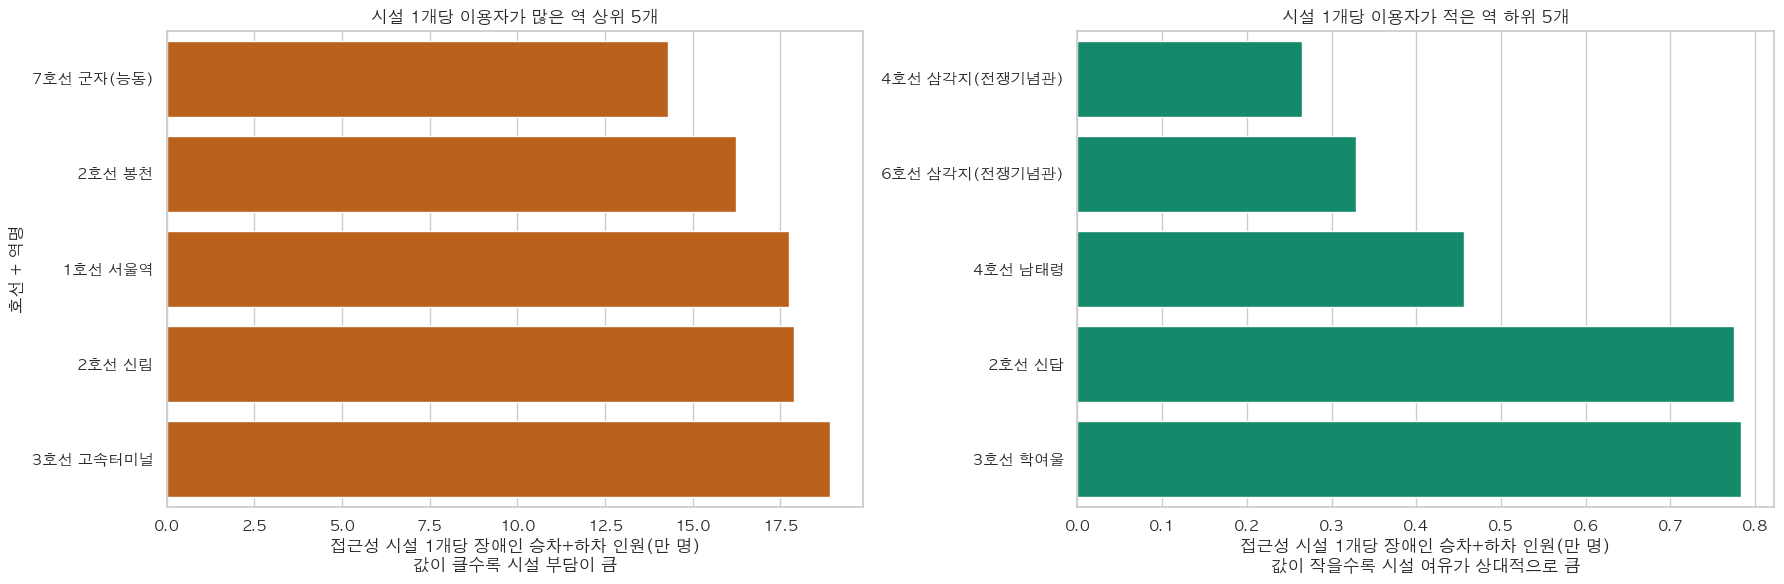

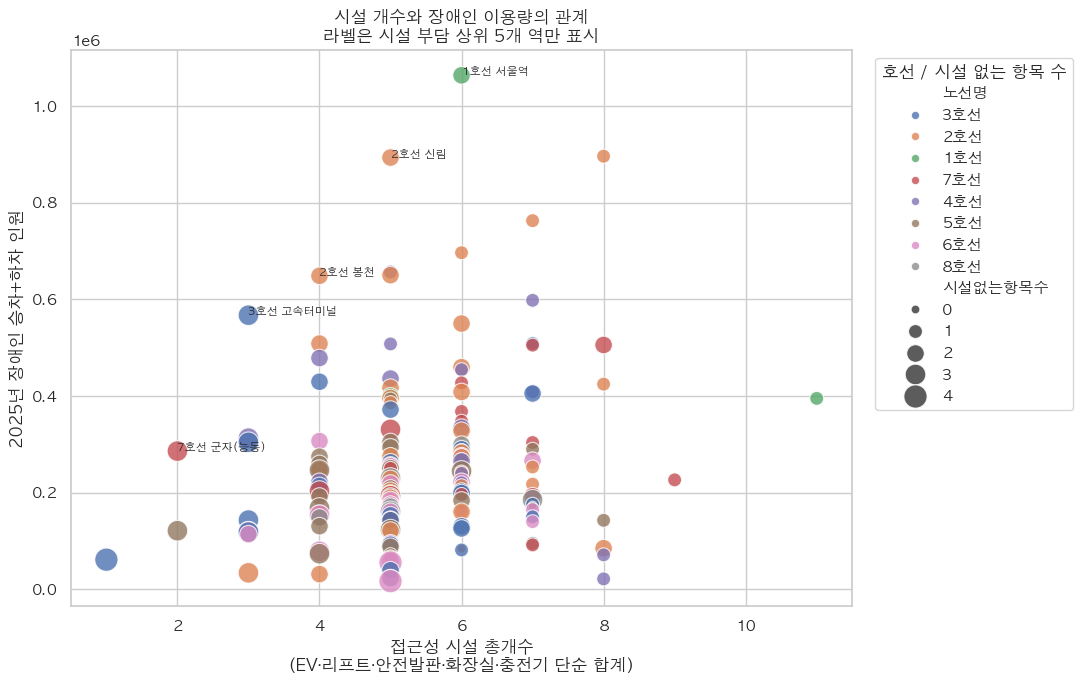

,구분,부담비교순위,노선명,역명,지역표시명,장애인총승하차인원수,접근성시설합계,시설없는항목수,접근성시설_1개당이용량,운행엘리베이터수,운행EV_1개당이용량,안전발판수,안전발판_1개당이용량
0,시설 1개당 이용량 상위 5개,1,3호선,고속터미널,서초구,567469,3,3,189156.333333,2,283734.500000,1,567469.0
1,시설 1개당 이용량 상위 5개,2,2호선,신림,관악구,894073,5,2,178814.600000,3,298024.333333,1,894073.0
2,시설 1개당 이용량 상위 5개,3,1호선,서울역,중구,1064429,6,2,177404.833333,4,266107.250000,1,1064429.0
3,시설 1개당 이용량 상위 5개,4,2호선,봉천,관악구,649116,4,2,162279.000000,2,324558.000000,1,649116.0
4,시설 1개당 이용량 상위 5개,5,7호선,군자(능동),광진구,285948,2,3,142974.000000,1,285948.000000,0,NaN
5,시설 1개당 이용량 하위 5개,151,4호선,삼각지(전쟁기념관),용산구,21176,8,1,2647.000000,5,4235.200000,1,21176.0
6,시설 1개당 이용량 하위 5개,150,6호선,삼각지(전쟁기념관),용산구,16455,5,4,3291.000000,5,3291.000000,0,NaN
7,시설 1개당 이용량 하위 5개,149,4호선,남태령,서초구,22795,5,2,4559.000000,3,7598.333333,1,22795.0
8,시설 1개당 이용량 하위 5개,148,2호선,신답,성동구,31022,4,2,7755.500000,2,15511.000000,1,31022.0
9,시설 1개당 이용량 하위 5개,147,3호선,학여울,강남구,39155,5,2,7831.000000,3,13051.666667,1,39155.0


In [19]:
station_facility_burden = high_demand_stations.copy()

station_facility_burden['운행EV_1개당이용량'] = np.where(
    station_facility_burden['운행엘리베이터수'].gt(0),
    station_facility_burden['장애인총승하차인원수'] / station_facility_burden['운행엘리베이터수'],
    np.nan,
)
station_facility_burden['안전발판_1개당이용량'] = np.where(
    station_facility_burden['안전발판수'].gt(0),
    station_facility_burden['장애인총승하차인원수'] / station_facility_burden['안전발판수'],
    np.nan,
)
station_facility_burden['접근성시설_1개당이용량'] = np.where(
    station_facility_burden['접근성시설합계'].gt(0),
    station_facility_burden['장애인총승하차인원수'] / station_facility_burden['접근성시설합계'],
    np.nan,
)
station_facility_burden['시설합계_0여부'] = station_facility_burden['접근성시설합계'].eq(0)
station_facility_burden['부담비교순위'] = station_facility_burden['접근성시설_1개당이용량'].rank(
    ascending=False, method='min', na_option='bottom'
).astype('int64')
station_facility_burden = station_facility_burden.sort_values(
    ['시설합계_0여부', '접근성시설_1개당이용량', '장애인총승하차인원수'],
    ascending=[False, False, False],
).reset_index(drop=True)
station_facility_burden['역표시명'] = station_facility_burden['노선명'] + ' ' + station_facility_burden['역명']
station_facility_burden['접근성시설_1개당이용량_만명'] = station_facility_burden['접근성시설_1개당이용량'] / 10000
station_facility_burden['운행EV_1개당이용량_만명'] = station_facility_burden['운행EV_1개당이용량'] / 10000

burden_valid = station_facility_burden.loc[station_facility_burden['접근성시설_1개당이용량'].notna()].copy()
burden_top5 = burden_valid.nlargest(5, '접근성시설_1개당이용량').copy()
burden_bottom5 = burden_valid.nsmallest(5, '접근성시설_1개당이용량').copy()
burden_top_bottom = pd.concat([
    burden_top5.assign(구분='시설 1개당 이용량 상위 5개'),
    burden_bottom5.assign(구분='시설 1개당 이용량 하위 5개'),
], ignore_index=True)

burden_top_plot = burden_top_bottom[burden_top_bottom['구분'].eq('시설 1개당 이용량 상위 5개')].sort_values('접근성시설_1개당이용량_만명', ascending=True)
burden_bottom_plot = burden_top_bottom[burden_top_bottom['구분'].eq('시설 1개당 이용량 하위 5개')].sort_values('접근성시설_1개당이용량_만명', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)
sns.barplot(data=burden_top_plot, y='역표시명', x='접근성시설_1개당이용량_만명', color='#D55E00', ax=axes[0])
axes[0].set_title('시설 1개당 이용자가 많은 역 상위 5개')
axes[0].set_xlabel('접근성 시설 1개당 장애인 승차+하차 인원(만 명)\n값이 클수록 시설 부담이 큼')
axes[0].set_ylabel('호선 + 역명')

sns.barplot(data=burden_bottom_plot, y='역표시명', x='접근성시설_1개당이용량_만명', color='#009E73', ax=axes[1])
axes[1].set_title('시설 1개당 이용자가 적은 역 하위 5개')
axes[1].set_xlabel('접근성 시설 1개당 장애인 승차+하차 인원(만 명)\n값이 작을수록 시설 여유가 상대적으로 큼')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))
ax = sns.scatterplot(
    data=station_facility_burden,
    x='접근성시설합계',
    y='장애인총승하차인원수',
    hue='노선명',
    size='시설없는항목수',
    sizes=(40, 280),
    alpha=0.8,
)
for _, row in burden_top5.iterrows():
    ax.text(row['접근성시설합계'], row['장애인총승하차인원수'], row['역표시명'], fontsize=8)
ax.set_title('시설 개수와 장애인 이용량의 관계\n라벨은 시설 부담 상위 5개 역만 표시')
ax.set_xlabel('접근성 시설 총개수\n(EV·리프트·안전발판·화장실·충전기 단순 합계)')
ax.set_ylabel('2025년 장애인 승차+하차 인원')
ax.legend(title='호선 / 시설 없는 항목 수', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

burden_display_columns = [
    '구분', '부담비교순위', '노선명', '역명', '지역표시명', '장애인총승하차인원수',
    '접근성시설합계', '시설없는항목수', '접근성시설_1개당이용량',
    '운행엘리베이터수', '운행EV_1개당이용량', '안전발판수', '안전발판_1개당이용량',
]
display(burden_top_bottom[burden_display_columns])


In [20]:
burden_valid = station_facility_burden.loc[station_facility_burden['접근성시설_1개당이용량'].notna()].copy()
highest_burden_station = burden_valid.sort_values('접근성시설_1개당이용량', ascending=False).iloc[0]
lowest_burden_station = burden_valid.sort_values('접근성시설_1개당이용량', ascending=True).iloc[0]
zero_facility_count = int(station_facility_burden['시설합계_0여부'].sum())

show_result(
    '2-2-3 결과: 이용량 대비 시설 부담이 큰 역-노선 조합',
    [
        f'접근성 시설 1개당 장애인 이용량이 가장 큰 조합은 {highest_burden_station["역명"]}({highest_burden_station["노선명"]}, {highest_burden_station["지역표시명"]})이다.',
        f'해당 조합은 접근성 시설 합계 {highest_burden_station["접근성시설합계"]:.0f}개 기준 시설 1개당 {highest_burden_station["접근성시설_1개당이용량"]:,.0f}명의 이용량이 계산된다.',
        f'반대로 시설 1개당 이용량이 가장 낮은 조합은 {lowest_burden_station["역명"]}({lowest_burden_station["노선명"]})이다.',
        f'접근성 시설 합계가 0으로 계산되어 비율 계산에서 별도 확인이 필요한 조합은 {zero_facility_count:,}개이다.',
        '표와 그래프는 전체를 나열하지 않고 상위 5개·하위 5개만 표시했다.',
    ],
    [
        '부담이 큰 조합이 어느 구에 몰려 있는지 확인한다.',
        '시설 유형별 부족 조건과 함께 다시 비교한다.',
    ],
    conclusion='시설 1개당 장애인 승하차인원을 계산하면, 이용량에 비해 접근성 시설 수가 상대적으로 적어 보이는 역-노선 조합을 찾을 수 있다. 같은 역명이라도 호선이 다르면 시설 부담이 달라질 수 있으므로 호선별로 나누어 보는 것이 더 적절하다.',
    significance='시설 1개당 이용량은 가중치 없이 부담 정도를 직관적으로 비교할 수 있어 현장 점검 후보를 찾는 데 유의미하다. 다만 서로 다른 시설을 단순 합산하므로 최종 우선순위로 쓰기보다는 보조 지표로 보는 것이 안전하다.'
)


#### 2-2-3 결과: 이용량 대비 시설 부담이 큰 역-노선 조합

**결과 해석**

- 접근성 시설 1개당 장애인 이용량이 가장 큰 조합은 고속터미널(3호선, 서초구)이다.
- 해당 조합은 접근성 시설 합계 3개 기준 시설 1개당 189,156명의 이용량이 계산된다.
- 반대로 시설 1개당 이용량이 가장 낮은 조합은 삼각지(전쟁기념관)(4호선)이다.
- 접근성 시설 합계가 0으로 계산되어 비율 계산에서 별도 확인이 필요한 조합은 0개이다.
- 표와 그래프는 전체를 나열하지 않고 상위 5개·하위 5개만 표시했다.

**결론**

- 시설 1개당 장애인 승하차인원을 계산하면, 이용량에 비해 접근성 시설 수가 상대적으로 적어 보이는 역-노선 조합을 찾을 수 있다. 같은 역명이라도 호선이 다르면 시설 부담이 달라질 수 있으므로 호선별로 나누어 보는 것이 더 적절하다.

**유의미성**

- 시설 1개당 이용량은 가중치 없이 부담 정도를 직관적으로 비교할 수 있어 현장 점검 후보를 찾는 데 유의미하다. 다만 서로 다른 시설을 단순 합산하므로 최종 우선순위로 쓰기보다는 보조 지표로 보는 것이 안전하다.

**이 결과를 바탕으로 이어볼 분석**

- 부담이 큰 조합이 어느 구에 몰려 있는지 확인한다.
- 시설 유형별 부족 조건과 함께 다시 비교한다.

#### 2-2-4. 시설 부담이 큰 역의 구별 분포 확인

2-2-3에서 역별 이용량 대비 시설 수를 단순 비율로 계산했으므로, 여기서는 부담이 큰 역들이 어느 구에 있는지 확인한다.

이 분석에서도 임의 가중치는 사용하지 않는다.  
구별로 다음 값을 단순 집계한다.

- 구별 분석 대상 역 수
- 구별 총 장애인 승하차인원
- 구별 평균 접근성 시설 1개당 이용량
- 구별 시설 부담 후보 역 수

`시설 부담 후보 역`은 전체 역 중 `접근성시설_1개당이용량`이 상위 25%에 해당하는 역으로만 표시한다. 이는 가중치 점수가 아니라, 전체 분포에서 상대적으로 시설 1개당 이용량이 큰 역을 표시하기 위한 분위수 기준이다.


,지역표시명,분석대상역노선조합수,시설부담후보역수,총장애인승하차인원,평균_접근성시설_1개당이용량,평균접근성시설합계,시설부담후보역비율,구분
0,중구,13,6,4363819,72354.656227,4.615385,0.461538,시설부담후보역수 상위 5개 구
1,서초구,13,4,3528251,52792.082173,5.923077,0.307692,시설부담후보역수 상위 5개 구
2,노원구,8,4,2986937,61445.879762,6.250000,0.500000,시설부담후보역수 상위 5개 구
3,관악구,4,4,2610963,138662.100000,4.750000,1.000000,시설부담후보역수 상위 5개 구
4,종로구,3,3,1296297,88541.450794,5.000000,1.000000,시설부담후보역수 상위 5개 구
5,용산구,9,0,940307,20020.580556,5.666667,0.000000,시설부담후보역수 하위 5개 구
6,동대문구,3,0,601088,23587.201515,8.000000,0.000000,시설부담후보역수 하위 5개 구
7,중랑구,2,0,552778,49142.783333,5.500000,0.000000,시설부담후보역수 하위 5개 구
8,강서구,2,0,428383,35698.583333,6.000000,0.000000,시설부담후보역수 하위 5개 구
9,강동구,1,0,246482,61620.500000,4.000000,0.000000,시설부담후보역수 하위 5개 구


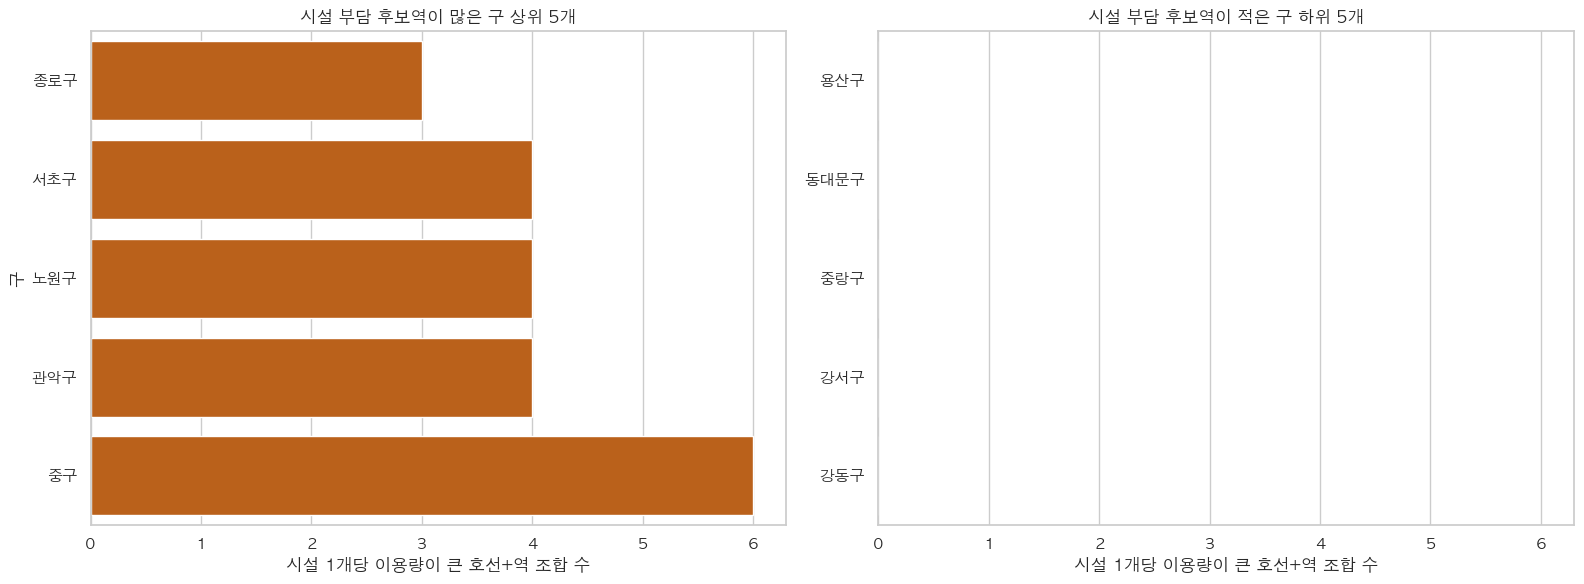

In [21]:
burden_threshold = station_facility_burden['접근성시설_1개당이용량'].quantile(0.75)
station_facility_burden['시설부담후보여부'] = station_facility_burden['접근성시설_1개당이용량'].ge(burden_threshold)

burden_by_district = (
    station_facility_burden.groupby('지역표시명', as_index=False)
    .agg(
        분석대상역노선조합수=('역표시명', 'count'),
        시설부담후보역수=('시설부담후보여부', 'sum'),
        총장애인승하차인원=('장애인총승하차인원수', 'sum'),
        평균_접근성시설_1개당이용량=('접근성시설_1개당이용량', 'mean'),
        평균접근성시설합계=('접근성시설합계', 'mean'),
    )
    .sort_values(['시설부담후보역수', '총장애인승하차인원'], ascending=[False, False])
)
burden_by_district['시설부담후보역비율'] = burden_by_district['시설부담후보역수'] / burden_by_district['분석대상역노선조합수'].replace(0, np.nan)

burden_district_top_bottom = pd.concat([
    burden_by_district.head(5).assign(구분='시설부담후보역수 상위 5개 구'),
    burden_by_district.tail(5).sort_values('시설부담후보역수').assign(구분='시설부담후보역수 하위 5개 구'),
], ignore_index=True)

display(burden_district_top_bottom)

burden_district_top_plot = burden_district_top_bottom[burden_district_top_bottom['구분'].eq('시설부담후보역수 상위 5개 구')].sort_values('시설부담후보역수', ascending=True)
burden_district_bottom_plot = burden_district_top_bottom[burden_district_top_bottom['구분'].eq('시설부담후보역수 하위 5개 구')].sort_values('시설부담후보역수', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
sns.barplot(data=burden_district_top_plot, y='지역표시명', x='시설부담후보역수', color='#D55E00', ax=axes[0])
axes[0].set_title('시설 부담 후보역이 많은 구 상위 5개')
axes[0].set_xlabel('시설 1개당 이용량이 큰 호선+역 조합 수')
axes[0].set_ylabel('구')

sns.barplot(data=burden_district_bottom_plot, y='지역표시명', x='시설부담후보역수', color='#009E73', ax=axes[1])
axes[1].set_title('시설 부담 후보역이 적은 구 하위 5개')
axes[1].set_xlabel('시설 1개당 이용량이 큰 호선+역 조합 수')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


In [22]:
top_burden_district = burden_by_district.iloc[0]
show_result(
    '2-2-4 결과: 시설 부담이 큰 역의 구별 분포',
    [
        f'시설 부담 후보 역 수가 가장 많은 구는 {top_burden_district["지역표시명"]}이며, 후보 역 {top_burden_district["시설부담후보역수"]:.0f}개가 포함된다.',
        f'이 구의 평균 접근성 시설 1개당 장애인 승하차인원은 {top_burden_district["평균_접근성시설_1개당이용량"]:,.0f}명이다.',
        '후보 역은 임의 점수가 아니라 접근성 시설 1개당 이용량의 상위 25% 분위수 기준으로 표시했다.',
    ],
    [
        '2-3에서 구별 총 지하철 이용량과 역당 이용량을 비교한다.',
        '이후 4장에서 콜택시 수요가 높은 구와도 함께 비교한다.',
    ],
    conclusion='시설 부담 후보 역의 구별 분포를 보면 역 단위에서 발견한 문제가 특정 지역에 몰려 있는지 확인할 수 있다. 후보 역이 많은 구는 개별 역 하나의 문제가 아니라 지역 단위 접근성 개선 과제로 이어질 가능성이 있다. 다만 후보 여부는 시설 1개당 이용량의 상대적 분포를 기준으로 표시한 것이므로, 실제 개선 판단에는 역 구조, 환승 여부, 출입구 위치, 엘리베이터 운행 상태 같은 세부 정보가 추가로 필요하다.',
    significance='역 단위 부담이 특정 구에 몰리는지 확인할 수 있어 지역 단위 개선 후보를 찾는 데 유의미하다. 다만 상위 25% 분위수 기준은 탐색적 구분이므로 정책적 기준이나 통계적 유의성으로 해석하면 안 된다.'
)


#### 2-2-4 결과: 시설 부담이 큰 역의 구별 분포

**결과 해석**

- 시설 부담 후보 역 수가 가장 많은 구는 중구이며, 후보 역 6개가 포함된다.
- 이 구의 평균 접근성 시설 1개당 장애인 승하차인원은 72,355명이다.
- 후보 역은 임의 점수가 아니라 접근성 시설 1개당 이용량의 상위 25% 분위수 기준으로 표시했다.

**결론**

- 시설 부담 후보 역의 구별 분포를 보면 역 단위에서 발견한 문제가 특정 지역에 몰려 있는지 확인할 수 있다. 후보 역이 많은 구는 개별 역 하나의 문제가 아니라 지역 단위 접근성 개선 과제로 이어질 가능성이 있다. 다만 후보 여부는 시설 1개당 이용량의 상대적 분포를 기준으로 표시한 것이므로, 실제 개선 판단에는 역 구조, 환승 여부, 출입구 위치, 엘리베이터 운행 상태 같은 세부 정보가 추가로 필요하다.

**유의미성**

- 역 단위 부담이 특정 구에 몰리는지 확인할 수 있어 지역 단위 개선 후보를 찾는 데 유의미하다. 다만 상위 25% 분위수 기준은 탐색적 구분이므로 정책적 기준이나 통계적 유의성으로 해석하면 안 된다.

**이 결과를 바탕으로 이어볼 분석**

- 2-3에서 구별 총 지하철 이용량과 역당 이용량을 비교한다.
- 이후 4장에서 콜택시 수요가 높은 구와도 함께 비교한다.

### 2-3. 지역 단위 장애인 지하철 이용량 분석

#### 2-3-1. 구별 장애인 지하철 이용량 비교

두 그래프는 비슷해 보이지만 의미가 다르다.

- `전체 구별 장애인 지하철 총 승하차인원`
  - 구 안에 있는 모든 분석 대상 역의 장애인 승하차인원을 합친 값이다.
  - 역이 많은 구는 총량이 크게 나올 수 있다.
  - “그 구 전체에서 장애인 지하철 수요가 얼마나 큰가?”를 보는 지표다.
- `전체 구별 역당 장애인 승하차인원`
  - 구별 총 승하차인원을 구 안의 역 수로 나눈 값이다.
  - 역 수 차이를 어느 정도 보정해서, 한 역당 수요 밀도를 본다.
  - “역 하나하나가 평균적으로 얼마나 많이 이용되는가?”를 보는 지표다.

예를 들어 A구는 역이 많아 총량이 높고, B구는 역은 적지만 특정 역에 수요가 몰려 역당 이용량이 높을 수 있다.

,지역명,지하철_장애인총승하차인원수,지하철_역수,지하철_월평균승하차인원수,운행엘리베이터수,안전발판수,역당_장애인승하차인원수,구분
0,중구,4363819,13,27973.198718,35,12,335678.384615,총 승하차 상위 5개 구
1,송파구,4330367,21,17183.996032,72,10,206207.952381,총 승하차 상위 5개 구
2,서초구,3528251,13,22616.993590,44,11,271403.923077,총 승하차 상위 5개 구
3,강남구,3387404,14,20163.119048,44,11,241957.428571,총 승하차 상위 5개 구
4,노원구,2986937,8,31113.927083,25,7,373367.125000,총 승하차 상위 5개 구
5,강동구,246482,1,20540.166667,3,0,246482.000000,총 승하차 하위 5개 구
6,동작구,330897,1,27574.750000,4,0,330897.000000,총 승하차 하위 5개 구
7,강서구,428383,2,17849.291667,9,1,214191.500000,총 승하차 하위 5개 구
8,금천구,505802,1,42150.166667,4,1,505802.000000,총 승하차 하위 5개 구
9,중랑구,552778,2,23032.416667,6,1,276389.000000,총 승하차 하위 5개 구


,지역명,지하철_장애인총승하차인원수,지하철_역수,지하철_월평균승하차인원수,운행엘리베이터수,안전발판수,역당_장애인승하차인원수,구분
0,관악구,2610963,4,54395.062500,11,4,652740.750000,역당 승하차 상위 5개 구
1,강북구,1093168,2,45548.666667,5,2,546584.000000,역당 승하차 상위 5개 구
2,금천구,505802,1,42150.166667,4,1,505802.000000,역당 승하차 상위 5개 구
3,종로구,1296297,3,36008.250000,8,3,432099.000000,역당 승하차 상위 5개 구
4,구로구,1126773,3,31299.250000,9,2,375591.000000,역당 승하차 상위 5개 구
5,용산구,940307,9,10141.000000,35,5,104478.555556,역당 승하차 하위 5개 구
6,성동구,1150266,8,11981.937500,22,7,143783.250000,역당 승하차 하위 5개 구
7,성북구,1187030,6,16486.527778,18,3,197838.333333,역당 승하차 하위 5개 구
8,동대문구,601088,3,16696.888889,11,3,200362.666667,역당 승하차 하위 5개 구
9,송파구,4330367,21,17183.996032,72,10,206207.952381,역당 승하차 하위 5개 구


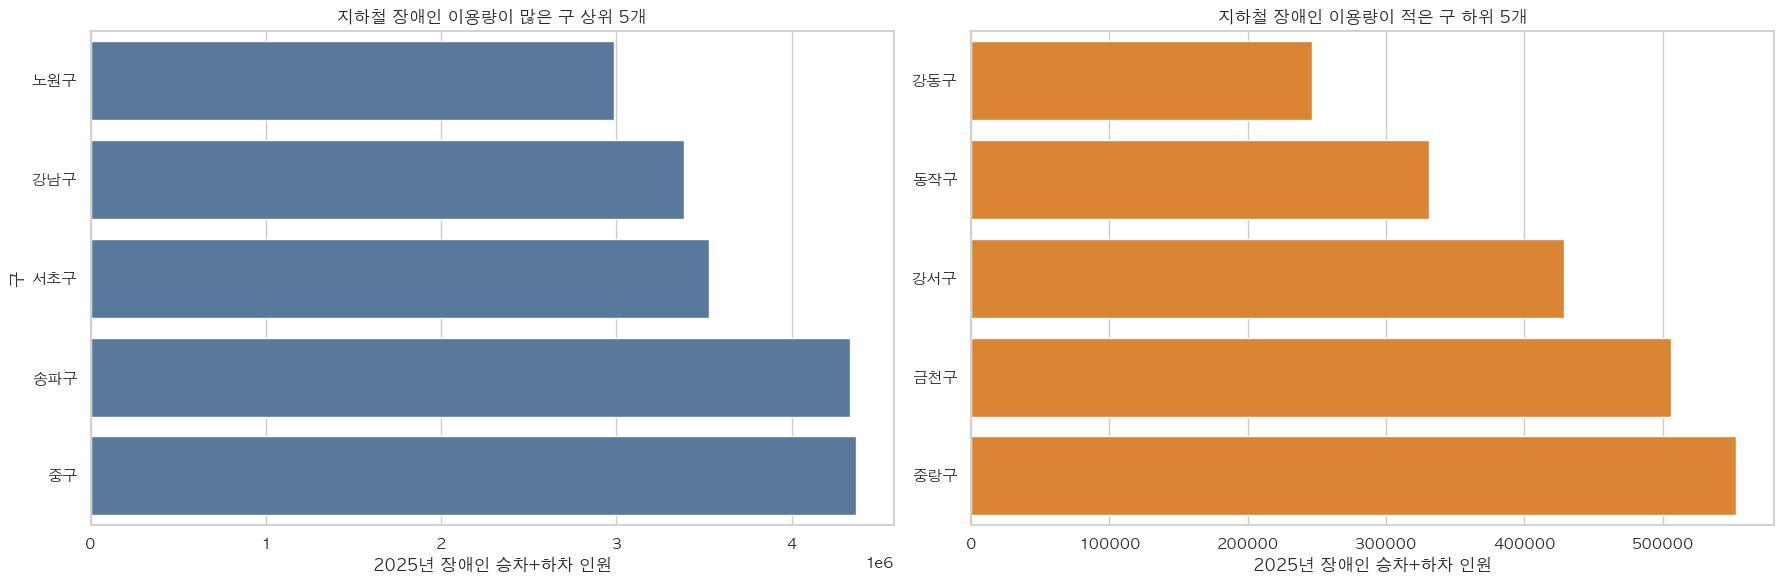

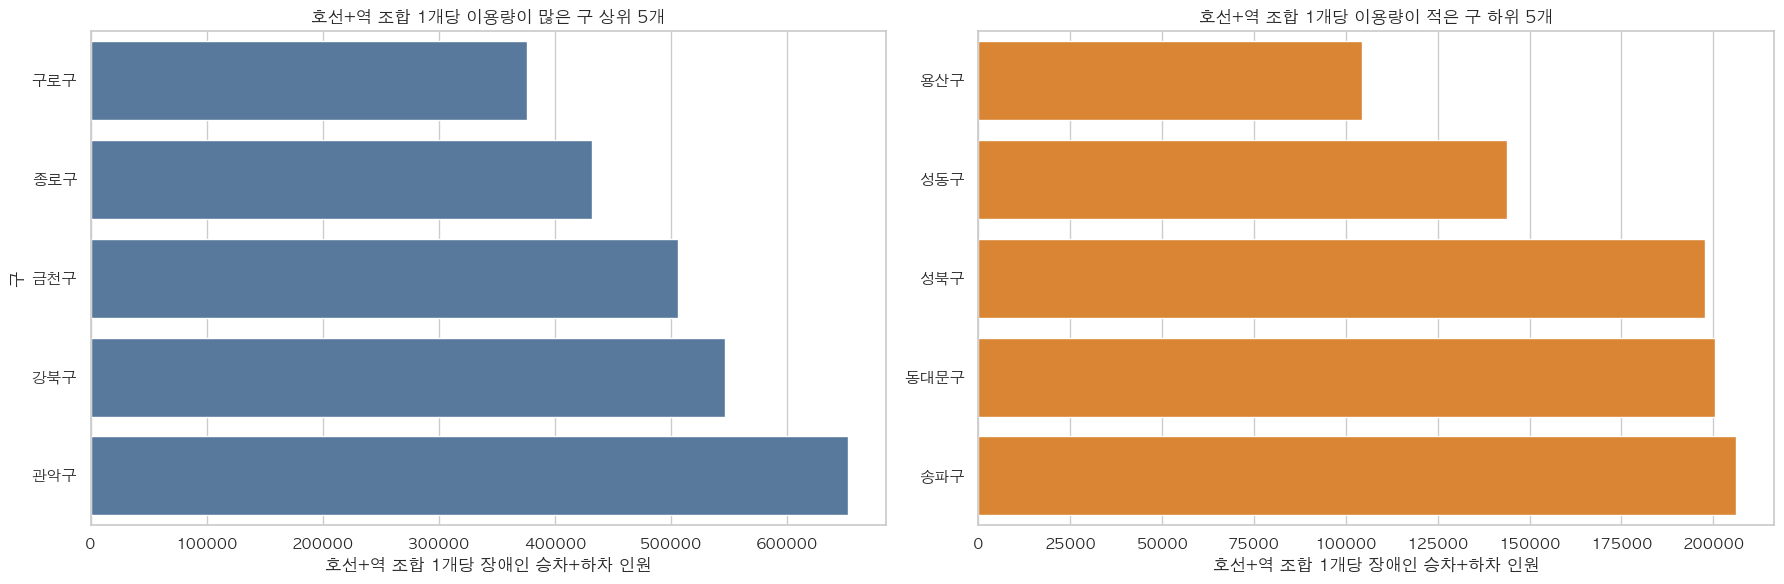

In [23]:
subway_district = station_demand.groupby('지역명', as_index=False).agg(
    지하철_장애인총승하차인원수=('장애인총승하차인원수', 'sum'),
    지하철_역수=('역표시명', 'count'),
    지하철_월평균승하차인원수=('장애인월평균승하차인원수', 'mean'),
    운행엘리베이터수=('운행엘리베이터수', 'sum'),
    안전발판수=('안전발판수', 'sum'),
)
subway_district['역당_장애인승하차인원수'] = subway_district['지하철_장애인총승하차인원수'] / subway_district['지하철_역수'].replace(0, np.nan)
subway_district = subway_district.sort_values('지하철_장애인총승하차인원수', ascending=False).reset_index(drop=True)

subway_district_total_top_bottom = pd.concat([
    subway_district.nlargest(5, '지하철_장애인총승하차인원수').assign(구분='총 승하차 상위 5개 구'),
    subway_district.nsmallest(5, '지하철_장애인총승하차인원수').assign(구분='총 승하차 하위 5개 구'),
], ignore_index=True)
subway_district_per_station_top_bottom = pd.concat([
    subway_district.nlargest(5, '역당_장애인승하차인원수').assign(구분='역당 승하차 상위 5개 구'),
    subway_district.nsmallest(5, '역당_장애인승하차인원수').assign(구분='역당 승하차 하위 5개 구'),
], ignore_index=True)

display(subway_district_total_top_bottom)
display(subway_district_per_station_top_bottom)

total_top_plot = subway_district_total_top_bottom[subway_district_total_top_bottom['구분'].eq('총 승하차 상위 5개 구')].sort_values('지하철_장애인총승하차인원수', ascending=True)
total_bottom_plot = subway_district_total_top_bottom[subway_district_total_top_bottom['구분'].eq('총 승하차 하위 5개 구')].sort_values('지하철_장애인총승하차인원수', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)
sns.barplot(data=total_top_plot, y='지역명', x='지하철_장애인총승하차인원수', color='#4C78A8', ax=axes[0])
axes[0].set_title('지하철 장애인 이용량이 많은 구 상위 5개')
axes[0].set_xlabel('2025년 장애인 승차+하차 인원')
axes[0].set_ylabel('구')

sns.barplot(data=total_bottom_plot, y='지역명', x='지하철_장애인총승하차인원수', color='#F58518', ax=axes[1])
axes[1].set_title('지하철 장애인 이용량이 적은 구 하위 5개')
axes[1].set_xlabel('2025년 장애인 승차+하차 인원')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

per_top_plot = subway_district_per_station_top_bottom[subway_district_per_station_top_bottom['구분'].eq('역당 승하차 상위 5개 구')].sort_values('역당_장애인승하차인원수', ascending=True)
per_bottom_plot = subway_district_per_station_top_bottom[subway_district_per_station_top_bottom['구분'].eq('역당 승하차 하위 5개 구')].sort_values('역당_장애인승하차인원수', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)
sns.barplot(data=per_top_plot, y='지역명', x='역당_장애인승하차인원수', color='#4C78A8', ax=axes[0])
axes[0].set_title('호선+역 조합 1개당 이용량이 많은 구 상위 5개')
axes[0].set_xlabel('호선+역 조합 1개당 장애인 승차+하차 인원')
axes[0].set_ylabel('구')

sns.barplot(data=per_bottom_plot, y='지역명', x='역당_장애인승하차인원수', color='#F58518', ax=axes[1])
axes[1].set_title('호선+역 조합 1개당 이용량이 적은 구 하위 5개')
axes[1].set_xlabel('호선+역 조합 1개당 장애인 승차+하차 인원')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


In [24]:
top_subway_district = subway_district.sort_values('지하철_장애인총승하차인원수', ascending=False).iloc[0]
show_result(
    '2-3-1 결과: 구별 장애인 지하철 이용량',
    [
        f'지하철 장애인 총 승하차인원이 가장 큰 구는 {top_subway_district["지역명"]}이며, 총 {top_subway_district["지하철_장애인총승하차인원수"]:,.0f}명이다.',
        '구별 총 이용량은 해당 구에 역이 많을수록 커질 수 있고, 역당 이용량은 역 하나가 감당하는 평균 수요를 보기 위한 지표이다.',
    ],
    [
        '구별 지하철 수요가 콜택시 출발·도착 수요와 같은 방향인지 비교한다.',
        '역 수가 적지만 역당 이용량이 높은 구를 따로 확인한다.',
    ],
    conclusion='구별 총 승하차인원은 해당 구 전체의 장애인 지하철 수요 규모를 보여주고, 역당 승하차인원은 역 하나가 평균적으로 감당하는 이용 부담을 보여준다. 두 지표를 함께 봐야 역이 많아서 총량이 큰 지역과 역 수는 적지만 개별 역의 부담이 큰 지역을 구분할 수 있다. 이 구별 지표는 이후 콜택시 수요와 비교할 때, 지하철 이용이 활발한 지역과 콜택시 의존이 큰 지역을 나누는 기준으로 활용된다.',
    significance='구별 총량과 역당 이용량을 분리해 지역별 지하철 수요를 비교하는 데 유의미하다. 이후 콜택시 수요와 결합하면 지하철 수요가 큰 지역과 콜택시 의존 가능성이 큰 지역을 구분하는 근거가 된다.'
)


#### 2-3-1 결과: 구별 장애인 지하철 이용량

**결과 해석**

- 지하철 장애인 총 승하차인원이 가장 큰 구는 중구이며, 총 4,363,819명이다.
- 구별 총 이용량은 해당 구에 역이 많을수록 커질 수 있고, 역당 이용량은 역 하나가 감당하는 평균 수요를 보기 위한 지표이다.

**결론**

- 구별 총 승하차인원은 해당 구 전체의 장애인 지하철 수요 규모를 보여주고, 역당 승하차인원은 역 하나가 평균적으로 감당하는 이용 부담을 보여준다. 두 지표를 함께 봐야 역이 많아서 총량이 큰 지역과 역 수는 적지만 개별 역의 부담이 큰 지역을 구분할 수 있다. 이 구별 지표는 이후 콜택시 수요와 비교할 때, 지하철 이용이 활발한 지역과 콜택시 의존이 큰 지역을 나누는 기준으로 활용된다.

**유의미성**

- 구별 총량과 역당 이용량을 분리해 지역별 지하철 수요를 비교하는 데 유의미하다. 이후 콜택시 수요와 결합하면 지하철 수요가 큰 지역과 콜택시 의존 가능성이 큰 지역을 구분하는 근거가 된다.

**이 결과를 바탕으로 이어볼 분석**

- 구별 지하철 수요가 콜택시 출발·도착 수요와 같은 방향인지 비교한다.
- 역 수가 적지만 역당 이용량이 높은 구를 따로 확인한다.

### 2-4. 시간대별 지하철 혼잡도 분석

이번 절에서는 새로 가져온 `서울교통공사 지하철혼잡도정보`를 사용해 실제 혼잡도 값을 분석한다. 이전의 일반 승하차인원 기반 대체 분석과 달리, 이 데이터는 `요일구분`, `호선`, `출발역`, `상하구분`, `시간대별 혼잡도`를 포함한다.

분석 기준은 다음과 같다.

- 혼잡도 값이 높을수록 해당 시간대·방향의 열차 이용 부담이 크다.
- 같은 역이라도 상선/하선과 시간대에 따라 혼잡도가 다를 수 있다.
- 네비게이터에서는 엘리베이터 보유 여부와 함께 혼잡 시간대를 피해야 하는지 판단하는 보조 기준으로 활용할 수 있다.


,기준일자,요일구분,노선명,출발역,상하구분,시간대,혼잡도,지역명,장애인총승하차인원수,운행엘리베이터수,안전발판수
87521,20250930,토요일,5호선,마포,하선,21시30분,164.3,마포구,191808,2,1
90203,20250930,토요일,5호선,마포,하선,22시00분,161.9,마포구,191808,2,1
68748,20250930,토요일,5호선,공덕,상선,18시00분,149.1,마포구,165443,2,1
71430,20250930,토요일,5호선,공덕,상선,18시30분,148.6,마포구,165443,2,1
18135,20251130,평일,2호선,방배,외선,8시30분,147.3,서초구,198199,3,1


,구분,노선명,출발역,지역명,최대혼잡도,평균혼잡도,장애인총승하차인원수,운행엘리베이터수,안전발판수
0,최대 혼잡도 상위 5개,5호선,마포,마포구,164.3,33.115665,191808,2,1
1,최대 혼잡도 상위 5개,5호선,공덕,마포구,149.1,32.295708,165443,2,1
2,최대 혼잡도 상위 5개,2호선,방배,서초구,147.3,45.365880,198199,3,1
3,최대 혼잡도 상위 5개,2호선,서초,서초구,145.7,45.409657,253033,4,1
4,최대 혼잡도 상위 5개,7호선,가산디지털단지,금천구,141.3,33.112983,505802,4,1
5,최대 혼잡도 하위 5개,5호선,마천,송파구,20.1,2.363519,208530,3,0
6,최대 혼잡도 하위 5개,3호선,오금,송파구,27.4,2.759335,92006,3,1
7,최대 혼잡도 하위 5개,3호선,경찰병원,송파구,32.7,6.289163,130277,4,1
8,최대 혼잡도 하위 5개,7호선,수락산,노원구,33.8,11.193991,347840,3,1
9,최대 혼잡도 하위 5개,5호선,송정,강서구,38.2,12.131009,183661,4,1


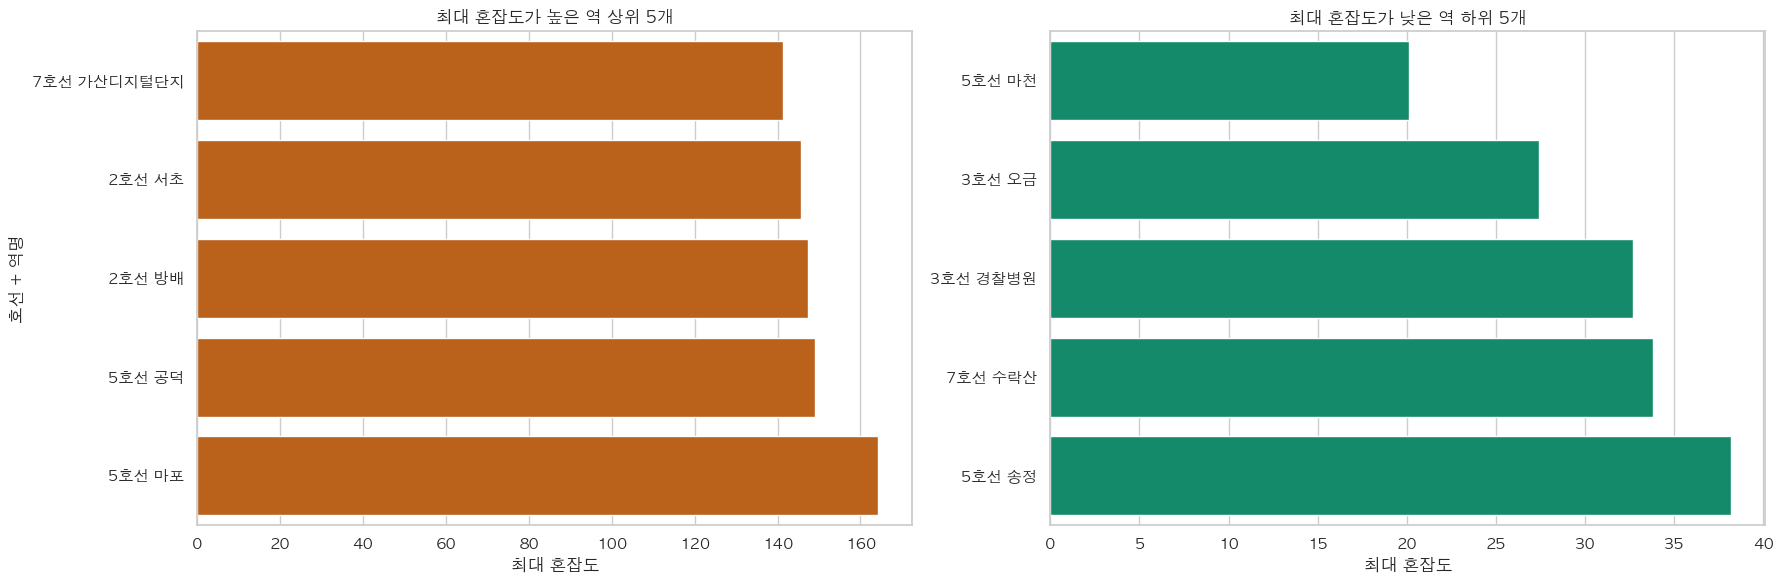

시간대,노선명,최대평균혼잡도,가장혼잡한시간대,일평균혼잡도
0,1호선,76.183333,18시00분,31.216453
1,2호선,68.584914,8시00분,36.617407
2,3호선,53.415000,18시00분,29.044840
3,4호선,57.435714,18시00분,32.345934
4,5호선,58.309375,8시00분,29.280673
5,6호선,56.997500,18시00분,27.603622
6,7호선,66.807500,18시00분,36.915876
7,8호선,94.904167,8시00분,46.820299


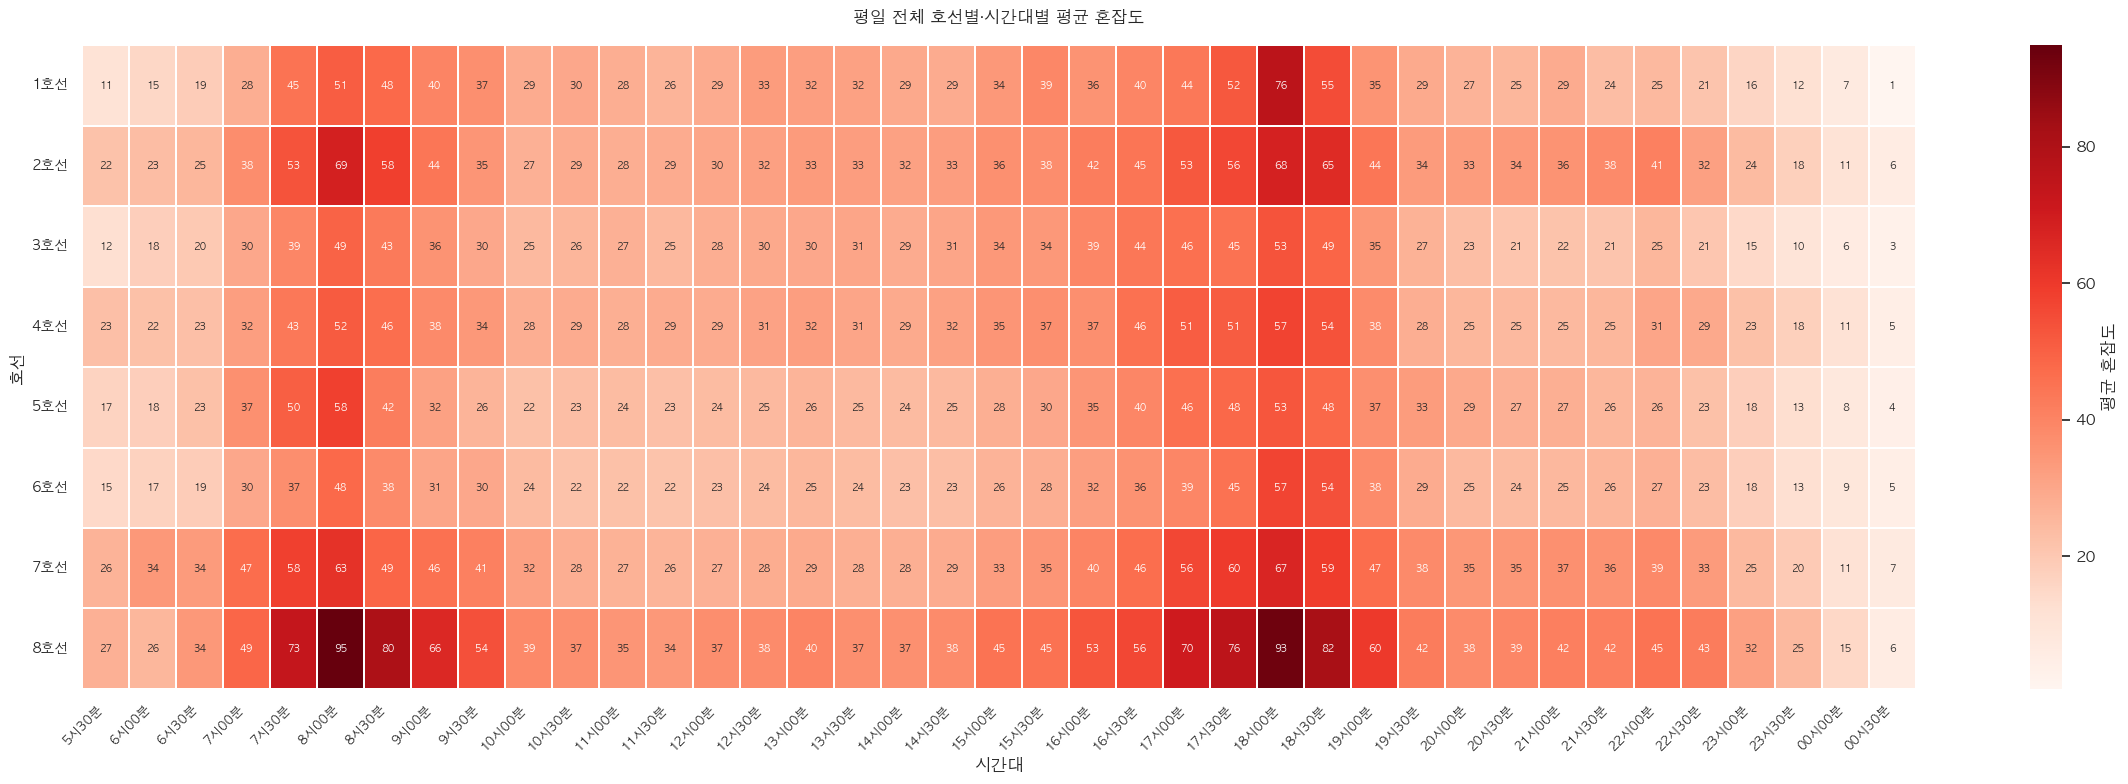

,노선명,출발역,지역명,최대혼잡도,평균혼잡도,장애인총승하차인원수,운행엘리베이터수,안전발판수
90,7호선,가산디지털단지,금천구,141.3,33.112983,505802,4,1
59,4호선,혜화,종로구,140.7,43.186159,598285,4,1
3,2호선,강남,서초구,135.7,42.973498,550168,4,1
14,2호선,신도림,구로구,135.3,23.665182,896846,4,1
0,1호선,서울역,중구,126.3,30.121567,1064429,4,1


In [25]:
congestion_files = sorted({
    *PROJECT_ROOT.glob('data/서울교통공사_지하철혼잡도정보_*.csv'),
    *PROJECT_ROOT.glob('data/raw/서울교통공사_지하철혼잡도정보_*.csv'),
})
assert congestion_files, '지하철 혼잡도 CSV 파일이 없습니다.'

congestion_frames = []
for file in congestion_files:
    read_success = False
    for enc in ['utf-8-sig', 'cp949']:
        try:
            temp = pd.read_csv(file, encoding=enc)
            read_success = True
            break
        except UnicodeDecodeError:
            continue
    if not read_success:
        temp = pd.read_csv(file)
    temp['기준파일'] = file.name
    temp['기준일자'] = file.stem.split('_')[-1]
    congestion_frames.append(temp)

congestion_raw = pd.concat(congestion_frames, ignore_index=True)
if '연번' in congestion_raw.columns:
    congestion_raw = congestion_raw.drop(columns=['연번'])

congestion_raw['호선'] = congestion_raw['호선'].astype(str).str.strip()
congestion_raw['노선명'] = congestion_raw['호선'].apply(lambda x: x if x.endswith('호선') else f'{x}호선')
congestion_raw['출발역'] = congestion_raw['출발역'].astype(str).str.strip()
congestion_raw['역표시명'] = congestion_raw['노선명'] + ' ' + congestion_raw['출발역']

time_columns = [col for col in congestion_raw.columns if '시' in col and '분' in col]
congestion_long = congestion_raw.melt(
    id_vars=['기준파일', '기준일자', '요일구분', '노선명', '역번호', '출발역', '상하구분', '역표시명'],
    value_vars=time_columns,
    var_name='시간대',
    value_name='혼잡도',
)
congestion_long['혼잡도'] = pd.to_numeric(congestion_long['혼잡도'], errors='coerce')
congestion_long = congestion_long.dropna(subset=['혼잡도']).copy()

station_keys = station_demand[[
    '노선명', '역명', '지역명', '행정동명', '장애인총승하차인원수',
    '운행엘리베이터수', '안전발판수', '휠체어접근가능화장실수'
]].drop_duplicates(['노선명', '역명'])

congestion_matched = congestion_long.merge(
    station_keys,
    left_on=['노선명', '출발역'],
    right_on=['노선명', '역명'],
    how='inner'
)

peak_congestion_records = congestion_matched.sort_values('혼잡도', ascending=False).head(5).copy()
display(peak_congestion_records[[
    '기준일자', '요일구분', '노선명', '출발역', '상하구분', '시간대', '혼잡도',
    '지역명', '장애인총승하차인원수', '운행엘리베이터수', '안전발판수'
]])

station_peak_congestion = (
    congestion_matched.groupby(['노선명', '출발역', '지역명'], as_index=False)
    .agg(
        최대혼잡도=('혼잡도', 'max'),
        평균혼잡도=('혼잡도', 'mean'),
        장애인총승하차인원수=('장애인총승하차인원수', 'max'),
        운행엘리베이터수=('운행엘리베이터수', 'max'),
        안전발판수=('안전발판수', 'max'),
    )
)
station_peak_congestion['역표시명'] = station_peak_congestion['노선명'] + ' ' + station_peak_congestion['출발역']

peak_station_top5 = station_peak_congestion.nlargest(5, '최대혼잡도').copy()
peak_station_bottom5 = station_peak_congestion.nsmallest(5, '최대혼잡도').copy()
peak_station_top_bottom = pd.concat([
    peak_station_top5.assign(구분='최대 혼잡도 상위 5개'),
    peak_station_bottom5.assign(구분='최대 혼잡도 하위 5개'),
], ignore_index=True)

display(peak_station_top_bottom[[
    '구분', '노선명', '출발역', '지역명', '최대혼잡도', '평균혼잡도',
    '장애인총승하차인원수', '운행엘리베이터수', '안전발판수'
]])

top_plot = peak_station_top_bottom[peak_station_top_bottom['구분'].eq('최대 혼잡도 상위 5개')].sort_values('최대혼잡도')
bottom_plot = peak_station_top_bottom[peak_station_top_bottom['구분'].eq('최대 혼잡도 하위 5개')].sort_values('최대혼잡도')
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)
sns.barplot(data=top_plot, y='역표시명', x='최대혼잡도', color='#D55E00', ax=axes[0])
axes[0].set_title('최대 혼잡도가 높은 역 상위 5개')
axes[0].set_xlabel('최대 혼잡도')
axes[0].set_ylabel('호선 + 역명')
sns.barplot(data=bottom_plot, y='역표시명', x='최대혼잡도', color='#009E73', ax=axes[1])
axes[1].set_title('최대 혼잡도가 낮은 역 하위 5개')
axes[1].set_xlabel('최대 혼잡도')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

weekday_congestion = congestion_matched.loc[congestion_matched['요일구분'].eq('평일')].copy()
line_time_congestion = (
    weekday_congestion.groupby(['노선명', '시간대'], as_index=False)
    .agg(평균혼잡도=('혼잡도', 'mean'))
)
line_order = [f'{i}호선' for i in range(1, 9)]
existing_line_order = [line for line in line_order if line in line_time_congestion['노선명'].unique()]
extra_lines = sorted(set(line_time_congestion['노선명']) - set(existing_line_order))
line_order = existing_line_order + extra_lines
line_time_pivot = line_time_congestion.pivot(index='노선명', columns='시간대', values='평균혼잡도')
line_time_pivot = line_time_pivot.reindex(index=line_order, columns=time_columns)

line_heatmap_summary = line_time_pivot.copy()
line_heatmap_summary['최대평균혼잡도'] = line_heatmap_summary.max(axis=1)
line_heatmap_summary['가장혼잡한시간대'] = line_heatmap_summary[time_columns].idxmax(axis=1)
line_heatmap_summary['일평균혼잡도'] = line_heatmap_summary[time_columns].mean(axis=1)
line_heatmap_summary = line_heatmap_summary[['최대평균혼잡도', '가장혼잡한시간대', '일평균혼잡도']].reset_index()
line_heatmap_summary_display = line_heatmap_summary.loc[line_heatmap_summary['노선명'].isin([f'{i}호선' for i in range(1, 9)])].copy()
display(line_heatmap_summary_display)

heatmap_height = max(8, len(line_time_pivot) * 0.65)
plt.figure(figsize=(24, heatmap_height))
sns.heatmap(
    line_time_pivot,
    cmap='Reds',
    annot=True,
    fmt='.0f',
    linewidths=0.25,
    annot_kws={'size': 7},
    cbar_kws={'label': '평균 혼잡도'},
)
plt.title('평일 전체 호선별·시간대별 평균 혼잡도', pad=16)
plt.xlabel('시간대')
plt.ylabel('호선')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

congestion_access_watch = station_peak_congestion.loc[
    (station_peak_congestion['최대혼잡도'] >= station_peak_congestion['최대혼잡도'].quantile(0.75))
    & (station_peak_congestion['장애인총승하차인원수'] >= station_peak_congestion['장애인총승하차인원수'].quantile(0.75))
].sort_values(['최대혼잡도', '장애인총승하차인원수'], ascending=False)

priority_congestion_watch = congestion_access_watch.head(5).copy()
display(priority_congestion_watch[[
    '노선명', '출발역', '지역명', '최대혼잡도', '평균혼잡도',
    '장애인총승하차인원수', '운행엘리베이터수', '안전발판수'
]])


In [26]:
top_congestion_record = peak_congestion_records.iloc[0]
top_congestion_station = peak_station_top5.iloc[0]
top_heatmap_line = line_heatmap_summary_display.sort_values('최대평균혼잡도', ascending=False).iloc[0]
watch_count = len(congestion_access_watch)
show_result(
    '2-4 결과: 시간대별 지하철 혼잡도 분석',
    [
        f'혼잡도 CSV {len(congestion_files)}개를 읽어 분석했다.',
        f'장애인 지하철 분석 대상 역과 매칭된 혼잡도 데이터는 {len(congestion_matched):,}행이다.',
        f'가장 높은 혼잡도는 {top_congestion_record["노선명"]} {top_congestion_record["출발역"]} {top_congestion_record["상하구분"]} {top_congestion_record["시간대"]}에서 {top_congestion_record["혼잡도"]:.1f}로 나타났다.',
        f'역 단위 최대 혼잡도가 가장 높은 곳은 {top_congestion_station["노선명"]} {top_congestion_station["출발역"]}이며, 최대 혼잡도는 {top_congestion_station["최대혼잡도"]:.1f}이다.',
        f'1~8호선 기준 평일 평균 혼잡도 히트맵에서 최대 평균 혼잡도가 가장 높은 호선은 {top_heatmap_line["노선명"]}이고, 가장 혼잡한 시간대는 {top_heatmap_line["가장혼잡한시간대"]}이다.',
        f'최대 혼잡도와 장애인 이용량이 모두 상위 25%에 속하는 주의 후보는 {watch_count:,}개 호선+역 조합이다.',
    ],
    [
        '히트맵은 1호선부터 8호선 순서로 정렬해 호선별 시간대 패턴을 비교한다.',
        '혼잡도가 높은 시간대와 장애인 이용량이 큰 역을 함께 고려해 지하철 추천 주의 조건을 만든다.',
        '개발 단계에서는 출발 시간대가 혼잡 시간대와 겹치는 경우 지하철 추천에 경고 문구를 붙일 수 있다.',
    ],
    conclusion='실제 혼잡도 데이터를 사용하면 단순히 지하철 시설이 있는지뿐 아니라, 특정 시간대에 해당 역·방향을 이용하기 부담스러운지도 함께 판단할 수 있다. 특히 혼잡도와 장애인 이용량이 동시에 높은 역은 네비게이터에서 엘리베이터 보유 여부만으로 추천하기보다 시간대 회피, 대체 경로, 콜택시 비교가 함께 필요하다.',
    significance='이 분석은 개발 전 마지막 판단 기준으로 유의미하다. 지하철은 무료이고 접근성 시설이 있어도 혼잡 시간대에는 실제 이용 난이도가 커질 수 있으므로, 경로 추천 로직에 혼잡도 조건을 추가할 근거가 된다.'
)


#### 2-4 결과: 시간대별 지하철 혼잡도 분석

**결과 해석**

- 혼잡도 CSV 4개를 읽어 분석했다.
- 장애인 지하철 분석 대상 역과 매칭된 혼잡도 데이터는 104,154행이다.
- 가장 높은 혼잡도는 5호선 마포 하선 21시30분에서 164.3로 나타났다.
- 역 단위 최대 혼잡도가 가장 높은 곳은 5호선 마포이며, 최대 혼잡도는 164.3이다.
- 1~8호선 기준 평일 평균 혼잡도 히트맵에서 최대 평균 혼잡도가 가장 높은 호선은 8호선이고, 가장 혼잡한 시간대는 8시00분이다.
- 최대 혼잡도와 장애인 이용량이 모두 상위 25%에 속하는 주의 후보는 9개 호선+역 조합이다.

**결론**

- 실제 혼잡도 데이터를 사용하면 단순히 지하철 시설이 있는지뿐 아니라, 특정 시간대에 해당 역·방향을 이용하기 부담스러운지도 함께 판단할 수 있다. 특히 혼잡도와 장애인 이용량이 동시에 높은 역은 네비게이터에서 엘리베이터 보유 여부만으로 추천하기보다 시간대 회피, 대체 경로, 콜택시 비교가 함께 필요하다.

**유의미성**

- 이 분석은 개발 전 마지막 판단 기준으로 유의미하다. 지하철은 무료이고 접근성 시설이 있어도 혼잡 시간대에는 실제 이용 난이도가 커질 수 있으므로, 경로 추천 로직에 혼잡도 조건을 추가할 근거가 된다.

**이 결과를 바탕으로 이어볼 분석**

- 히트맵은 1호선부터 8호선 순서로 정렬해 호선별 시간대 패턴을 비교한다.
- 혼잡도가 높은 시간대와 장애인 이용량이 큰 역을 함께 고려해 지하철 추천 주의 조건을 만든다.
- 개발 단계에서는 출발 시간대가 혼잡 시간대와 겹치는 경우 지하철 추천에 경고 문구를 붙일 수 있다.

#### 2-4-2. 혼잡도와 장애인 이용량을 함께 고려한 지하철 추천 주의 조건

네비게이터에서 지하철을 추천할 때는 `엘리베이터가 있는가`만 보면 부족하다. 혼잡도가 높은 시간대에 장애인 이용량이 큰 역을 이용해야 한다면 실제 이동 부담이 커질 수 있기 때문이다.

따라서 여기서는 임의 가중치 점수를 만들지 않고, 아래 조건에 해당하는지 여부만으로 주의 수준을 나눈다.

- `혼잡도 130 이상`: 매우 혼잡한 시간대가 있는 역으로 보고 시간대 회피 권고 후보로 본다.
- `혼잡도 100 이상`: 정원 수준 이상의 혼잡 가능성이 있는 역으로 보고 주의 후보로 본다.
- `장애인 이용량 상위 25%`: 장애인 이용 수요가 큰 역으로 보고 상세 안내 필요 후보로 본다.

이 기준은 최종 추천 점수가 아니라, 개발 단계에서 경고 문구나 대체 경로 비교를 띄우기 위한 1차 규칙이다.


,지하철추천주의조건,역수
0,최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼,4
1,주의: 혼잡 높음 + 장애인 이용량 큼,12
2,시간대 회피 권고: 혼잡 매우 높음,10
3,혼잡 주의: 혼잡 높음,33
4,상세 안내 필요: 장애인 이용량 큼,12
5,일반 확인,40


,지하철추천주의조건,노선명,출발역,지역명,최고혼잡요일구분,최고혼잡상하구분,최고혼잡시간대,최고혼잡도,장애인총승하차인원수,운행엘리베이터수,안전발판수
0,최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼,7호선,가산디지털단지,금천구,평일,하선,18시00분,141.3,505802,4,1
1,최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼,4호선,혜화,종로구,평일,하선,8시30분,140.7,598285,4,1
2,최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼,2호선,강남,서초구,평일,내선,18시00분,135.7,550168,4,1
3,최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼,2호선,신도림,구로구,평일,내선,8시00분,135.3,896846,4,1
4,주의: 혼잡 높음 + 장애인 이용량 큼,1호선,서울역,중구,평일,하선,18시00분,126.3,1064429,4,1
5,주의: 혼잡 높음 + 장애인 이용량 큼,2호선,문래,영등포구,평일,내선,8시00분,126.3,328086,4,1
6,주의: 혼잡 높음 + 장애인 이용량 큼,7호선,면목,중랑구,평일,하선,7시30분,123.0,368101,3,1
7,주의: 혼잡 높음 + 장애인 이용량 큼,2호선,홍대입구,마포구,평일,내선,8시00분,120.5,508684,2,1
8,주의: 혼잡 높음 + 장애인 이용량 큼,6호선,망원,마포구,토요일,하선,21시00분,119.8,306659,2,0
9,주의: 혼잡 높음 + 장애인 이용량 큼,4호선,미아사거리,강북구,평일,하선,8시30분,117.6,657037,2,1


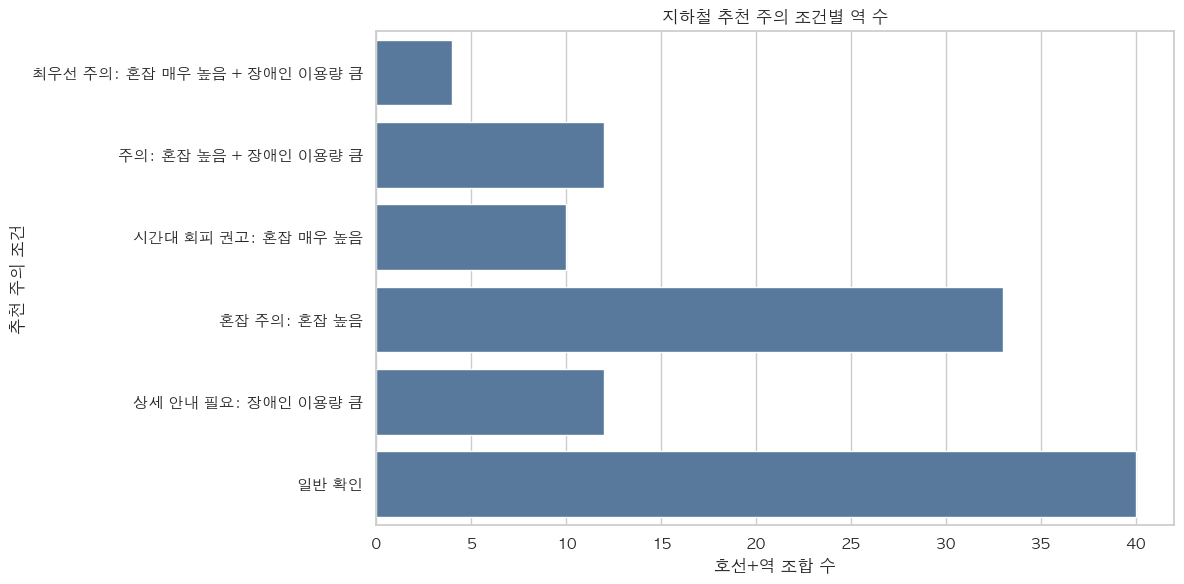

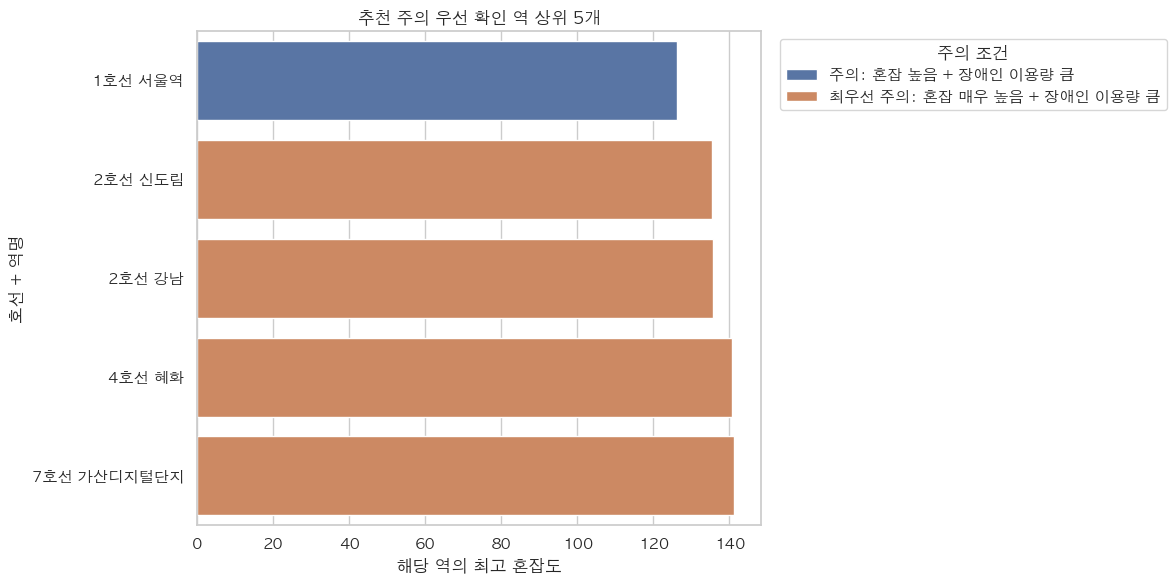

In [27]:
station_peak_time = (
    congestion_matched.sort_values('혼잡도', ascending=False)
    .drop_duplicates(['노선명', '출발역'])
    [[
        '노선명', '출발역', '요일구분', '상하구분', '시간대', '혼잡도',
        '지역명', '장애인총승하차인원수', '운행엘리베이터수', '안전발판수'
    ]]
    .rename(columns={
        '요일구분': '최고혼잡요일구분',
        '상하구분': '최고혼잡상하구분',
        '시간대': '최고혼잡시간대',
        '혼잡도': '최고혼잡도',
    })
)

usage_high_threshold = station_peak_time['장애인총승하차인원수'].quantile(0.75)
station_peak_time['혼잡도_130이상'] = station_peak_time['최고혼잡도'].ge(130)
station_peak_time['혼잡도_100이상'] = station_peak_time['최고혼잡도'].ge(100)
station_peak_time['장애인이용량_상위25퍼센트'] = station_peak_time['장애인총승하차인원수'].ge(usage_high_threshold)

conditions = [
    station_peak_time['혼잡도_130이상'] & station_peak_time['장애인이용량_상위25퍼센트'],
    station_peak_time['혼잡도_100이상'] & station_peak_time['장애인이용량_상위25퍼센트'],
    station_peak_time['혼잡도_130이상'],
    station_peak_time['혼잡도_100이상'],
    station_peak_time['장애인이용량_상위25퍼센트'],
]
choices = [
    '최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼',
    '주의: 혼잡 높음 + 장애인 이용량 큼',
    '시간대 회피 권고: 혼잡 매우 높음',
    '혼잡 주의: 혼잡 높음',
    '상세 안내 필요: 장애인 이용량 큼',
]
station_peak_time['지하철추천주의조건'] = np.select(conditions, choices, default='일반 확인')
station_peak_time['역표시명'] = station_peak_time['노선명'] + ' ' + station_peak_time['출발역']

attention_order = [
    '최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼',
    '주의: 혼잡 높음 + 장애인 이용량 큼',
    '시간대 회피 권고: 혼잡 매우 높음',
    '혼잡 주의: 혼잡 높음',
    '상세 안내 필요: 장애인 이용량 큼',
    '일반 확인',
]
station_peak_time['주의조건순서'] = pd.Categorical(station_peak_time['지하철추천주의조건'], categories=attention_order, ordered=True)
station_recommendation_attention = station_peak_time.sort_values(
    ['주의조건순서', '최고혼잡도', '장애인총승하차인원수'],
    ascending=[True, False, False]
).reset_index(drop=True)

attention_summary = (
    station_recommendation_attention.groupby('지하철추천주의조건', observed=False)
    .size()
    .reindex(attention_order, fill_value=0)
    .reset_index(name='역수')
)
display(attention_summary)

top_attention = station_recommendation_attention.loc[
    station_recommendation_attention['지하철추천주의조건'].ne('일반 확인')
].head(10).copy()
display(top_attention[[
    '지하철추천주의조건', '노선명', '출발역', '지역명',
    '최고혼잡요일구분', '최고혼잡상하구분', '최고혼잡시간대', '최고혼잡도',
    '장애인총승하차인원수', '운행엘리베이터수', '안전발판수'
]])

plt.figure(figsize=(12, 6))
sns.barplot(data=attention_summary, y='지하철추천주의조건', x='역수', color='#4C78A8')
plt.title('지하철 추천 주의 조건별 역 수')
plt.xlabel('호선+역 조합 수')
plt.ylabel('추천 주의 조건')
plt.tight_layout()
plt.show()

if not top_attention.empty:
    plot_attention = top_attention.head(5).sort_values('최고혼잡도')
    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_attention, y='역표시명', x='최고혼잡도', hue='지하철추천주의조건', dodge=False)
    plt.title('추천 주의 우선 확인 역 상위 5개')
    plt.xlabel('해당 역의 최고 혼잡도')
    plt.ylabel('호선 + 역명')
    plt.legend(title='주의 조건', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [28]:
attention_non_normal = station_recommendation_attention.loc[station_recommendation_attention['지하철추천주의조건'].ne('일반 확인')]
most_attention = attention_non_normal.iloc[0] if len(attention_non_normal) else None
critical_count = int(attention_summary.loc[attention_summary['지하철추천주의조건'].eq('최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼'), '역수'].iloc[0])
high_usage_congested_count = int(attention_summary.loc[attention_summary['지하철추천주의조건'].isin([
    '최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼',
    '주의: 혼잡 높음 + 장애인 이용량 큼'
]), '역수'].sum())

result_lines = [
    f'장애인 이용량 상위 25% 기준값은 {usage_high_threshold:,.0f}명이다.',
    f'혼잡도 100 이상이면서 장애인 이용량도 큰 주의 후보는 {high_usage_congested_count:,}개 호선+역 조합이다.',
    f'그중 혼잡도 130 이상과 장애인 이용량 상위 25%가 동시에 나타난 최우선 주의 후보는 {critical_count:,}개다.',
]
if most_attention is not None:
    result_lines.append(
        f'가장 먼저 확인할 후보는 {most_attention["노선명"]} {most_attention["출발역"]}이며, {most_attention["최고혼잡요일구분"]} {most_attention["최고혼잡상하구분"]} {most_attention["최고혼잡시간대"]}에 최고 혼잡도 {most_attention["최고혼잡도"]:.1f}로 나타났다.'
    )

show_result(
    '2-4-2 결과: 지하철 추천 주의 조건',
    result_lines,
    [
        '개발 단계에서 사용자가 해당 시간대에 이 역을 이용하려는 경우 혼잡 주의 문구를 표시한다.',
        '최우선 주의 후보는 콜택시 대안, 다른 시간대, 다른 역 이용 가능성을 함께 보여준다.',
        '이 조건은 임의 점수가 아니라 혼잡도 기준과 장애인 이용량 상위 여부를 조합한 규칙이다.',
    ],
    conclusion='지하철 추천 주의 조건은 혼잡도와 장애인 이용량을 하나의 점수로 합치지 않고, 실제 서비스에서 바로 설명 가능한 규칙으로 나누는 것이 적절하다. 혼잡도가 높고 장애인 이용량도 큰 역은 접근성 시설이 있더라도 이동 부담이 커질 수 있으므로, 네비게이터에서 단순 추천보다 경고·대체 경로·시간대 회피 안내를 함께 제공해야 한다.',
    significance='이 조건은 개발 단계로 넘어갈 때 지하철 추천 로직에 바로 연결할 수 있어 유의미하다. 사용자가 왜 주의 안내를 받는지 설명할 수 있고, 추후 실시간 혼잡도나 열차 도착 정보가 들어와도 같은 규칙 구조를 확장할 수 있다.'
)


#### 2-4-2 결과: 지하철 추천 주의 조건

**결과 해석**

- 장애인 이용량 상위 25% 기준값은 305,703명이다.
- 혼잡도 100 이상이면서 장애인 이용량도 큰 주의 후보는 16개 호선+역 조합이다.
- 그중 혼잡도 130 이상과 장애인 이용량 상위 25%가 동시에 나타난 최우선 주의 후보는 4개다.
- 가장 먼저 확인할 후보는 7호선 가산디지털단지이며, 평일 하선 18시00분에 최고 혼잡도 141.3로 나타났다.

**결론**

- 지하철 추천 주의 조건은 혼잡도와 장애인 이용량을 하나의 점수로 합치지 않고, 실제 서비스에서 바로 설명 가능한 규칙으로 나누는 것이 적절하다. 혼잡도가 높고 장애인 이용량도 큰 역은 접근성 시설이 있더라도 이동 부담이 커질 수 있으므로, 네비게이터에서 단순 추천보다 경고·대체 경로·시간대 회피 안내를 함께 제공해야 한다.

**유의미성**

- 이 조건은 개발 단계로 넘어갈 때 지하철 추천 로직에 바로 연결할 수 있어 유의미하다. 사용자가 왜 주의 안내를 받는지 설명할 수 있고, 추후 실시간 혼잡도나 열차 도착 정보가 들어와도 같은 규칙 구조를 확장할 수 있다.

**이 결과를 바탕으로 이어볼 분석**

- 개발 단계에서 사용자가 해당 시간대에 이 역을 이용하려는 경우 혼잡 주의 문구를 표시한다.
- 최우선 주의 후보는 콜택시 대안, 다른 시간대, 다른 역 이용 가능성을 함께 보여준다.
- 이 조건은 임의 점수가 아니라 혼잡도 기준과 장애인 이용량 상위 여부를 조합한 규칙이다.

#### 2-3-2. 구별 지하철 수요와 콜택시 출발·도착 수요 방향 비교

2-3-1에서 구별 지하철 장애인 이용량을 확인했으므로, 여기서는 같은 구 단위에서 콜택시 출발 수요와 도착 수요가 지하철 수요와 같은 방향으로 움직이는지 비교한다.

확인 기준은 다음과 같다.

- 지하철 구별 장애인 총 승하차인원
- 콜택시 구별 출발건수
- 콜택시 구별 도착건수
- 지하철 수요와 콜택시 출발/도착 수요의 상관계수

주의: 상관계수는 두 값이 같이 커지는 경향이 있는지 보는 탐색 지표이다. 상관이 높다고 해서 지하철 이용이 콜택시 이용을 직접 증가시키거나 감소시킨다는 뜻은 아니다.


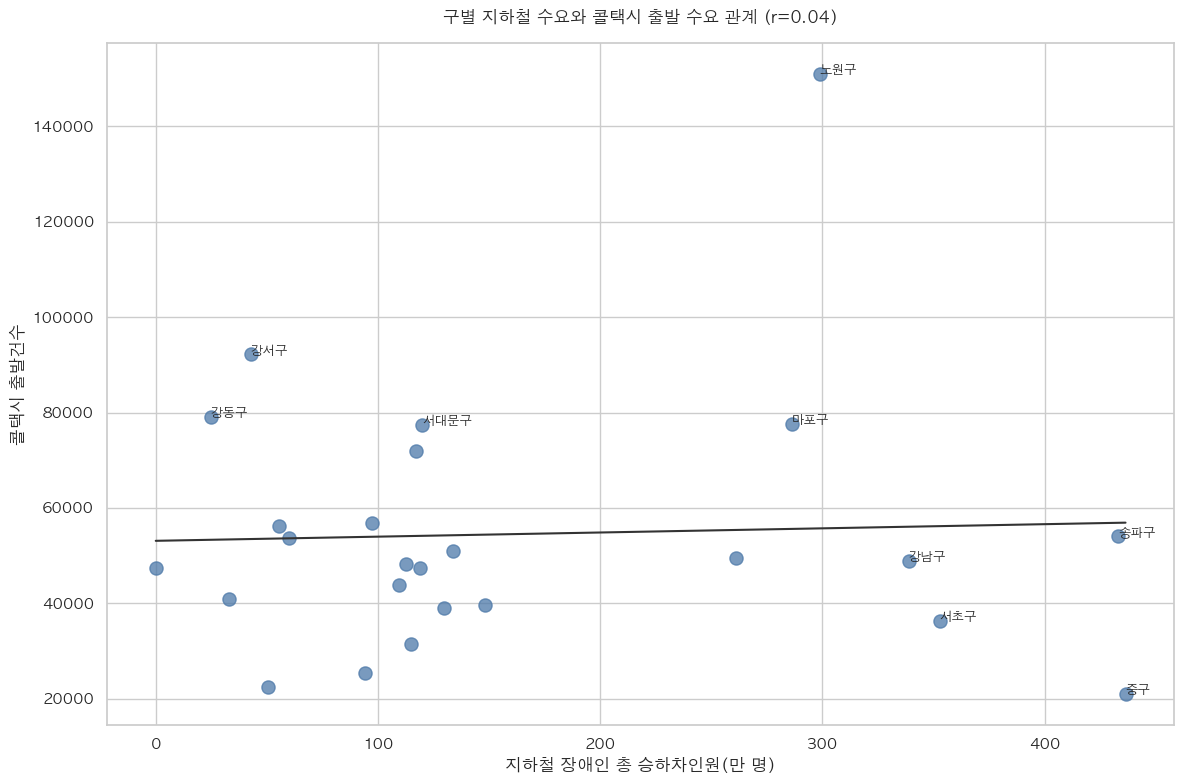

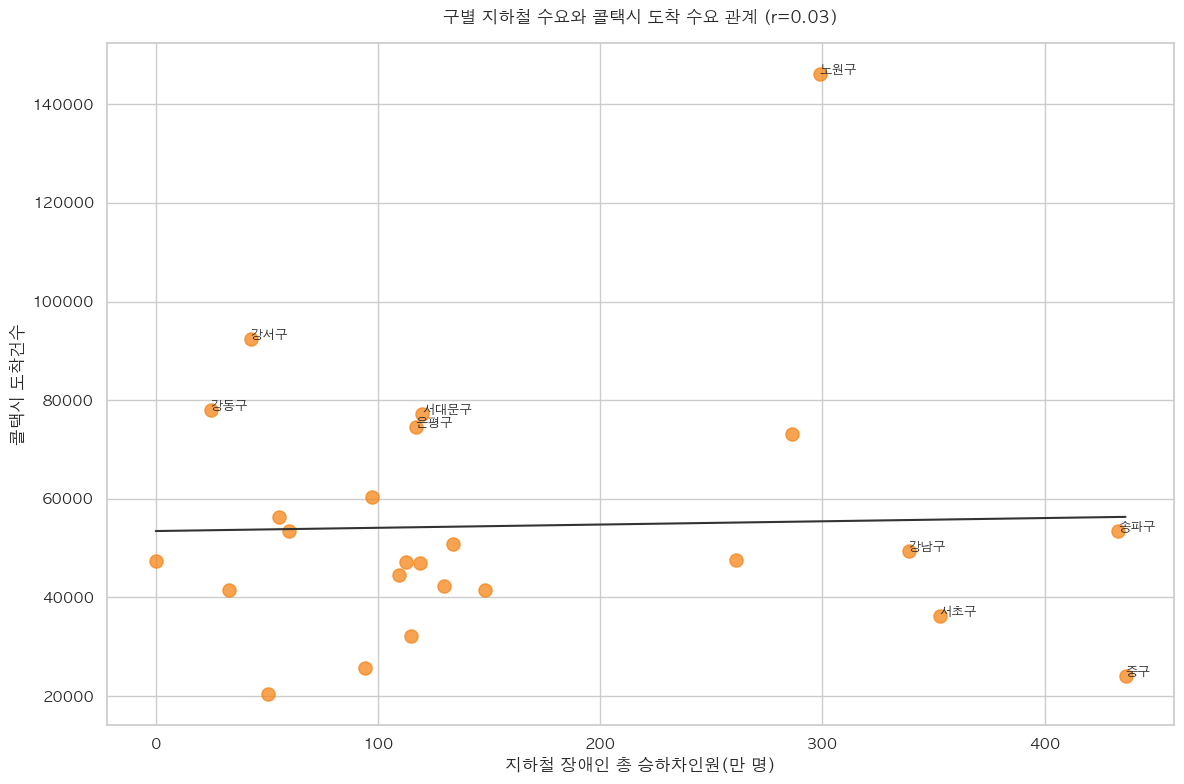

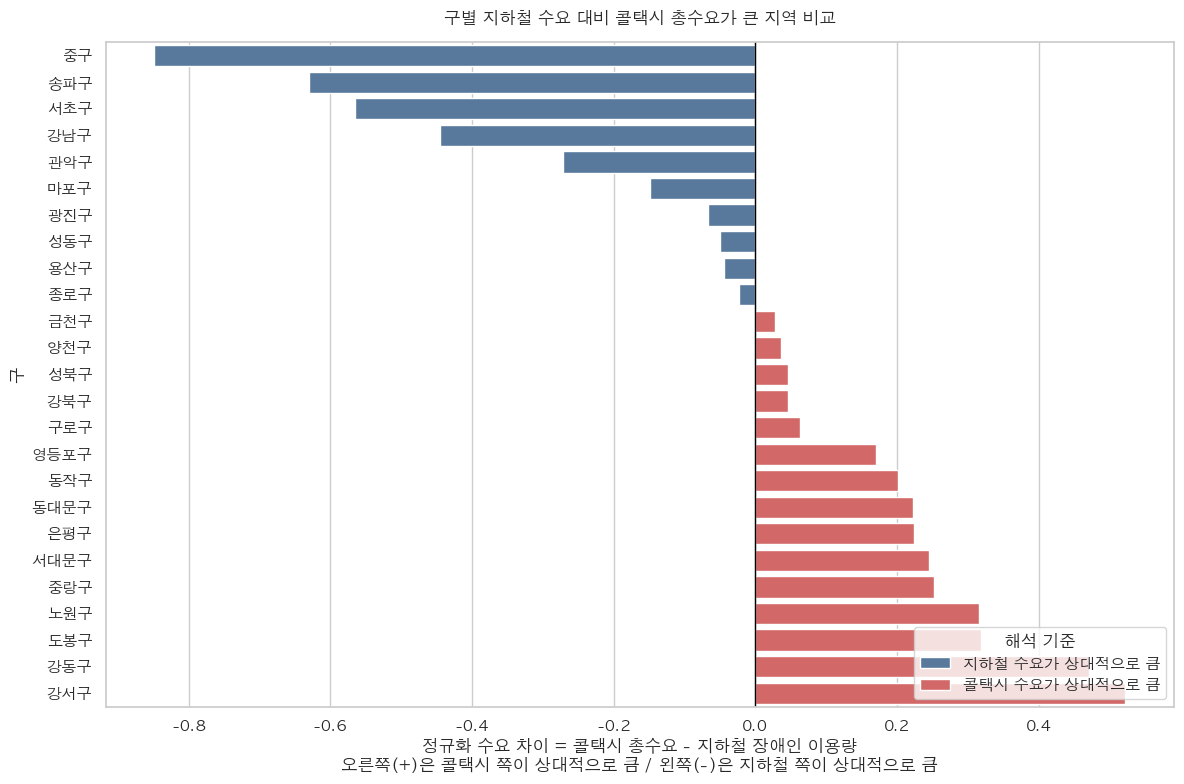

,구분,지역명,지하철_장애인총승하차인원수,콜택시_총수요건수,지하철_장애인총승하차인원수_정규화,콜택시_총수요건수_정규화,지하철_콜택시총수요_차이
0,콜택시 상대 우세 상위 5개 구,강서구,428383.0,184572,0.098167,0.620946,0.522780
1,콜택시 상대 우세 상위 5개 구,강동구,246482.0,157023,0.056483,0.528265,0.471782
2,콜택시 상대 우세 상위 5개 구,도봉구,0.0,94711,0.000000,0.318632,0.318632
3,콜택시 상대 우세 상위 5개 구,노원구,2986937.0,297243,0.684478,1.000000,0.315522
4,콜택시 상대 우세 상위 5개 구,중랑구,552778.0,112552,0.126673,0.378653,0.251980
5,지하철 상대 우세 상위 5개 구,중구,4363819.0,44974,1.000000,0.151304,-0.848696
6,지하철 상대 우세 상위 5개 구,송파구,4330367.0,107644,0.992334,0.362141,-0.630193
7,지하철 상대 우세 상위 5개 구,서초구,3528251.0,72462,0.808524,0.243780,-0.564743
8,지하철 상대 우세 상위 5개 구,강남구,3387404.0,98197,0.776248,0.330359,-0.445888
9,지하철 상대 우세 상위 5개 구,관악구,2610963.0,97136,0.598321,0.326790,-0.271531


In [29]:
taxi_completed_for_compare = taxi.loc[taxi['이용완료여부'].eq(1)].copy()

taxi_origin_for_compare = taxi_completed_for_compare.groupby('출발구', as_index=False).agg(
    콜택시_출발건수=('이용완료여부', 'sum')
).rename(columns={'출발구': '지역명'})

taxi_destination_for_compare = taxi_completed_for_compare.groupby('목적구', as_index=False).agg(
    콜택시_도착건수=('이용완료여부', 'sum')
).rename(columns={'목적구': '지역명'})

subway_taxi_direction = (
    subway_district[['지역명', '지하철_장애인총승하차인원수', '역당_장애인승하차인원수', '지하철_역수']]
    .merge(taxi_origin_for_compare, on='지역명', how='outer')
    .merge(taxi_destination_for_compare, on='지역명', how='outer')
    .fillna(0)
)
subway_taxi_direction['콜택시_총수요건수'] = subway_taxi_direction['콜택시_출발건수'] + subway_taxi_direction['콜택시_도착건수']
subway_taxi_direction['지하철수요_만명'] = subway_taxi_direction['지하철_장애인총승하차인원수'] / 10000

corr_subway_taxi_origin = subway_taxi_direction['지하철_장애인총승하차인원수'].corr(subway_taxi_direction['콜택시_출발건수'])
corr_subway_taxi_destination = subway_taxi_direction['지하철_장애인총승하차인원수'].corr(subway_taxi_direction['콜택시_도착건수'])
corr_subway_taxi_total = subway_taxi_direction['지하철_장애인총승하차인원수'].corr(subway_taxi_direction['콜택시_총수요건수'])

label_origin = subway_taxi_direction.loc[
    (subway_taxi_direction['지하철_장애인총승하차인원수'] >= subway_taxi_direction['지하철_장애인총승하차인원수'].quantile(0.80))
    | (subway_taxi_direction['콜택시_출발건수'] >= subway_taxi_direction['콜택시_출발건수'].quantile(0.80))
]

plt.figure(figsize=(12, 8))
ax = sns.regplot(
    data=subway_taxi_direction,
    x='지하철수요_만명',
    y='콜택시_출발건수',
    scatter_kws={'s': 90, 'alpha': 0.75, 'color': '#4C78A8'},
    line_kws={'color': '#333333', 'linewidth': 1.5},
    ci=None,
)
for _, row in label_origin.iterrows():
    ax.text(row['지하철수요_만명'], row['콜택시_출발건수'], row['지역명'], fontsize=9)
ax.set_title(f'구별 지하철 수요와 콜택시 출발 수요 관계 (r={corr_subway_taxi_origin:.2f})', pad=14)
ax.set_xlabel('지하철 장애인 총 승하차인원(만 명)')
ax.set_ylabel('콜택시 출발건수')
plt.tight_layout()
plt.show()

label_destination = subway_taxi_direction.loc[
    (subway_taxi_direction['지하철_장애인총승하차인원수'] >= subway_taxi_direction['지하철_장애인총승하차인원수'].quantile(0.80))
    | (subway_taxi_direction['콜택시_도착건수'] >= subway_taxi_direction['콜택시_도착건수'].quantile(0.80))
]

plt.figure(figsize=(12, 8))
ax = sns.regplot(
    data=subway_taxi_direction,
    x='지하철수요_만명',
    y='콜택시_도착건수',
    scatter_kws={'s': 90, 'alpha': 0.75, 'color': '#F58518'},
    line_kws={'color': '#333333', 'linewidth': 1.5},
    ci=None,
)
for _, row in label_destination.iterrows():
    ax.text(row['지하철수요_만명'], row['콜택시_도착건수'], row['지역명'], fontsize=9)
ax.set_title(f'구별 지하철 수요와 콜택시 도착 수요 관계 (r={corr_subway_taxi_destination:.2f})', pad=14)
ax.set_xlabel('지하철 장애인 총 승하차인원(만 명)')
ax.set_ylabel('콜택시 도착건수')
plt.tight_layout()
plt.show()

for column in ['지하철_장애인총승하차인원수', '콜택시_출발건수', '콜택시_도착건수', '콜택시_총수요건수']:
    max_value = subway_taxi_direction[column].max()
    subway_taxi_direction[f'{column}_정규화'] = subway_taxi_direction[column] / max_value if max_value else 0

subway_taxi_direction['지하철_콜택시총수요_차이'] = (
    subway_taxi_direction['콜택시_총수요건수_정규화']
    - subway_taxi_direction['지하철_장애인총승하차인원수_정규화']
)
relative_gap_data = subway_taxi_direction.sort_values('지하철_콜택시총수요_차이', ascending=True).copy()
relative_gap_data['상대적으로_큰_수요'] = np.where(
    relative_gap_data['지하철_콜택시총수요_차이'].gt(0),
    '콜택시 수요가 상대적으로 큼',
    '지하철 수요가 상대적으로 큼',
)

plt.figure(figsize=(12, max(7, len(relative_gap_data) * 0.32)))
ax = sns.barplot(
    data=relative_gap_data,
    y='지역명',
    x='지하철_콜택시총수요_차이',
    hue='상대적으로_큰_수요',
    dodge=False,
    palette={
        '콜택시 수요가 상대적으로 큼': '#E45756',
        '지하철 수요가 상대적으로 큼': '#4C78A8',
    },
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('구별 지하철 수요 대비 콜택시 총수요가 큰 지역 비교', pad=14)
ax.set_xlabel('정규화 수요 차이 = 콜택시 총수요 - 지하철 장애인 이용량\n오른쪽(+)은 콜택시 쪽이 상대적으로 큼 / 왼쪽(-)은 지하철 쪽이 상대적으로 큼')
ax.set_ylabel('구')
ax.legend(title='해석 기준', loc='lower right')
plt.tight_layout()
plt.show()

relative_gap_top_bottom = pd.concat([
    subway_taxi_direction.nlargest(5, '지하철_콜택시총수요_차이').assign(구분='콜택시 상대 우세 상위 5개 구'),
    subway_taxi_direction.nsmallest(5, '지하철_콜택시총수요_차이').assign(구분='지하철 상대 우세 상위 5개 구'),
], ignore_index=True)

display(relative_gap_top_bottom[[
    '구분', '지역명',
    '지하철_장애인총승하차인원수', '콜택시_총수요건수',
    '지하철_장애인총승하차인원수_정규화', '콜택시_총수요건수_정규화',
    '지하철_콜택시총수요_차이'
]])


In [30]:
direction_corr_text = (
    '같은 방향성이 비교적 강하다' if corr_subway_taxi_total >= 0.5
    else '같은 방향성이 약하거나 제한적이다' if corr_subway_taxi_total >= 0.2
    else '같은 방향성이 뚜렷하지 않다'
)
show_result(
    '2-3-2 결과: 구별 지하철 수요와 콜택시 출발·도착 수요 방향 비교',
    [
        f'지하철 구별 장애인 총 승하차인원과 콜택시 출발건수의 상관계수는 {corr_subway_taxi_origin:.2f}이다.',
        f'지하철 구별 장애인 총 승하차인원과 콜택시 도착건수의 상관계수는 {corr_subway_taxi_destination:.2f}이다.',
        f'출발+도착을 합친 콜택시 총수요와의 상관계수는 {corr_subway_taxi_total:.2f}로, 현재 데이터에서는 {direction_corr_text}.',
        '정규화 그래프는 단위가 다른 지하철 승하차인원과 콜택시 건수를 같은 화면에서 비교하기 위한 보조 시각화이다.',
    ],
    [
        '3장에서 콜택시 수요 자체를 월별·지역별로 더 자세히 분석한다.',
        '4장에서 지하철 수요와 콜택시 수요의 차이가 큰 지역을 다시 비교한다.',
    ],
    conclusion='구별 지하철 수요와 콜택시 출발·도착 수요를 비교하면 두 교통수단의 수요가 같은 지역에서 함께 커지는지, 아니면 서로 다른 지역에서 나타나는지 확인할 수 있다. 상관이 높다면 해당 구는 전체 이동 수요 자체가 큰 지역일 가능성이 있고, 상관이 낮다면 콜택시가 지하철과 다른 이동 목적이나 접근성 한계를 보완하고 있을 가능성을 추가로 살펴봐야 한다.',
    significance='이 분석은 지하철 수요와 콜택시 수요를 같은 구 단위로 연결하므로 이후 통합 분석의 출발점으로 유의미하다. 다만 상관계수는 인과관계를 설명하지 않으며, 콜택시 목적지 특성·지하철역 위치·장애유형 차이 같은 요인은 추가 분석이 필요하다.'
)


#### 2-3-2 결과: 구별 지하철 수요와 콜택시 출발·도착 수요 방향 비교

**결과 해석**

- 지하철 구별 장애인 총 승하차인원과 콜택시 출발건수의 상관계수는 0.04이다.
- 지하철 구별 장애인 총 승하차인원과 콜택시 도착건수의 상관계수는 0.03이다.
- 출발+도착을 합친 콜택시 총수요와의 상관계수는 0.04로, 현재 데이터에서는 같은 방향성이 뚜렷하지 않다.
- 정규화 그래프는 단위가 다른 지하철 승하차인원과 콜택시 건수를 같은 화면에서 비교하기 위한 보조 시각화이다.

**결론**

- 구별 지하철 수요와 콜택시 출발·도착 수요를 비교하면 두 교통수단의 수요가 같은 지역에서 함께 커지는지, 아니면 서로 다른 지역에서 나타나는지 확인할 수 있다. 상관이 높다면 해당 구는 전체 이동 수요 자체가 큰 지역일 가능성이 있고, 상관이 낮다면 콜택시가 지하철과 다른 이동 목적이나 접근성 한계를 보완하고 있을 가능성을 추가로 살펴봐야 한다.

**유의미성**

- 이 분석은 지하철 수요와 콜택시 수요를 같은 구 단위로 연결하므로 이후 통합 분석의 출발점으로 유의미하다. 다만 상관계수는 인과관계를 설명하지 않으며, 콜택시 목적지 특성·지하철역 위치·장애유형 차이 같은 요인은 추가 분석이 필요하다.

**이 결과를 바탕으로 이어볼 분석**

- 3장에서 콜택시 수요 자체를 월별·지역별로 더 자세히 분석한다.
- 4장에서 지하철 수요와 콜택시 수요의 차이가 큰 지역을 다시 비교한다.

### 2-5. 저상버스와 버스 시간대별 승하차인원 분석

이번 절에서는 새로 정제한 버스 승하차 데이터를 사용해 저상버스 대안 가능성을 확인한다. 버스 데이터에는 실제 차내 혼잡률이나 재차인원은 없으므로, 지하철과 마찬가지로 `시간대별 승차+하차 인원`을 버스 혼잡 가능성의 대체 지표로 사용한다.

분석 기준은 다음과 같다.

- 노선별 시간대 총승하차인원이 클수록 해당 시간대 이용 부담이 클 가능성이 있다.
- 저상버스 비율이 낮은 노선은 휠체어 이용자에게 실제 대안성이 낮을 수 있다.
- 따라서 `시간대별 수요가 큰 노선`과 `저상버스 비율이 낮거나 100%가 아닌 노선`을 함께 확인한다.


,저상버스추천주의조건,노선시간대수,총승하차인원
0,수요 높음: 저상버스 100% 노선,939,525993259
1,주의: 수요 높음 + 저상버스 100% 아님,3363,1870839317


,구분,노선번호,노선명,교통수단타입명,연간총승하차인원,최대시간대승하차인원,인가대수,저상버스대수,저상버스비율_표시
0,연간 이용량 상위 5개 노선,143,143번(정릉~개포동),서울간선버스,25754998,1975523,50.0,34.0,68.000000
1,연간 이용량 상위 5개 노선,272,272번(면목동~남가좌동),서울간선버스,22019848,1692909,41.0,28.0,68.292683
2,연간 이용량 상위 5개 노선,160,160번(도봉산~온수동),서울간선버스,21682889,1981778,49.0,42.0,85.714286
3,연간 이용량 상위 5개 노선,271,271번(용마문화복지센터~월드컵파크7단지),서울간선버스,21552309,1757932,45.0,39.0,86.666667
4,연간 이용량 상위 5개 노선,130,130번(우이동~길동),서울간선버스,20574274,1646697,42.0,24.0,57.142857
5,연간 이용량 하위 5개 노선,8002,8002번(상명대앞~경복궁역),서울지선버스,1,1,0.0,0.0,0.000000
6,연간 이용량 하위 5개 노선,8333A,8333A(암사역사공원역~힐스테이트리슈빌강일),서울지선버스,4384,2006,NaN,NaN,0.000000
7,연간 이용량 하위 5개 노선,8333B,8333B(힐스테이트리슈빌강일~암사역사공원역),서울지선버스,5726,3744,NaN,NaN,0.000000
8,연간 이용량 하위 5개 노선,서울03출근,서울03출근(홍대입구역~파주시운정지구),서울광역버스,6710,2828,NaN,NaN,0.000000
9,연간 이용량 하위 5개 노선,서울06출근,서울06출근(강남역~광주시능평동),서울광역버스,8091,4641,NaN,NaN,0.000000


,저상버스추천주의조건,노선번호,노선명,교통수단타입명,시간대,총승하차인원,승차인원,하차인원,인가대수,저상버스대수,저상버스비율
1818,주의: 수요 높음 + 저상버스 100% 아님,160,160번(도봉산~온수동),서울간선버스,18,1981778,986761,995017,49.0,42.0,0.857143
1602,주의: 수요 높음 + 저상버스 100% 아님,143,143번(정릉~개포동),서울간선버스,18,1975523,993597,981926,50.0,34.0,0.680000
1601,주의: 수요 높음 + 저상버스 100% 아님,143,143번(정릉~개포동),서울간선버스,17,1908524,977577,930947,50.0,34.0,0.680000
1746,주의: 수요 높음 + 저상버스 100% 아님,150,150번(도봉산~석수역),서울간선버스,18,1862717,930392,932325,50.0,43.0,0.860000
1592,주의: 수요 높음 + 저상버스 100% 아님,143,143번(정릉~개포동),서울간선버스,8,1852799,931688,921111,50.0,34.0,0.680000


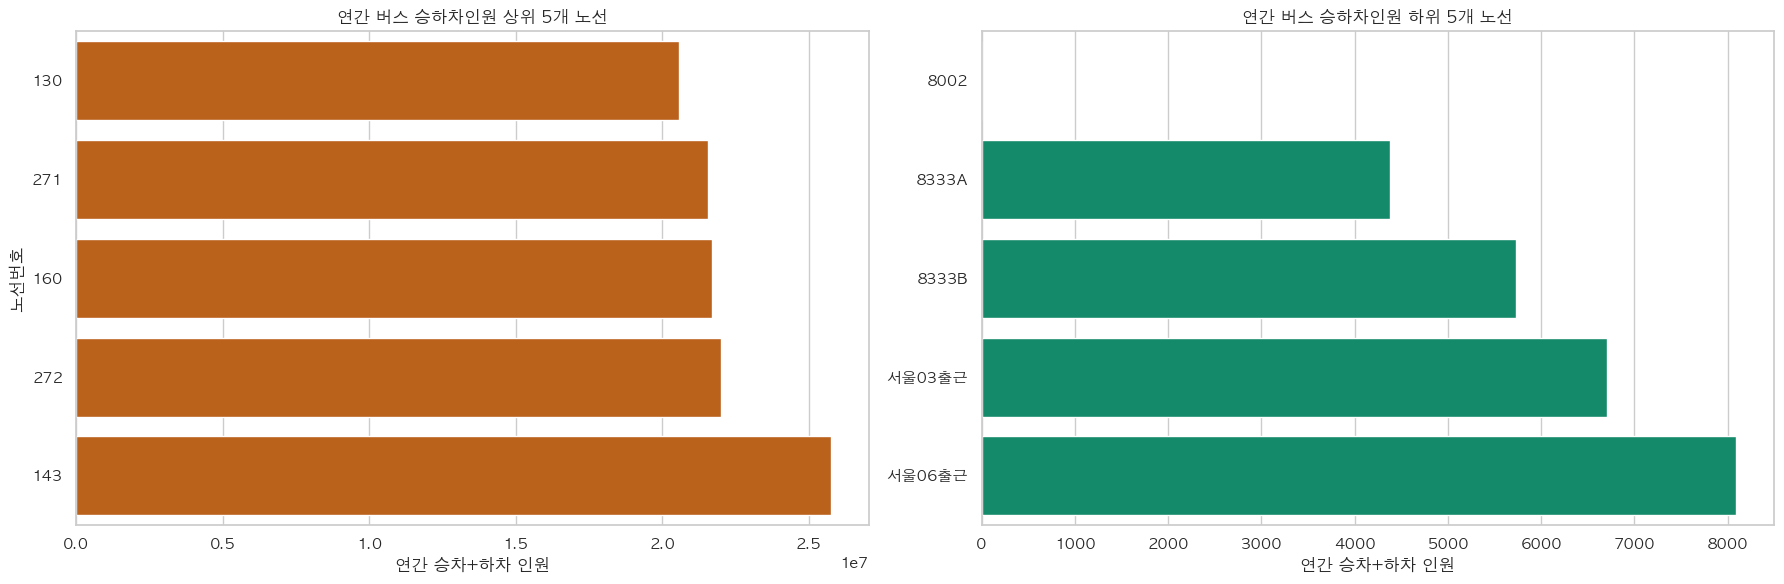

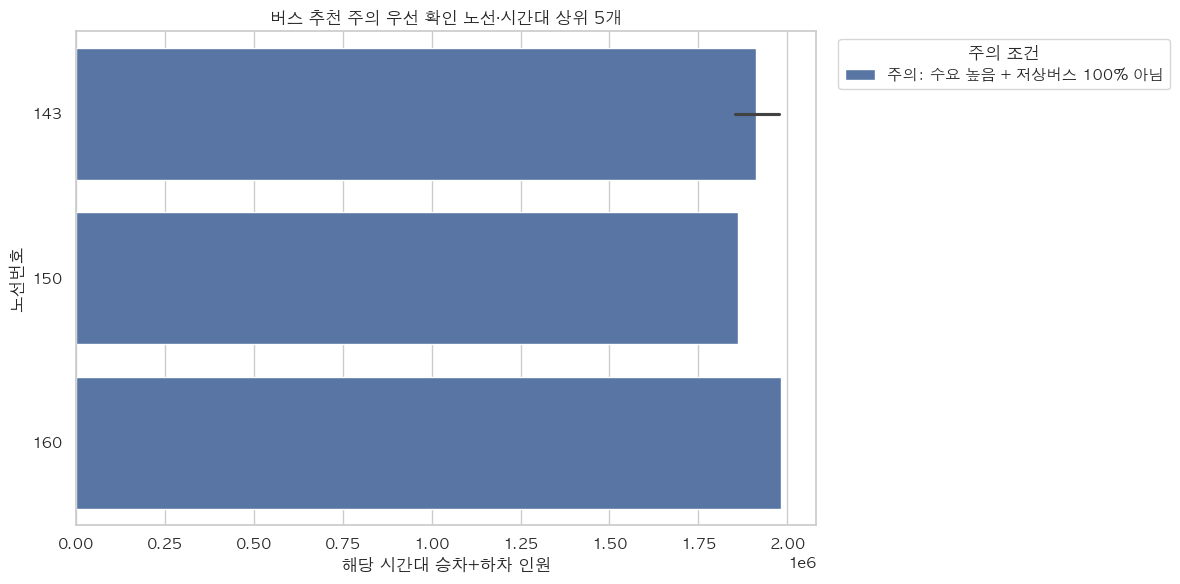

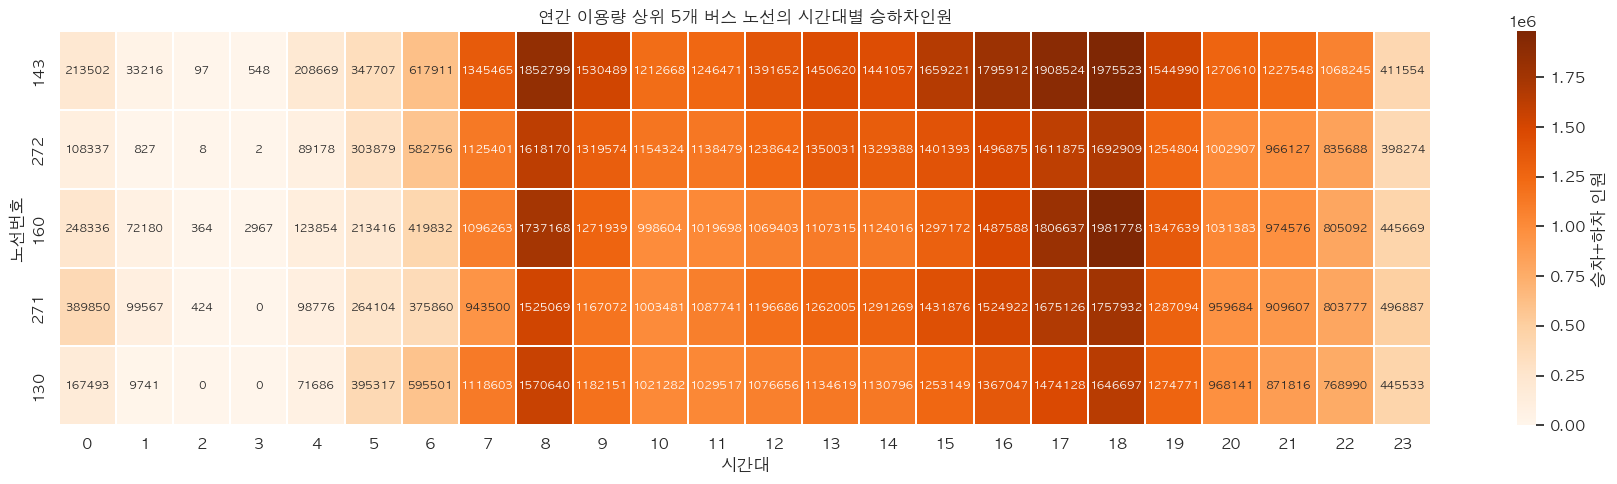

In [31]:
bus_route_hour = pd.read_csv(BUS_ROUTE_HOUR_PATH, encoding='utf-8-sig')
bus_route_stop = pd.read_csv(BUS_ROUTE_STOP_PATH, encoding='utf-8-sig')

for df in [bus_route_hour, bus_route_stop]:
    if '저상버스비율' in df.columns:
        df['저상버스비율'] = pd.to_numeric(df['저상버스비율'], errors='coerce')
    for column in ['승차인원', '하차인원', '총승하차인원']:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors='coerce').fillna(0)

bus_route_summary = (
    bus_route_hour.groupby(['노선번호', '노선명', '교통수단타입명'], as_index=False)
    .agg(
        연간총승하차인원=('총승하차인원', 'sum'),
        최대시간대승하차인원=('총승하차인원', 'max'),
        인가대수=('인가대수', 'max'),
        저상버스대수=('저상버스대수', 'max'),
        저상버스비율=('저상버스비율', 'max'),
    )
)
bus_route_summary['저상버스비율'] = bus_route_summary['저상버스비율'].fillna(0)
bus_route_summary['완전저상노선여부'] = bus_route_summary['저상버스비율'].ge(1)
bus_route_summary['저상버스비율_표시'] = bus_route_summary['저상버스비율'] * 100

route_hour_threshold = bus_route_hour['총승하차인원'].quantile(0.75)
bus_route_hour['시간대수요상위25여부'] = bus_route_hour['총승하차인원'].ge(route_hour_threshold)
bus_route_hour['저상버스비율'] = pd.to_numeric(bus_route_hour['저상버스비율'], errors='coerce').fillna(0)
bus_route_hour['완전저상노선여부'] = bus_route_hour['저상버스비율'].ge(1)

bus_attention = bus_route_hour.loc[bus_route_hour['시간대수요상위25여부']].copy()
bus_attention['저상버스추천주의조건'] = np.where(
    bus_attention['완전저상노선여부'],
    '수요 높음: 저상버스 100% 노선',
    '주의: 수요 높음 + 저상버스 100% 아님'
)
bus_attention = bus_attention.sort_values(['저상버스추천주의조건', '총승하차인원'], ascending=[False, False])

bus_attention_summary = (
    bus_attention.groupby('저상버스추천주의조건', as_index=False)
    .agg(노선시간대수=('총승하차인원', 'count'), 총승하차인원=('총승하차인원', 'sum'))
)
display(bus_attention_summary)

top_bus_routes = bus_route_summary.nlargest(5, '연간총승하차인원').copy()
bottom_bus_routes = bus_route_summary.nsmallest(5, '연간총승하차인원').copy()
bus_route_top_bottom = pd.concat([
    top_bus_routes.assign(구분='연간 이용량 상위 5개 노선'),
    bottom_bus_routes.assign(구분='연간 이용량 하위 5개 노선'),
], ignore_index=True)
display(bus_route_top_bottom[[
    '구분', '노선번호', '노선명', '교통수단타입명', '연간총승하차인원',
    '최대시간대승하차인원', '인가대수', '저상버스대수', '저상버스비율_표시'
]])

attention_top5 = bus_attention.head(5).copy()
display(attention_top5[[
    '저상버스추천주의조건', '노선번호', '노선명', '교통수단타입명', '시간대',
    '총승하차인원', '승차인원', '하차인원', '인가대수', '저상버스대수', '저상버스비율'
]])

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)
route_top_plot = top_bus_routes.sort_values('연간총승하차인원')
route_bottom_plot = bottom_bus_routes.sort_values('연간총승하차인원')
sns.barplot(data=route_top_plot, y='노선번호', x='연간총승하차인원', color='#D55E00', ax=axes[0])
axes[0].set_title('연간 버스 승하차인원 상위 5개 노선')
axes[0].set_xlabel('연간 승차+하차 인원')
axes[0].set_ylabel('노선번호')
sns.barplot(data=route_bottom_plot, y='노선번호', x='연간총승하차인원', color='#009E73', ax=axes[1])
axes[1].set_title('연간 버스 승하차인원 하위 5개 노선')
axes[1].set_xlabel('연간 승차+하차 인원')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

if not attention_top5.empty:
    plt.figure(figsize=(12, 6))
    plot_attention = attention_top5.sort_values('총승하차인원')
    sns.barplot(data=plot_attention, y='노선번호', x='총승하차인원', hue='저상버스추천주의조건', dodge=False)
    plt.title('버스 추천 주의 우선 확인 노선·시간대 상위 5개')
    plt.xlabel('해당 시간대 승차+하차 인원')
    plt.ylabel('노선번호')
    plt.legend(title='주의 조건', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 시간대 패턴은 상위 5개 노선만 보여 발표용 가독성을 유지한다.
top_route_numbers = top_bus_routes['노선번호'].astype(str).tolist()
bus_time_pivot = (
    bus_route_hour.loc[bus_route_hour['노선번호'].astype(str).isin(top_route_numbers)]
    .pivot_table(index='노선번호', columns='시간대', values='총승하차인원', aggfunc='sum')
    .reindex(index=top_route_numbers)
)
plt.figure(figsize=(18, max(5, len(bus_time_pivot) * 0.7)))
sns.heatmap(bus_time_pivot, cmap='Oranges', annot=True, fmt='.0f', linewidths=0.25, annot_kws={'size': 8}, cbar_kws={'label': '승차+하차 인원'})
plt.title('연간 이용량 상위 5개 버스 노선의 시간대별 승하차인원')
plt.xlabel('시간대')
plt.ylabel('노선번호')
plt.tight_layout()
plt.show()


In [32]:
top_bus_route = bus_route_summary.sort_values('연간총승하차인원', ascending=False).iloc[0]
attention_non_full_low = bus_attention.loc[bus_attention['저상버스추천주의조건'].eq('주의: 수요 높음 + 저상버스 100% 아님')]
attention_total = len(bus_attention)
attention_non_full_count = len(attention_non_full_low)
first_attention = bus_attention.iloc[0] if attention_total else None

result_lines = [
    f'정제된 버스 노선×시간대 데이터는 {len(bus_route_hour):,}행이며, 노선-정류장 총량 데이터는 {len(bus_route_stop):,}행이다.',
    f'연간 승하차인원이 가장 큰 노선은 {top_bus_route["노선번호"]}번이며, 연간 총 {top_bus_route["연간총승하차인원"]:,.0f}명이다.',
    f'노선×시간대 기준 승하차인원 상위 25% 기준값은 {route_hour_threshold:,.0f}명이다.',
    f'수요가 높은 노선×시간대 후보는 {attention_total:,}개이고, 이 중 저상버스가 100%가 아닌 주의 후보는 {attention_non_full_count:,}개다.',
]
if first_attention is not None:
    result_lines.append(
        f'우선 확인 후보는 {first_attention["노선번호"]}번 {int(first_attention["시간대"])}시이며, 해당 시간대 총승하차인원은 {first_attention["총승하차인원"]:,.0f}명이다.'
    )

show_result(
    '2-5 결과: 저상버스와 버스 시간대별 승하차인원 분석',
    result_lines,
    [
        '버스 데이터에는 실제 차내 혼잡도나 재차인원이 없으므로 시간대별 승차+하차 인원을 혼잡 가능성 대체 지표로 사용한다.',
        '개발 단계에서는 지하철 혼잡 주의 조건과 함께, 주변 저상버스 노선의 수요와 저상버스 비율을 비교한다.',
        '정류장 좌표가 연결된 노선-정류장 데이터는 이후 사용자 위치 주변 저상버스 대안 탐색에 활용한다.',
    ],
    conclusion='버스 승하차 데이터와 저상버스 비율을 함께 보면, 단순히 저상버스 노선이 있는지뿐 아니라 실제로 이용 수요가 큰 시간대에 저상버스 대안성이 충분한지도 확인할 수 있다. 다만 현재 버스 데이터는 혼잡률 자체가 아니라 승하차 인원이므로, 버스 혼잡도는 대체 지표로 해석해야 한다.',
    significance='이 분석은 네비게이터 개발에서 지하철·콜택시 외에 저상버스 대안을 판단하기 위한 기반으로 유의미하다. 특히 혼잡한 지하철역 주변에 저상버스 노선이 있더라도 저상버스 비율이 낮거나 버스 수요가 매우 높은 시간대라면 주의 안내가 필요하다.'
)


#### 2-5 결과: 저상버스와 버스 시간대별 승하차인원 분석

**결과 해석**

- 정제된 버스 노선×시간대 데이터는 17,208행이며, 노선-정류장 총량 데이터는 52,337행이다.
- 연간 승하차인원이 가장 큰 노선은 143번이며, 연간 총 25,754,998명이다.
- 노선×시간대 기준 승하차인원 상위 25% 기준값은 282,786명이다.
- 수요가 높은 노선×시간대 후보는 4,302개이고, 이 중 저상버스가 100%가 아닌 주의 후보는 3,363개다.
- 우선 확인 후보는 160번 18시이며, 해당 시간대 총승하차인원은 1,981,778명이다.

**결론**

- 버스 승하차 데이터와 저상버스 비율을 함께 보면, 단순히 저상버스 노선이 있는지뿐 아니라 실제로 이용 수요가 큰 시간대에 저상버스 대안성이 충분한지도 확인할 수 있다. 다만 현재 버스 데이터는 혼잡률 자체가 아니라 승하차 인원이므로, 버스 혼잡도는 대체 지표로 해석해야 한다.

**유의미성**

- 이 분석은 네비게이터 개발에서 지하철·콜택시 외에 저상버스 대안을 판단하기 위한 기반으로 유의미하다. 특히 혼잡한 지하철역 주변에 저상버스 노선이 있더라도 저상버스 비율이 낮거나 버스 수요가 매우 높은 시간대라면 주의 안내가 필요하다.

**이 결과를 바탕으로 이어볼 분석**

- 버스 데이터에는 실제 차내 혼잡도나 재차인원이 없으므로 시간대별 승차+하차 인원을 혼잡 가능성 대체 지표로 사용한다.
- 개발 단계에서는 지하철 혼잡 주의 조건과 함께, 주변 저상버스 노선의 수요와 저상버스 비율을 비교한다.
- 정류장 좌표가 연결된 노선-정류장 데이터는 이후 사용자 위치 주변 저상버스 대안 탐색에 활용한다.

#### 2-5-2. 저상버스 추정 재차인원 기반 혼잡 구간 분석

앞의 2-5에서는 시간대별 `승차+하차 인원`으로 버스 수요가 큰 노선과 시간대를 확인했다. 여기서는 한 단계 더 들어가서, 노선별 정류장 순서를 이용해 `누적 승차인원 - 누적 하차인원` 방식으로 저상버스 노선의 혼잡 구간 후보를 추정한다.

주의할 점은 다음과 같다.

- 현재 데이터는 월별 집계 승하차 인원이므로 특정 순간의 실제 버스 탑승 인원은 아니다.
- 따라서 여기서의 `추정재차인원`은 실제 차내 혼잡률이 아니라, 연간 집계 기준으로 사람이 많이 남아 있을 가능성이 큰 정류장 구간을 찾는 대체 지표다.
- 저상버스 대수가 적은 노선은 같은 수요라도 휠체어 이용자 입장에서 대안성이 낮을 수 있으므로 `저상버스 1대당 추정재차인원`도 함께 본다.


/var/folders/y9/b9fl_31960z4vxqlt7sp4clm0000gn/T/ipykernel_41849/2488236260.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  lowfloor_bus_congestion = pd.read_csv(BUS_LOWFLOOR_CONGESTION_PATH, encoding='utf-8-sig')


,구분,노선번호,노선명,교통수단타입명,시간대,방향,정류장순번,역명,추정재차인원_보정,저상버스대수,저상버스비율,저상버스1대당_추정재차인원
0,저상버스 1대당 추정 혼잡 상위 5개 노선,3317,3317(남한산성입구~잠실새내역),서울지선버스,8,잠실새내역,11.0,가락쌍용1차아파트(00011),58394,1,0.090909,58394.000000
1,저상버스 1대당 추정 혼잡 상위 5개 노선,8561,8561번(신림동~여의도환승센터),서울지선버스,7,여의도환승센터,9.0,공군호텔(00009),55026,1,0.250000,55026.000000
2,저상버스 1대당 추정 혼잡 상위 5개 노선,2112,2112번(면목동~성북동),서울지선버스,18,면목동,92.0,장한평역3번출구(00091),96765,2,0.142857,48382.500000
3,저상버스 1대당 추정 혼잡 상위 5개 노선,8551,8551번(봉천역~노량진역),서울지선버스,7,노량진역,8.0,상도2동아이파크.포스코더샵아파트(00008),43695,1,0.200000,43695.000000
4,저상버스 1대당 추정 혼잡 상위 5개 노선,6613,6613(양천공영차고지~대림역),서울지선버스,7,대림역,30.0,은정초등학교(00030),39676,1,0.100000,39676.000000
5,저상버스 1대당 추정 혼잡 하위 5개 노선,5413,5413번(시흥~고속터미널),서울지선버스,1,고속터미널,24.0,봉천역.관악초등학교(00024),3,26,0.962963,0.115385
6,저상버스 1대당 추정 혼잡 하위 5개 노선,7730,7730번(은평공영차고지~이북오도청),서울지선버스,0,은평차고지,52.0,은평구청(00052),1468,14,0.777778,104.857143
7,저상버스 1대당 추정 혼잡 하위 5개 노선,753,753번(구산동~상도동),서울간선버스,0,구산동,84.0,북가좌동삼거리(00084),10498,21,1.000000,499.904762
8,저상버스 1대당 추정 혼잡 하위 5개 노선,702B,702B번(원당~종로1가),서울간선버스,7,종로1가,23.0,신사동고개삼거리(00023),52879,40,1.000000,1321.975000
9,저상버스 1대당 추정 혼잡 하위 5개 노선,173,173번(월계동~연세대),서울간선버스,4,신촌기차역,21.0,우신향병원(00021),36880,24,0.960000,1536.666667


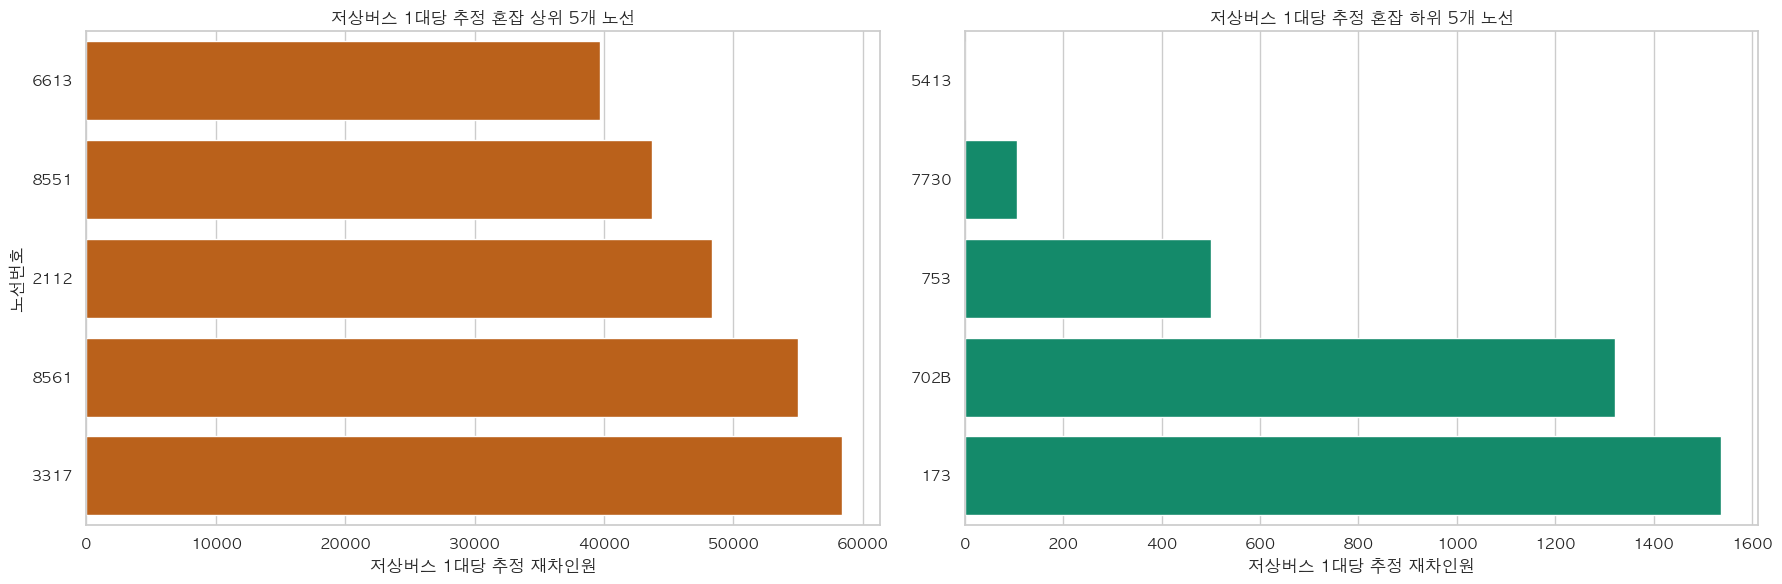

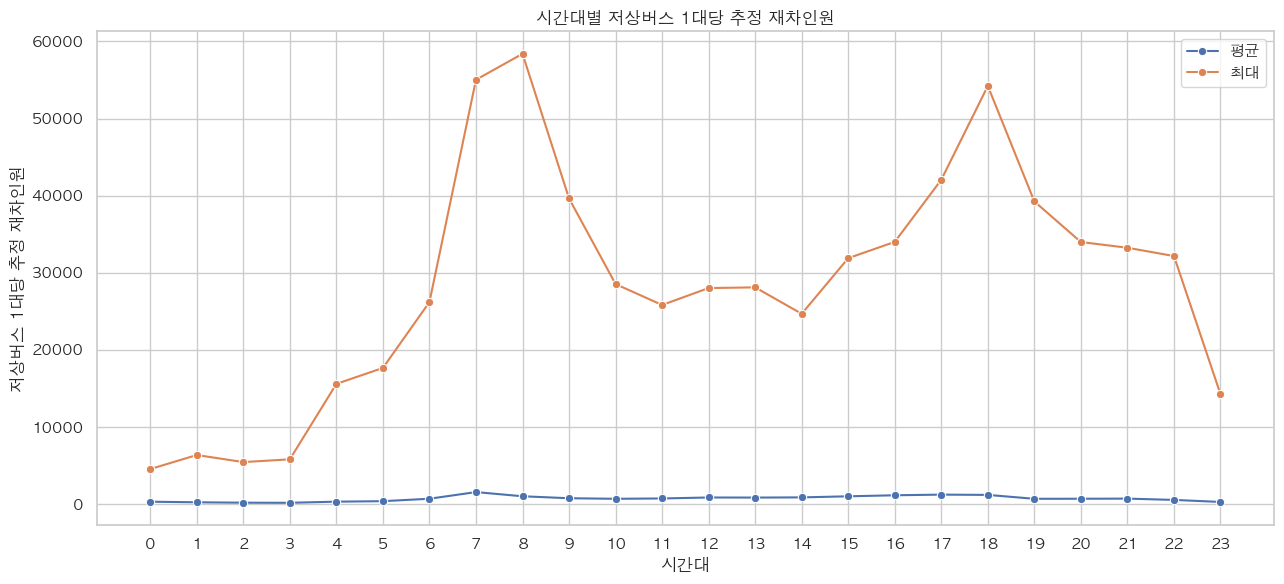

,노선번호,노선명,시간대,방향,정류장순번,역명,추정재차인원_보정,저상버스대수,저상버스비율,저상버스1대당_추정재차인원
261458,3317,3317(남한산성입구~잠실새내역),8,잠실새내역,11.0,가락쌍용1차아파트(00011),58394,1,0.090909,58394.0
261456,3317,3317(남한산성입구~잠실새내역),8,잠실새내역,9.0,송파도서관(00009),57487,1,0.090909,57487.0
261459,3317,3317(남한산성입구~잠실새내역),8,잠실새내역,12.0,가락동미륭아파트(00012),56828,1,0.090909,56828.0
261457,3317,3317(남한산성입구~잠실새내역),8,잠실새내역,10.0,송파중학교(00010),56654,1,0.090909,56654.0
261455,3317,3317(남한산성입구~잠실새내역),8,잠실새내역,8.0,오금동사거리(00008),56075,1,0.090909,56075.0
767763,8561,8561번(신림동~여의도환승센터),7,여의도환승센터,9.0,공군호텔(00009),55026,1,0.250000,55026.0
261038,3317,3317(남한산성입구~잠실새내역),18,남한산성입구,29.0,문정1동주민센터.로데오거리(00029),54225,1,0.090909,54225.0
261037,3317,3317(남한산성입구~잠실새내역),18,남한산성입구,29.0,문정1동주민센터.로데오거리(00027),52574,1,0.090909,52574.0
261039,3317,3317(남한산성입구~잠실새내역),18,남한산성입구,30.0,가락현대1차아파트정문(00028),52196,1,0.090909,52196.0
261460,3317,3317(남한산성입구~잠실새내역),8,잠실새내역,13.0,문정1동주민센터.로데오거리(00013),51668,1,0.090909,51668.0


In [33]:
lowfloor_bus_congestion = pd.read_csv(BUS_LOWFLOOR_CONGESTION_PATH, encoding='utf-8-sig')
for column in ['시간대', '정류장순번', '승차인원', '하차인원', '추정재차인원_보정', '저상버스대수', '저상버스비율', '저상버스1대당_추정재차인원']:
    if column in lowfloor_bus_congestion.columns:
        lowfloor_bus_congestion[column] = pd.to_numeric(lowfloor_bus_congestion[column], errors='coerce')

lowfloor_peak_by_route = (
    lowfloor_bus_congestion.sort_values('저상버스1대당_추정재차인원', ascending=False)
    .drop_duplicates(['노선번호'])
    .reset_index(drop=True)
)
lowfloor_peak_top5 = lowfloor_peak_by_route.head(5).copy()
lowfloor_peak_bottom5 = lowfloor_peak_by_route.sort_values('저상버스1대당_추정재차인원').head(5).copy()
lowfloor_peak_top_bottom = pd.concat([
    lowfloor_peak_top5.assign(구분='저상버스 1대당 추정 혼잡 상위 5개 노선'),
    lowfloor_peak_bottom5.assign(구분='저상버스 1대당 추정 혼잡 하위 5개 노선'),
], ignore_index=True)

display(lowfloor_peak_top_bottom[[
    '구분', '노선번호', '노선명', '교통수단타입명', '시간대', '방향', '정류장순번', '역명',
    '추정재차인원_보정', '저상버스대수', '저상버스비율', '저상버스1대당_추정재차인원'
]])

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)
top_plot = lowfloor_peak_top5.sort_values('저상버스1대당_추정재차인원')
bottom_plot = lowfloor_peak_bottom5.sort_values('저상버스1대당_추정재차인원')
sns.barplot(data=top_plot, y='노선번호', x='저상버스1대당_추정재차인원', color='#D55E00', ax=axes[0])
axes[0].set_title('저상버스 1대당 추정 혼잡 상위 5개 노선')
axes[0].set_xlabel('저상버스 1대당 추정 재차인원')
axes[0].set_ylabel('노선번호')
sns.barplot(data=bottom_plot, y='노선번호', x='저상버스1대당_추정재차인원', color='#009E73', ax=axes[1])
axes[1].set_title('저상버스 1대당 추정 혼잡 하위 5개 노선')
axes[1].set_xlabel('저상버스 1대당 추정 재차인원')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

lowfloor_time_summary = (
    lowfloor_bus_congestion.groupby('시간대', as_index=False)
    .agg(
        평균_저상버스1대당추정재차=('저상버스1대당_추정재차인원', 'mean'),
        최대_저상버스1대당추정재차=('저상버스1대당_추정재차인원', 'max'),
        상위25구간수=('저상버스혼잡상위25여부', 'sum'),
    )
)
plt.figure(figsize=(13, 6))
sns.lineplot(data=lowfloor_time_summary, x='시간대', y='평균_저상버스1대당추정재차', marker='o', label='평균')
sns.lineplot(data=lowfloor_time_summary, x='시간대', y='최대_저상버스1대당추정재차', marker='o', label='최대')
plt.title('시간대별 저상버스 1대당 추정 재차인원')
plt.xlabel('시간대')
plt.ylabel('저상버스 1대당 추정 재차인원')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

lowfloor_attention = lowfloor_bus_congestion.loc[lowfloor_bus_congestion['저상버스혼잡상위25여부'].eq(True)].copy()
lowfloor_attention_top10 = lowfloor_attention.sort_values('저상버스1대당_추정재차인원', ascending=False).head(10)
display(lowfloor_attention_top10[[
    '노선번호', '노선명', '시간대', '방향', '정류장순번', '역명',
    '추정재차인원_보정', '저상버스대수', '저상버스비율', '저상버스1대당_추정재차인원'
]])


In [34]:
top_lowfloor_congestion = lowfloor_peak_top5.iloc[0]
peak_time_lowfloor = lowfloor_time_summary.sort_values('평균_저상버스1대당추정재차', ascending=False).iloc[0]
lowfloor_attention_count = len(lowfloor_attention)
show_result(
    '2-5-2 결과: 저상버스 추정 재차인원 기반 혼잡 구간 분석',
    [
        f'저상버스 추정 혼잡도 데이터는 {len(lowfloor_bus_congestion):,}행이다.',
        f'저상버스 1대당 추정 재차인원이 가장 큰 노선은 {top_lowfloor_congestion["노선번호"]}번이며, {int(top_lowfloor_congestion["시간대"])}시 {top_lowfloor_congestion["역명"]} 구간에서 크게 나타났다.',
        f'시간대 평균 기준으로 저상버스 1대당 추정 재차인원이 가장 큰 시간대는 {int(peak_time_lowfloor["시간대"])}시다.',
        f'상위 25%에 해당하는 저상버스 혼잡 후보 구간은 {lowfloor_attention_count:,}개다.',
    ],
    [
        '개발 단계에서는 이 결과를 저상버스 추천 시 혼잡 주의 문구를 붙이는 보조 조건으로 사용한다.',
        '정확한 차내 혼잡률이 아니라 집계 승하차 기반 추정값이므로 최종 추천에서는 설명 문구를 함께 제공한다.',
        '사용자 위치 주변 후보 노선이 여러 개라면 저상버스 비율과 추정 혼잡도를 함께 비교한다.',
    ],
    conclusion='저상버스 노선이 있다고 해서 항상 좋은 대안이 되는 것은 아니다. 저상버스 대수가 적고 특정 시간대·구간에 승하차 수요가 크게 누적되는 노선은 휠체어 이용자에게 실제 탑승 부담이 클 수 있다. 따라서 네비게이터는 저상버스 존재 여부뿐 아니라 저상버스 비율과 추정 혼잡 구간을 함께 고려해야 한다.',
    significance='이 분석은 버스 대안을 개발 로직에 넣을 때 유의미하다. 지하철 혼잡도가 높을 때 저상버스를 대안으로 제시하더라도, 해당 저상버스 노선 자체가 혼잡 후보라면 콜택시나 다른 시간대 이동을 함께 제안해야 하기 때문이다.'
)


#### 2-5-2 결과: 저상버스 추정 재차인원 기반 혼잡 구간 분석

**결과 해석**

- 저상버스 추정 혼잡도 데이터는 896,304행이다.
- 저상버스 1대당 추정 재차인원이 가장 큰 노선은 3317번이며, 8시 가락쌍용1차아파트(00011) 구간에서 크게 나타났다.
- 시간대 평균 기준으로 저상버스 1대당 추정 재차인원이 가장 큰 시간대는 7시다.
- 상위 25%에 해당하는 저상버스 혼잡 후보 구간은 224,084개다.

**결론**

- 저상버스 노선이 있다고 해서 항상 좋은 대안이 되는 것은 아니다. 저상버스 대수가 적고 특정 시간대·구간에 승하차 수요가 크게 누적되는 노선은 휠체어 이용자에게 실제 탑승 부담이 클 수 있다. 따라서 네비게이터는 저상버스 존재 여부뿐 아니라 저상버스 비율과 추정 혼잡 구간을 함께 고려해야 한다.

**유의미성**

- 이 분석은 버스 대안을 개발 로직에 넣을 때 유의미하다. 지하철 혼잡도가 높을 때 저상버스를 대안으로 제시하더라도, 해당 저상버스 노선 자체가 혼잡 후보라면 콜택시나 다른 시간대 이동을 함께 제안해야 하기 때문이다.

**이 결과를 바탕으로 이어볼 분석**

- 개발 단계에서는 이 결과를 저상버스 추천 시 혼잡 주의 문구를 붙이는 보조 조건으로 사용한다.
- 정확한 차내 혼잡률이 아니라 집계 승하차 기반 추정값이므로 최종 추천에서는 설명 문구를 함께 제공한다.
- 사용자 위치 주변 후보 노선이 여러 개라면 저상버스 비율과 추정 혼잡도를 함께 비교한다.

#### 2-5-3. 지하철 혼잡 주의 역 주변 저상버스 대안 후보 분석

이번 분석은 지하철 혼잡 주의 역에서 저상버스가 대안이 될 수 있는지 확인하기 위한 1차 연결 분석이다.

현재 정제 지하철 데이터에는 역 좌표가 없으므로, 정확한 반경 500m 공간 분석 대신 `버스 정류장명에 지하철역명이 포함되는지`를 기준으로 주변 저상버스 정류장 후보를 찾는다.

해석 기준은 다음과 같다.

- 혼잡 주의 지하철역명과 같은 이름이 들어간 버스 정류장이 있으면 저상버스 대안 후보로 본다.
- 해당 정류장을 지나는 노선의 저상버스 비율과 저상버스 추정 혼잡 부담을 함께 확인한다.
- 이 결과는 개발용 1차 후보이며, 추후 지하철역 좌표가 확보되면 반경 300m/500m 기준으로 정교화한다.


,대안분류,역수
0,근처 저상버스 노선 없음,1
1,저상버스 노선 있음 + 저상버스 비율 낮음,31
2,저상버스 노선 있음 + 혼잡 부담 큼,39


,지하철노선명,지하철역명,지하철추천주의조건,지하철최고혼잡도,버스대안여부,대안노선수,대안정류장수,평균저상버스비율,최대저상버스부담,대안분류
33,5호선,애오개,혼잡 주의: 혼잡 높음,123.7,False,0,0,NaN,NaN,근처 저상버스 노선 없음
19,2호선,서초,시간대 회피 권고: 혼잡 매우 높음,145.7,True,53,61,0.756576,12878.000000,저상버스 노선 있음 + 저상버스 비율 낮음
0,7호선,가산디지털단지,최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼,141.3,True,10,6,0.769591,11293.142857,저상버스 노선 있음 + 저상버스 비율 낮음
2,2호선,강남,최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼,135.7,True,80,59,0.797555,55026.000000,저상버스 노선 있음 + 저상버스 비율 낮음
3,2호선,신도림,최우선 주의: 혼잡 매우 높음 + 장애인 이용량 큼,135.3,True,20,11,0.706410,18435.250000,저상버스 노선 있음 + 저상버스 비율 낮음
22,5호선,길동,시간대 회피 권고: 혼잡 매우 높음,135.3,True,18,21,0.649900,19011.333333,저상버스 노선 있음 + 저상버스 비율 낮음
24,8호선,가락시장,시간대 회피 권고: 혼잡 매우 높음,133.5,True,23,11,0.770573,58394.000000,저상버스 노선 있음 + 저상버스 비율 낮음
26,8호선,장지,혼잡 주의: 혼잡 높음,129.3,True,26,10,0.776177,5616.533333,저상버스 노선 있음 + 저상버스 비율 낮음
27,8호선,송파,혼잡 주의: 혼잡 높음,129.3,True,41,93,0.771645,58394.000000,저상버스 노선 있음 + 저상버스 비율 낮음
28,5호선,여의도,혼잡 주의: 혼잡 높음,128.5,True,30,20,0.793994,55026.000000,저상버스 노선 있음 + 저상버스 비율 낮음


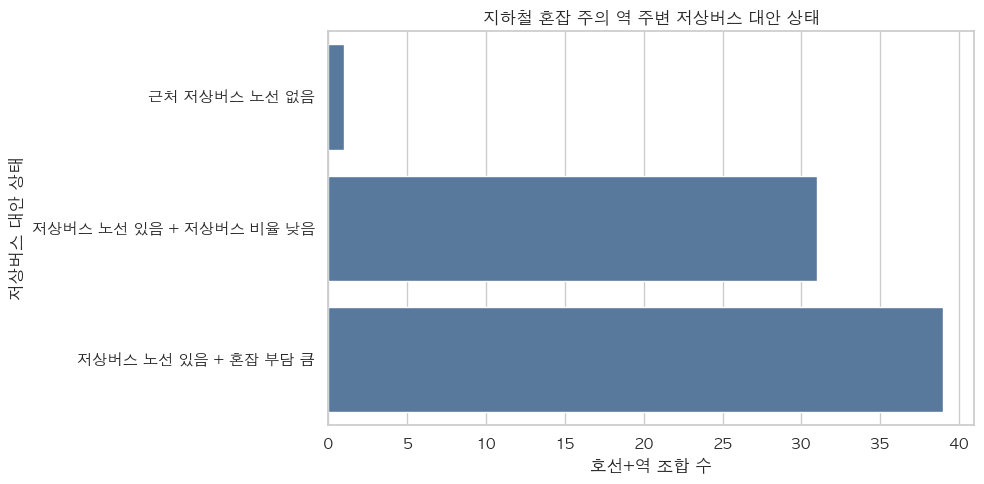

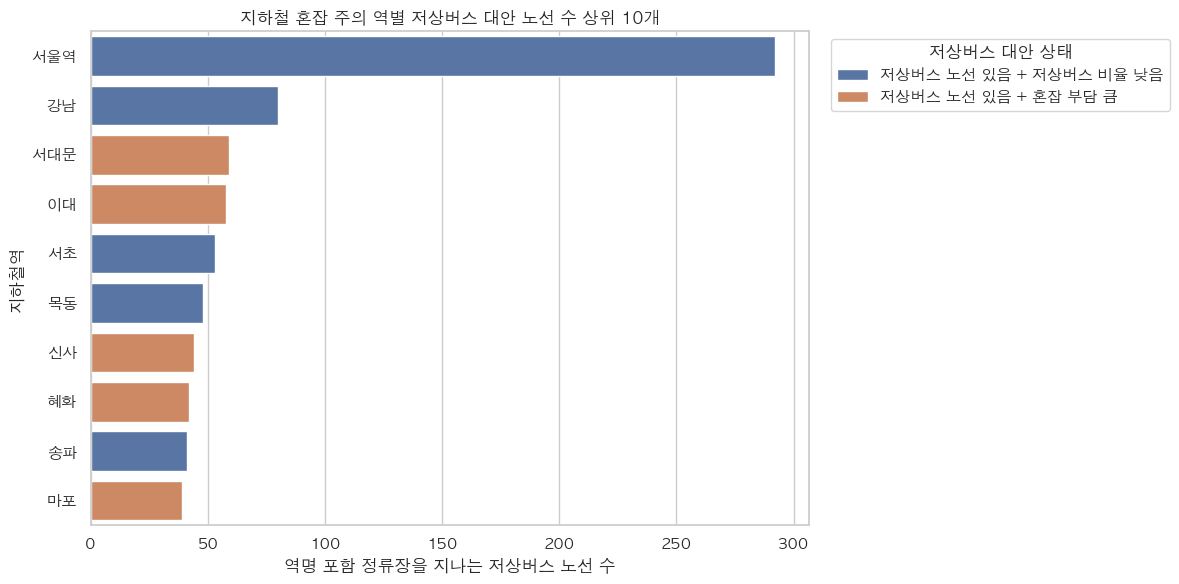

In [35]:
subway_attention_stations = station_recommendation_attention.loc[
    station_recommendation_attention['지하철추천주의조건'].ne('일반 확인')
].copy()
subway_attention_stations['역명정규화'] = subway_attention_stations['출발역'].astype(str).str.replace(r'역$', '', regex=True)

bus_stop_candidates = bus_route_stop.copy()
bus_stop_candidates['정류장명정규화'] = bus_stop_candidates['역명'].astype(str).str.replace(' ', '', regex=False)
bus_stop_candidates['노선번호'] = bus_stop_candidates['노선번호'].astype(str)

lowfloor_peak_for_route = (
    lowfloor_bus_congestion.sort_values('저상버스1대당_추정재차인원', ascending=False)
    .drop_duplicates('노선번호')
    [['노선번호', '저상버스1대당_추정재차인원', '시간대', '방향', '역명']]
    .rename(columns={
        '저상버스1대당_추정재차인원': '노선최대_저상버스1대당추정재차',
        '시간대': '노선최대혼잡시간대',
        '방향': '노선최대혼잡방향',
        '역명': '노선최대혼잡정류장',
    })
)
lowfloor_peak_for_route['노선번호'] = lowfloor_peak_for_route['노선번호'].astype(str)

matches = []
for _, station in subway_attention_stations.iterrows():
    keyword = str(station['역명정규화']).replace(' ', '')
    if not keyword or keyword == 'nan':
        continue
    cand = bus_stop_candidates.loc[bus_stop_candidates['정류장명정규화'].str.contains(keyword, na=False)].copy()
    if cand.empty:
        matches.append({
            '지하철노선명': station['노선명'],
            '지하철역명': station['출발역'],
            '지하철추천주의조건': station['지하철추천주의조건'],
            '지하철최고혼잡도': station['최고혼잡도'],
            '버스대안여부': False,
            '대안노선수': 0,
            '대안정류장수': 0,
        })
        continue
    cand = cand.merge(lowfloor_peak_for_route, on='노선번호', how='left')
    low_cand = cand.loc[pd.to_numeric(cand['저상버스대수'], errors='coerce').fillna(0).gt(0)].copy()
    matches.append({
        '지하철노선명': station['노선명'],
        '지하철역명': station['출발역'],
        '지하철추천주의조건': station['지하철추천주의조건'],
        '지하철최고혼잡도': station['최고혼잡도'],
        '버스대안여부': len(low_cand) > 0,
        '대안노선수': low_cand['노선번호'].nunique(),
        '대안정류장수': low_cand['버스정류장ARS번호'].nunique(),
        '평균저상버스비율': low_cand['저상버스비율'].mean() if len(low_cand) else np.nan,
        '최대저상버스부담': low_cand['노선최대_저상버스1대당추정재차'].max() if len(low_cand) else np.nan,
    })

subway_bus_alternative = pd.DataFrame(matches)
subway_bus_alternative['대안분류'] = np.select(
    [
        subway_bus_alternative['버스대안여부'].eq(False),
        subway_bus_alternative['평균저상버스비율'].ge(0.8) & subway_bus_alternative['최대저상버스부담'].lt(lowfloor_bus_congestion['저상버스1대당_추정재차인원'].quantile(0.75)),
        subway_bus_alternative['평균저상버스비율'].ge(0.8),
    ],
    ['근처 저상버스 노선 없음', '저상버스 노선 있음 + 공급/혼잡 양호', '저상버스 노선 있음 + 혼잡 부담 큼'],
    default='저상버스 노선 있음 + 저상버스 비율 낮음'
)

alternative_summary = subway_bus_alternative.groupby('대안분류', as_index=False).agg(역수=('지하철역명', 'count'))
display(alternative_summary)

display(subway_bus_alternative.sort_values(['대안분류', '지하철최고혼잡도'], ascending=[True, False]).head(15))

plt.figure(figsize=(10, 5))
sns.barplot(data=alternative_summary, y='대안분류', x='역수', color='#4C78A8')
plt.title('지하철 혼잡 주의 역 주변 저상버스 대안 상태')
plt.xlabel('호선+역 조합 수')
plt.ylabel('저상버스 대안 상태')
plt.tight_layout()
plt.show()

plot_alt = subway_bus_alternative.sort_values('대안노선수', ascending=False).head(10).copy()
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_alt, y='지하철역명', x='대안노선수', hue='대안분류', dodge=False)
plt.title('지하철 혼잡 주의 역별 저상버스 대안 노선 수 상위 10개')
plt.xlabel('역명 포함 정류장을 지나는 저상버스 노선 수')
plt.ylabel('지하철역')
plt.legend(title='저상버스 대안 상태', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [36]:
alt_possible_count = int(subway_bus_alternative['버스대안여부'].sum())
alt_total_count = len(subway_bus_alternative)
alt_lack_count = int(subway_bus_alternative['대안분류'].eq('근처 저상버스 노선 없음').sum())
best_alt = subway_bus_alternative.sort_values(['대안노선수', '평균저상버스비율'], ascending=False).iloc[0] if alt_total_count else None
show_result(
    '2-5-3 결과: 지하철 혼잡 주의 역 주변 저상버스 대안 후보',
    [
        f'지하철 혼잡 주의 역 {alt_total_count:,}개 호선+역 조합을 대상으로 버스 정류장명 매칭을 수행했다.',
        f'이 중 역명 기준으로 근처 저상버스 노선이 확인된 조합은 {alt_possible_count:,}개이고, 저상버스 노선이 확인되지 않은 조합은 {alt_lack_count:,}개다.',
        f'저상버스 대안 노선 수가 가장 많은 후보는 {best_alt["지하철역명"]}이며, 대안 노선 수는 {best_alt["대안노선수"]:,.0f}개다.' if best_alt is not None else '확인 가능한 저상버스 대안 후보가 없다.',
    ],
    [
        '현재는 역명 포함 정류장 기준의 1차 후보 분석이므로, 개발 단계에서는 지하철역 좌표를 확보해 반경 300m/500m 분석으로 고도화한다.',
        '저상버스 노선이 있더라도 저상버스 비율이 낮거나 혼잡 부담이 큰 경우 추천 시 주의 문구를 함께 제공한다.',
        '지하철 혼잡 주의 + 근처 저상버스 노선 없음인 경우 콜택시 비교를 더 우선적으로 보여준다.',
    ],
    conclusion='지하철 혼잡 주의 역 주변에 저상버스 대안이 있는지 확인하면, 단순히 지하철을 피하라는 안내에서 끝나지 않고 실제 대체 이동수단 후보를 제시할 수 있다. 다만 현재 매칭은 정류장명 기반이므로, 최종 개발에서는 좌표 기반 반경 탐색으로 보완해야 한다.',
    significance='이 분석은 네비게이터의 핵심 판단 구조와 직접 연결된다. 지하철이 혼잡한 경우 저상버스가 대안인지, 아니면 콜택시를 함께 비교해야 하는지를 구분하는 첫 번째 규칙으로 활용할 수 있다.'
)


#### 2-5-3 결과: 지하철 혼잡 주의 역 주변 저상버스 대안 후보

**결과 해석**

- 지하철 혼잡 주의 역 71개 호선+역 조합을 대상으로 버스 정류장명 매칭을 수행했다.
- 이 중 역명 기준으로 근처 저상버스 노선이 확인된 조합은 70개이고, 저상버스 노선이 확인되지 않은 조합은 1개다.
- 저상버스 대안 노선 수가 가장 많은 후보는 서울역이며, 대안 노선 수는 292개다.

**결론**

- 지하철 혼잡 주의 역 주변에 저상버스 대안이 있는지 확인하면, 단순히 지하철을 피하라는 안내에서 끝나지 않고 실제 대체 이동수단 후보를 제시할 수 있다. 다만 현재 매칭은 정류장명 기반이므로, 최종 개발에서는 좌표 기반 반경 탐색으로 보완해야 한다.

**유의미성**

- 이 분석은 네비게이터의 핵심 판단 구조와 직접 연결된다. 지하철이 혼잡한 경우 저상버스가 대안인지, 아니면 콜택시를 함께 비교해야 하는지를 구분하는 첫 번째 규칙으로 활용할 수 있다.

**이 결과를 바탕으로 이어볼 분석**

- 현재는 역명 포함 정류장 기준의 1차 후보 분석이므로, 개발 단계에서는 지하철역 좌표를 확보해 반경 300m/500m 분석으로 고도화한다.
- 저상버스 노선이 있더라도 저상버스 비율이 낮거나 혼잡 부담이 큰 경우 추천 시 주의 문구를 함께 제공한다.
- 지하철 혼잡 주의 + 근처 저상버스 노선 없음인 경우 콜택시 비교를 더 우선적으로 보여준다.

#### 2-5-4. 지하철 불편 구간의 저상버스 보완 가능성 분석

이번 분석은 저상버스와 지하철의 관계를 단순 상관관계가 아니라 `보완 가능성`으로 본다. 즉, 지하철이 혼잡하거나 접근성 조건이 약한 역 주변에서 저상버스가 실제 대안이 될 수 있는지를 확인한다.

분류 기준은 다음과 같다.

- 지하철 불편 조건: 혼잡 주의 조건이 있거나 접근성 부족 조건이 있는 경우
- 저상버스 보완 조건: 역명 기준 주변 저상버스 노선이 있고, 저상버스 비율과 혼잡 부담이 양호한 경우
- 저상버스 주의 조건: 주변 저상버스 노선은 있으나 저상버스 비율이 낮거나 혼잡 부담이 큰 경우
- 콜택시 우선 검토 조건: 지하철도 불편하고 주변 저상버스 대안도 확인되지 않는 경우

현재는 정류장명 기준 1차 매칭이므로, 최종 개발에서는 지하철역 좌표 기반 반경 탐색으로 보완해야 한다.


/var/folders/y9/b9fl_31960z4vxqlt7sp4clm0000gn/T/ipykernel_41849/2275767184.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  subway_bus_complement['버스대안여부'] = subway_bus_complement['버스대안여부'].fillna(False)


,보완가능성분류,역조합수,평균지하철최고혼잡도,평균대안노선수
0,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,70,112.350000,26.1
1,지하철 우선 가능: 큰 불편 없음 + 저상버스 대안 없음,4,76.475000,0.0
2,콜택시 우선 검토: 지하철 불편 + 저상버스 대안 없음,37,67.727027,0.0


,보완가능성분류,지하철노선명,지하철역명,지역명,최고혼잡도,부족조건개수,대안노선수,평균저상버스비율,최대저상버스부담,대안분류
16,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,5호선,마포,마포구,164.3,1,39.0,0.806958,12830.000000,저상버스 노선 있음 + 혼잡 부담 큼
17,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,5호선,공덕,마포구,149.1,0,19.0,0.821811,11994.500000,저상버스 노선 있음 + 혼잡 부담 큼
18,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,2호선,방배,서초구,147.3,1,20.0,0.879561,6671.153846,저상버스 노선 있음 + 혼잡 부담 큼
19,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,2호선,서초,서초구,145.7,0,53.0,0.756576,12878.000000,저상버스 노선 있음 + 저상버스 비율 낮음
0,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,7호선,가산디지털단지,금천구,141.3,2,10.0,0.769591,11293.142857,저상버스 노선 있음 + 저상버스 비율 낮음
1,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,4호선,혜화,종로구,140.7,0,42.0,0.821460,48382.500000,저상버스 노선 있음 + 혼잡 부담 큼
20,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,7호선,건대입구,광진구,137.6,1,12.0,0.878592,4656.600000,저상버스 노선 있음 + 혼잡 부담 큼
21,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,3호선,독립문,서대문구,137.2,1,23.0,0.857380,9457.833333,저상버스 노선 있음 + 혼잡 부담 큼
2,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,2호선,강남,서초구,135.7,1,80.0,0.797555,55026.000000,저상버스 노선 있음 + 저상버스 비율 낮음
3,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,2호선,신도림,구로구,135.3,0,20.0,0.706410,18435.250000,저상버스 노선 있음 + 저상버스 비율 낮음


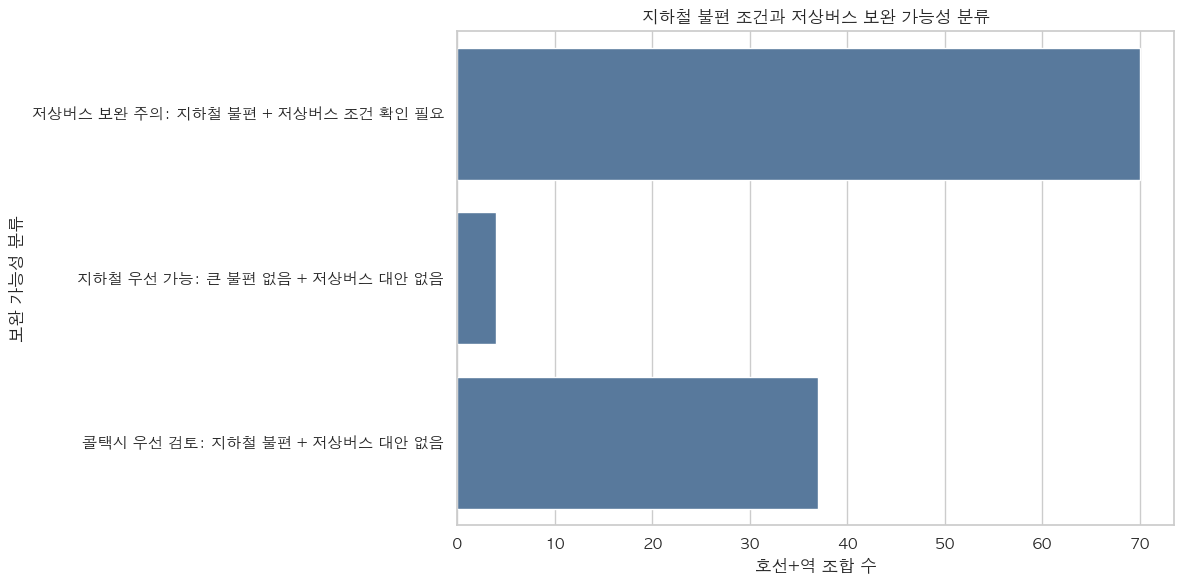

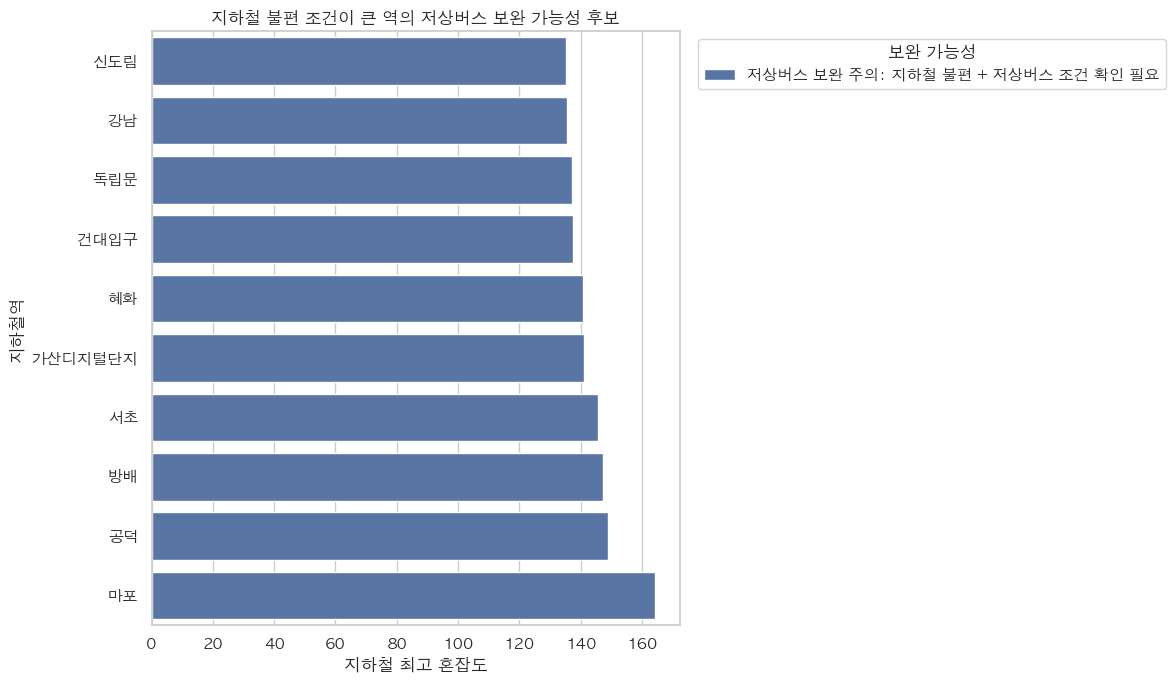

In [37]:
subway_discomfort = station_recommendation_attention[[
    '노선명', '출발역', '지역명', '최고혼잡도', '지하철추천주의조건',
    '장애인총승하차인원수', '운행엘리베이터수', '안전발판수'
]].copy()
subway_discomfort = subway_discomfort.rename(columns={'노선명': '지하철노선명', '출발역': '지하철역명'})

risk_for_complement = station_demand.copy()
risk_for_complement['엘리베이터부족여부'] = risk_for_complement['운행엘리베이터수'].le(1).astype('int64')
risk_for_complement['안전발판부족여부'] = risk_for_complement['안전발판수'].eq(0).astype('int64')
risk_for_complement['화장실부족여부'] = risk_for_complement['휠체어접근가능화장실수'].eq(0).astype('int64')
risk_for_complement['충전기부족여부'] = risk_for_complement['휠체어급속충전기수'].eq(0).astype('int64')
risk_for_complement['부족조건개수'] = risk_for_complement[[
    '엘리베이터부족여부', '안전발판부족여부', '화장실부족여부', '충전기부족여부'
]].sum(axis=1)
risk_for_complement = risk_for_complement[[
    '노선명', '역명', '부족조건개수', '엘리베이터부족여부', '안전발판부족여부', '화장실부족여부', '충전기부족여부'
]].rename(columns={'노선명': '지하철노선명', '역명': '지하철역명'})

subway_discomfort = subway_discomfort.merge(
    risk_for_complement,
    on=['지하철노선명', '지하철역명'],
    how='left'
)
for column in ['부족조건개수', '엘리베이터부족여부', '안전발판부족여부', '화장실부족여부', '충전기부족여부']:
    subway_discomfort[column] = subway_discomfort[column].fillna(0)

subway_discomfort['지하철혼잡주의여부'] = subway_discomfort['지하철추천주의조건'].ne('일반 확인')
subway_discomfort['지하철접근성주의여부'] = subway_discomfort['부족조건개수'].gt(0)
subway_discomfort['지하철불편조건여부'] = subway_discomfort['지하철혼잡주의여부'] | subway_discomfort['지하철접근성주의여부']

bus_alt_for_complement = subway_bus_alternative[[
    '지하철노선명', '지하철역명', '버스대안여부', '대안노선수', '대안정류장수',
    '평균저상버스비율', '최대저상버스부담', '대안분류'
]].copy()

subway_bus_complement = subway_discomfort.merge(
    bus_alt_for_complement,
    on=['지하철노선명', '지하철역명'],
    how='left'
)
subway_bus_complement['버스대안여부'] = subway_bus_complement['버스대안여부'].fillna(False)
subway_bus_complement['대안노선수'] = subway_bus_complement['대안노선수'].fillna(0)
subway_bus_complement['대안정류장수'] = subway_bus_complement['대안정류장수'].fillna(0)
subway_bus_complement['대안분류'] = subway_bus_complement['대안분류'].fillna('근처 저상버스 노선 없음')

bus_burden_threshold = lowfloor_bus_congestion['저상버스1대당_추정재차인원'].quantile(0.75)
subway_bus_complement['저상버스비율양호여부'] = subway_bus_complement['평균저상버스비율'].ge(0.8)
subway_bus_complement['저상버스혼잡부담낮음여부'] = subway_bus_complement['최대저상버스부담'].lt(bus_burden_threshold)

conditions = [
    subway_bus_complement['지하철불편조건여부'] & subway_bus_complement['버스대안여부'].eq(False),
    subway_bus_complement['지하철불편조건여부'] & subway_bus_complement['버스대안여부'] & subway_bus_complement['저상버스비율양호여부'] & subway_bus_complement['저상버스혼잡부담낮음여부'],
    subway_bus_complement['지하철불편조건여부'] & subway_bus_complement['버스대안여부'],
    subway_bus_complement['지하철불편조건여부'].eq(False) & subway_bus_complement['버스대안여부'],
]
choices = [
    '콜택시 우선 검토: 지하철 불편 + 저상버스 대안 없음',
    '저상버스 보완 가능: 지하철 불편 + 저상버스 조건 양호',
    '저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요',
    '선택 가능: 지하철 큰 불편 없음 + 저상버스 대안 있음',
]
subway_bus_complement['보완가능성분류'] = np.select(conditions, choices, default='지하철 우선 가능: 큰 불편 없음 + 저상버스 대안 없음')

complement_summary = subway_bus_complement.groupby('보완가능성분류', as_index=False).agg(
    역조합수=('지하철역명', 'count'),
    평균지하철최고혼잡도=('최고혼잡도', 'mean'),
    평균대안노선수=('대안노선수', 'mean'),
)
display(complement_summary)

complement_priority = subway_bus_complement.loc[
    subway_bus_complement['보완가능성분류'].isin([
        '콜택시 우선 검토: 지하철 불편 + 저상버스 대안 없음',
        '저상버스 보완 가능: 지하철 불편 + 저상버스 조건 양호',
        '저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요',
    ])
].sort_values(['보완가능성분류', '최고혼잡도'], ascending=[True, False])

display(complement_priority[[
    '보완가능성분류', '지하철노선명', '지하철역명', '지역명', '최고혼잡도', '부족조건개수',
    '대안노선수', '평균저상버스비율', '최대저상버스부담', '대안분류'
]].head(20))

plt.figure(figsize=(12, 6))
sns.barplot(data=complement_summary, y='보완가능성분류', x='역조합수', color='#4C78A8')
plt.title('지하철 불편 조건과 저상버스 보완 가능성 분류')
plt.xlabel('호선+역 조합 수')
plt.ylabel('보완 가능성 분류')
plt.tight_layout()
plt.show()

plot_complement = complement_priority.head(10).sort_values('최고혼잡도')
plt.figure(figsize=(12, 7))
sns.barplot(data=plot_complement, y='지하철역명', x='최고혼잡도', hue='보완가능성분류', dodge=False)
plt.title('지하철 불편 조건이 큰 역의 저상버스 보완 가능성 후보')
plt.xlabel('지하철 최고 혼잡도')
plt.ylabel('지하철역')
plt.legend(title='보완 가능성', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [38]:
complement_counts = complement_summary.set_index('보완가능성분류')['역조합수'].to_dict()
complement_possible_count = int(complement_counts.get('저상버스 보완 가능: 지하철 불편 + 저상버스 조건 양호', 0))
complement_caution_count = int(complement_counts.get('저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요', 0))
taxi_first_count = int(complement_counts.get('콜택시 우선 검토: 지하철 불편 + 저상버스 대안 없음', 0))
show_result(
    '2-5-4 결과: 지하철 불편 구간의 저상버스 보완 가능성',
    [
        f'지하철 불편 조건이 있으면서 저상버스 조건이 양호해 보완 가능으로 분류된 조합은 {complement_possible_count:,}개다.',
        f'지하철 불편 조건이 있고 저상버스 대안은 있으나 비율 또는 혼잡 부담 확인이 필요한 조합은 {complement_caution_count:,}개다.',
        f'지하철 불편 조건이 있는데 근처 저상버스 대안이 확인되지 않아 콜택시 우선 검토로 분류된 조합은 {taxi_first_count:,}개다.',
        f'저상버스 혼잡 부담 기준은 저상버스 1대당 추정재차인원 상위 25% 기준값인 {bus_burden_threshold:,.0f}명이다.',
    ],
    [
        '저상버스 보완 가능 조합은 지하철 혼잡 시간대에 대체 교통수단 후보로 제시한다.',
        '저상버스 보완 주의 조합은 대안은 보여주되 혼잡 또는 저상버스 비율 주의 문구를 함께 표시한다.',
        '콜택시 우선 검토 조합은 지하철과 저상버스 모두 부담이 크거나 대안이 부족한 후보로 본다.',
    ],
    conclusion='저상버스와 지하철은 단순히 이용량 상관관계로 볼 것이 아니라, 지하철이 불편한 상황에서 저상버스가 보완 가능한지로 보는 것이 더 적절하다. 이 분류는 사용자가 지하철을 피해야 할 때 저상버스를 바로 대안으로 제시할 수 있는지, 아니면 콜택시 비교가 필요한지를 구분해준다.',
    significance='이 분석은 네비게이터 판단 로직과 직접 연결된다. 이동약자에게 중요한 것은 특정 교통수단의 평균 수요가 아니라, 지금 선택하려는 경로에서 대체 가능한 수단이 실제로 있는지이기 때문이다.'
)


#### 2-5-4 결과: 지하철 불편 구간의 저상버스 보완 가능성

**결과 해석**

- 지하철 불편 조건이 있으면서 저상버스 조건이 양호해 보완 가능으로 분류된 조합은 0개다.
- 지하철 불편 조건이 있고 저상버스 대안은 있으나 비율 또는 혼잡 부담 확인이 필요한 조합은 70개다.
- 지하철 불편 조건이 있는데 근처 저상버스 대안이 확인되지 않아 콜택시 우선 검토로 분류된 조합은 37개다.
- 저상버스 혼잡 부담 기준은 저상버스 1대당 추정재차인원 상위 25% 기준값인 1,014명이다.

**결론**

- 저상버스와 지하철은 단순히 이용량 상관관계로 볼 것이 아니라, 지하철이 불편한 상황에서 저상버스가 보완 가능한지로 보는 것이 더 적절하다. 이 분류는 사용자가 지하철을 피해야 할 때 저상버스를 바로 대안으로 제시할 수 있는지, 아니면 콜택시 비교가 필요한지를 구분해준다.

**유의미성**

- 이 분석은 네비게이터 판단 로직과 직접 연결된다. 이동약자에게 중요한 것은 특정 교통수단의 평균 수요가 아니라, 지금 선택하려는 경로에서 대체 가능한 수단이 실제로 있는지이기 때문이다.

**이 결과를 바탕으로 이어볼 분석**

- 저상버스 보완 가능 조합은 지하철 혼잡 시간대에 대체 교통수단 후보로 제시한다.
- 저상버스 보완 주의 조합은 대안은 보여주되 혼잡 또는 저상버스 비율 주의 문구를 함께 표시한다.
- 콜택시 우선 검토 조합은 지하철과 저상버스 모두 부담이 크거나 대안이 부족한 후보로 본다.

### 2-6. 비교 분석용 콜택시 집계 데이터 준비

아래 셀은 별도의 콜택시 단독 분석이 아니라, 3번 이후의 지하철·콜택시 비교 분석을 실행하기 위한 최소 집계 데이터만 만든다.

- 출발구 기준 콜택시 수요
- 목적구 기준 콜택시 수요
- 구 내/구 외 이동 건수와 비율
- 지하철 접근성 시설이 상대적으로 충분한 구를 비교하기 위한 보조 집계


In [39]:
taxi_completed = taxi.loc[taxi['이용완료여부'].eq(1)].copy()

# 출발구·목적구 기준 콜택시 수요 집계
taxi_origin_district = (
    taxi_completed.groupby('출발구', as_index=False)
    .agg(콜택시_출발건수=('이용완료여부', 'sum'))
    .rename(columns={'출발구': '지역명'})
)
taxi_destination_district = (
    taxi_completed.groupby('목적구', as_index=False)
    .agg(콜택시_도착건수=('이용완료여부', 'sum'))
    .rename(columns={'목적구': '지역명'})
)

taxi_district = taxi_origin_district.merge(taxi_destination_district, on='지역명', how='outer').fillna(0)
taxi_district['콜택시_총수요건수'] = taxi_district['콜택시_출발건수'] + taxi_district['콜택시_도착건수']

# 출발구 기준 구 내/구 외 이동 집계
district_internal = (
    taxi_completed.groupby('출발구', as_index=False)
    .agg(
        구내이동건수=('구내이동여부', 'sum'),
        구외이동건수=('구외이동여부', 'sum'),
        총이동건수=('이용완료여부', 'sum'),
        평균승차거리=('승차거리', 'mean'),
        평균요금=('요금', 'mean'),
    )
    .rename(columns={'출발구': '지역명'})
)
district_internal['구내이동비율'] = district_internal['구내이동건수'] / district_internal['총이동건수'].replace(0, np.nan)

# 네비게이터 우선 검토 지역에서 쓰는 접근성 보조 집계
facility_cols_for_district = [
    '운행엘리베이터수', '운행휠체어리프트수', '안전발판수',
    '휠체어접근가능화장실수', '휠체어급속충전기수'
]
existing_facility_cols = [col for col in facility_cols_for_district if col in station_demand.columns]

access_taxi_district = station_demand.groupby('지역명', as_index=False)[existing_facility_cols].mean()
for col in existing_facility_cols:
    access_taxi_district[f'{col}_중앙값이상'] = access_taxi_district[col].ge(access_taxi_district[col].median())
access_taxi_district['접근성시설_중앙값이상항목수'] = access_taxi_district[
    [f'{col}_중앙값이상' for col in existing_facility_cols]
].sum(axis=1)

prep_summary = pd.DataFrame({
    '집계명': ['taxi_district', 'district_internal', 'access_taxi_district'],
    '내용': ['구별 콜택시 출발·도착·총수요', '출발구 기준 구내/구외 이동', '구별 접근성 시설 평균과 중앙값 이상 항목 수'],
    '행 수': [len(taxi_district), len(district_internal), len(access_taxi_district)]
})
display(prep_summary)
show_result(
    '2-6. 비교 분석용 콜택시 집계 데이터 준비',
    [
        '콜택시 단독 분석 섹션을 만들지 않고, 이후 지하철-콜택시 비교에 필요한 집계 변수만 생성했다.',
        f'taxi_district {len(taxi_district):,}행, district_internal {len(district_internal):,}행, access_taxi_district {len(access_taxi_district):,}행을 준비했다.',
    ],
    [
        '이 집계를 이용해 3번에서 구별 지하철 수요와 콜택시 수요가 같은 방향인지 비교한다.',
    ],
    conclusion='이 셀은 분석 결과를 새로 주장하는 구간이 아니라, 뒤 비교 분석이 실행되도록 만드는 준비 단계다.',
    significance='삭제한 콜택시 단독 분석을 되살리지 않으면서도 노트북 실행에 필요한 변수 의존성은 유지할 수 있다.'
)


,집계명,내용,행 수
0,taxi_district,구별 콜택시 출발·도착·총수요,25
1,district_internal,출발구 기준 구내/구외 이동,25
2,access_taxi_district,구별 접근성 시설 평균과 중앙값 이상 항목 수,24


#### 2-6. 비교 분석용 콜택시 집계 데이터 준비

**결과 해석**

- 콜택시 단독 분석 섹션을 만들지 않고, 이후 지하철-콜택시 비교에 필요한 집계 변수만 생성했다.
- taxi_district 25행, district_internal 25행, access_taxi_district 24행을 준비했다.

**결론**

- 이 셀은 분석 결과를 새로 주장하는 구간이 아니라, 뒤 비교 분석이 실행되도록 만드는 준비 단계다.

**유의미성**

- 삭제한 콜택시 단독 분석을 되살리지 않으면서도 노트북 실행에 필요한 변수 의존성은 유지할 수 있다.

**이 결과를 바탕으로 이어볼 분석**

- 이 집계를 이용해 3번에서 구별 지하철 수요와 콜택시 수요가 같은 방향인지 비교한다.

## 3. 지하철 이용 수요와 콜택시 수요 비교

### 3-1. 지역별 지하철 수요와 콜택시 수요 비교 분석

#### 3-1-1. 구별 지하철 수요와 콜택시 수요 시각 비교

지하철 승하차인원과 콜택시 이용건수는 단위와 규모가 다르다. 그래서 원래 숫자를 그대로 비교하면 지하철 값이 훨씬 커서 콜택시 수요의 차이가 잘 보이지 않는다.

여기서 `정규화`는 각 지표를 0~1 사이 값으로 바꾸는 작업이다.

```text
정규화 값 = 해당 구의 값 / 전체 구 중 최댓값
```

예를 들어 콜택시 총수요가 가장 많은 구를 1로 두고, 다른 구는 그에 비해 몇 배/몇 퍼센트 수준인지 표시한다. 지하철 수요도 같은 방식으로 최댓값을 1로 맞춘다.

이렇게 하면 다음을 비교할 수 있다.

- 지하철 수요와 콜택시 수요가 둘 다 높은 구
- 콜택시 수요는 높은데 지하철 수요는 낮은 구
- 지하철 수요는 높은데 콜택시 수요는 낮은 구

특히 콜택시 수요가 높고 지하철 수요가 낮은 구는 지하철 접근성 개선이나 콜택시-지하철 연계 안내가 필요한 후보 지역으로 볼 수 있다.

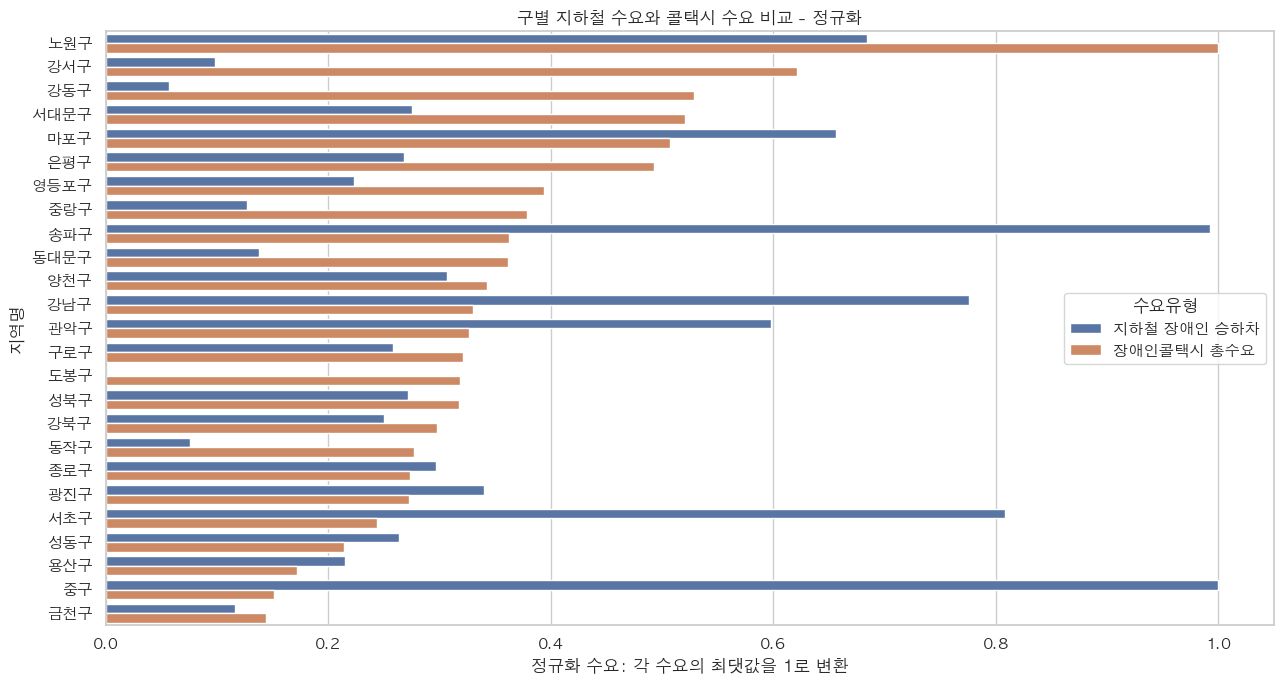

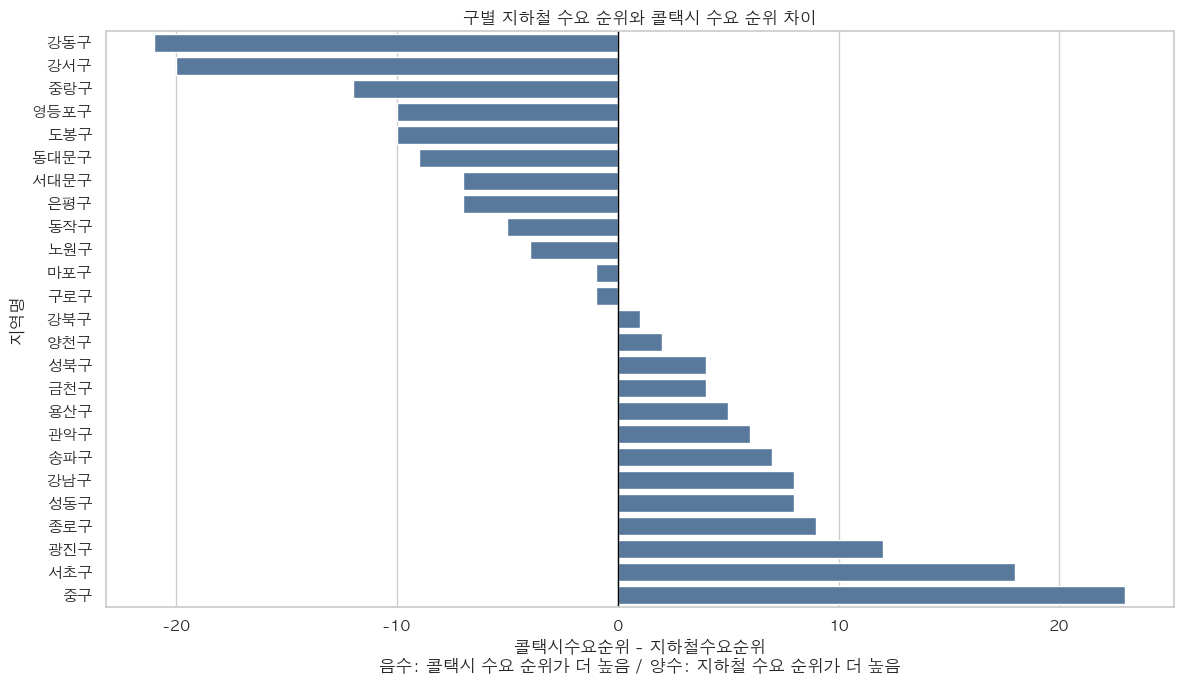

In [40]:
district_compare = subway_district.merge(taxi_district, on='지역명', how='outer')
district_compare = district_compare.merge(
    district_internal[['지역명', '구내이동건수', '구외이동건수', '구내이동비율']],
    on='지역명', how='left'
)

numeric_columns = district_compare.select_dtypes(include='number').columns
for column in numeric_columns:
    district_compare[column] = district_compare[column].fillna(0)

district_compare['지하철수요순위'] = district_compare['지하철_장애인총승하차인원수'].rank(ascending=False, method='min')
district_compare['콜택시수요순위'] = district_compare['콜택시_총수요건수'].rank(ascending=False, method='min')
district_compare['수요순위차이'] = district_compare['콜택시수요순위'] - district_compare['지하철수요순위']
district_compare['콜택시대비지하철수요'] = district_compare['지하철_장애인총승하차인원수'] / district_compare['콜택시_총수요건수'].replace(0, np.nan)
district_compare['지하철수요_정규화'] = district_compare['지하철_장애인총승하차인원수'] / district_compare['지하철_장애인총승하차인원수'].max()
district_compare['콜택시수요_정규화'] = district_compare['콜택시_총수요건수'] / district_compare['콜택시_총수요건수'].max()

# 구별 접근성 부족 정도도 함께 계산한다.
# 환승역은 노선별로 접근성 조건이 달라질 수 있으므로 역-노선 조합 기준으로 집계한다.
# 수요만 보면 사람이 많이 움직이는 곳만 강조되므로, 시설이 부족한 정도를 별도 축으로 추가한다.
district_accessibility = station_demand.groupby('지역명', as_index=False).agg(
    구_역수=('역표시명', 'count'),
    구_평균운행엘리베이터수=('운행엘리베이터수', 'mean'),
    구_엘리베이터부족역수=('운행엘리베이터수', lambda s: int((s <= 1).sum())),
    구_안전발판부족역수=('안전발판수', lambda s: int((s == 0).sum())),
    구_화장실부족역수=('휠체어접근가능화장실수', lambda s: int((s == 0).sum())),
    구_충전기부족역수=('휠체어급속충전기수', lambda s: int((s == 0).sum())),
)
district_accessibility['구_시설부족건수'] = (
    district_accessibility['구_엘리베이터부족역수']
    + district_accessibility['구_안전발판부족역수']
    + district_accessibility['구_화장실부족역수']
    + district_accessibility['구_충전기부족역수']
)
district_accessibility['구_시설점검항목수'] = district_accessibility['구_역수'] * 4
district_accessibility['구_접근성부족비율'] = district_accessibility['구_시설부족건수'] / district_accessibility['구_시설점검항목수'].replace(0, np.nan)

district_compare = district_compare.merge(district_accessibility, on='지역명', how='left')
for column in ['구_역수', '구_평균운행엘리베이터수', '구_엘리베이터부족역수', '구_안전발판부족역수', '구_화장실부족역수', '구_충전기부족역수', '구_시설부족건수', '구_시설점검항목수', '구_접근성부족비율']:
    district_compare[column] = district_compare[column].fillna(0)
district_compare['구내이동비율_정규화'] = district_compare['구내이동비율'] / district_compare['구내이동비율'].max()

district_compare = district_compare.sort_values('콜택시_총수요건수', ascending=False).reset_index(drop=True)

compare_long = district_compare.melt(
    id_vars=['지역명'],
    value_vars=['지하철수요_정규화', '콜택시수요_정규화'],
    var_name='수요유형',
    value_name='정규화수요',
)
compare_long['수요유형'] = compare_long['수요유형'].map({
    '지하철수요_정규화': '지하철 장애인 승하차',
    '콜택시수요_정규화': '장애인콜택시 총수요',
})

plt.figure(figsize=(13, max(7, district_compare['지역명'].nunique() * 0.28)))
sns.barplot(data=compare_long, y='지역명', x='정규화수요', hue='수요유형')
plt.title('구별 지하철 수요와 콜택시 수요 비교 - 정규화')
plt.xlabel('정규화 수요: 각 수요의 최댓값을 1로 변환')
plt.ylabel('지역명')
plt.tight_layout()
plt.show()

rank_plot = district_compare.sort_values('수요순위차이').copy()
plt.figure(figsize=(12, max(7, len(rank_plot) * 0.28)))
sns.barplot(data=rank_plot, y='지역명', x='수요순위차이', color='#4C78A8')
plt.axvline(0, color='black', linewidth=1)
plt.title('구별 지하철 수요 순위와 콜택시 수요 순위 차이')
plt.xlabel('콜택시수요순위 - 지하철수요순위\n음수: 콜택시 수요 순위가 더 높음 / 양수: 지하철 수요 순위가 더 높음')
plt.ylabel('지역명')
plt.tight_layout()
plt.show()


In [41]:
compare_focus = district_compare.sort_values('콜택시_총수요건수', ascending=False).iloc[0]
rank_gap_focus = district_compare.reindex(district_compare['수요순위차이'].abs().sort_values(ascending=False).index).iloc[0]
both_high = district_compare.loc[
    district_compare['지하철수요_정규화'].ge(0.5) & district_compare['콜택시수요_정규화'].ge(0.5),
    '지역명'
].tolist()
show_result(
    '3-1-1 결과: 지역별 지하철 수요와 콜택시 수요 비교',
    [
        f'콜택시 총수요가 가장 큰 구는 {compare_focus["지역명"]}이며, 이 구의 콜택시 정규화 수요는 {compare_focus["콜택시수요_정규화"]:.2f}, 지하철 정규화 수요는 {compare_focus["지하철수요_정규화"]:.2f}이다.',
        f'두 수요의 순위 차이가 가장 크게 나타난 구는 {rank_gap_focus["지역명"]}이며, 수요순위차이는 {rank_gap_focus["수요순위차이"]:.0f}이다. 음수이면 콜택시 쪽 순위가 더 높고, 양수이면 지하철 쪽 순위가 더 높다는 뜻이다.',
        f'정규화 기준 0.5 이상으로 두 수요가 모두 높은 구는 {", ".join(both_high) if both_high else "확인되지 않음"}이다.',
        '정규화는 서로 단위가 다른 지하철 승하차인원과 콜택시 이용건수를 같은 축에서 비교하기 위한 상대값이며, 실제 인원·건수 자체를 바꾼 것은 아니다.',
    ],
    [
        '산점도에서 지하철 수요와 콜택시 수요가 함께 움직이는지 확인한다.',
        '두 수요가 어긋나는 구는 지하철 접근성 보완 후보로 따로 본다.',
    ],
    conclusion='이 그래프는 서울 25개 구에서 지하철 수요와 콜택시 수요가 같은 크기로 나타나는지 비교하기 위한 출발점이다. 두 수요가 모두 높은 구는 복합 이동 수요가 큰 지역으로 볼 수 있고, 한쪽만 높은 구는 교통수단 선택에 다른 제약이 있을 가능성이 있다.',
    significance='네비게이터 관점에서는 특정 구에서 지하철과 콜택시 중 어느 쪽 안내를 더 세심하게 해야 하는지 우선순위를 잡는 데 유의미하다. 다만 구 단위 비교라서 실제 출발동·목적동, 역 위치, 환승 동선까지는 추가로 확인해야 한다.'
)


#### 3-1-1 결과: 지역별 지하철 수요와 콜택시 수요 비교

**결과 해석**

- 콜택시 총수요가 가장 큰 구는 노원구이며, 이 구의 콜택시 정규화 수요는 1.00, 지하철 정규화 수요는 0.68이다.
- 두 수요의 순위 차이가 가장 크게 나타난 구는 중구이며, 수요순위차이는 23이다. 음수이면 콜택시 쪽 순위가 더 높고, 양수이면 지하철 쪽 순위가 더 높다는 뜻이다.
- 정규화 기준 0.5 이상으로 두 수요가 모두 높은 구는 노원구, 마포구이다.
- 정규화는 서로 단위가 다른 지하철 승하차인원과 콜택시 이용건수를 같은 축에서 비교하기 위한 상대값이며, 실제 인원·건수 자체를 바꾼 것은 아니다.

**결론**

- 이 그래프는 서울 25개 구에서 지하철 수요와 콜택시 수요가 같은 크기로 나타나는지 비교하기 위한 출발점이다. 두 수요가 모두 높은 구는 복합 이동 수요가 큰 지역으로 볼 수 있고, 한쪽만 높은 구는 교통수단 선택에 다른 제약이 있을 가능성이 있다.

**유의미성**

- 네비게이터 관점에서는 특정 구에서 지하철과 콜택시 중 어느 쪽 안내를 더 세심하게 해야 하는지 우선순위를 잡는 데 유의미하다. 다만 구 단위 비교라서 실제 출발동·목적동, 역 위치, 환승 동선까지는 추가로 확인해야 한다.

**이 결과를 바탕으로 이어볼 분석**

- 산점도에서 지하철 수요와 콜택시 수요가 함께 움직이는지 확인한다.
- 두 수요가 어긋나는 구는 지하철 접근성 보완 후보로 따로 본다.

### 3-2. 지하철 수요와 콜택시 수요 관계 분석

#### 3-2-1. 지하철 수요와 콜택시 수요 산점도 확인

3-1-1에서는 구별 수요의 크기를 정규화해서 비교했다. 여기서는 한 단계 더 나아가, 콜택시 수요와 지하철 장애인 이용량이 실제로 같은 방향으로 움직이는지 확인한다.

상관계수는 서울 25개 구를 하나씩 점으로 두고 계산했다.

- x축: 구별 콜택시 수요
  - 콜택시 출발건수
  - 콜택시 도착건수
  - 콜택시 총수요건수 = 출발건수 + 도착건수
- y축: 구별 지하철 장애인 총 승하차인원수
- 계산 방식: 각 구의 x값과 y값을 이용해 피어슨 상관계수(Pearson correlation coefficient)를 계산

상관계수 해석 기준은 다음과 같다.

- 1에 가까움: 콜택시 수요가 큰 구일수록 지하철 이용량도 큰 경향이 강함
- 0에 가까움: 두 수요가 함께 움직이는 선형 관계가 약함
- -1에 가까움: 콜택시 수요가 큰 구일수록 지하철 이용량은 낮은 반대 방향 경향이 강함

즉, 이 값은 “두 교통수단의 수요가 같은 지역에서 같이 커지는가?”를 보기 위한 값이다. 단, 상관계수는 원인과 결과를 설명하지 않는다. 예를 들어 상관계수가 낮다고 해서 지하철 접근성이 나쁘다고 바로 결론낼 수는 없고, 역 위치·시설 상태·이동 목적·대기시간 같은 추가 요소를 같이 봐야 한다.


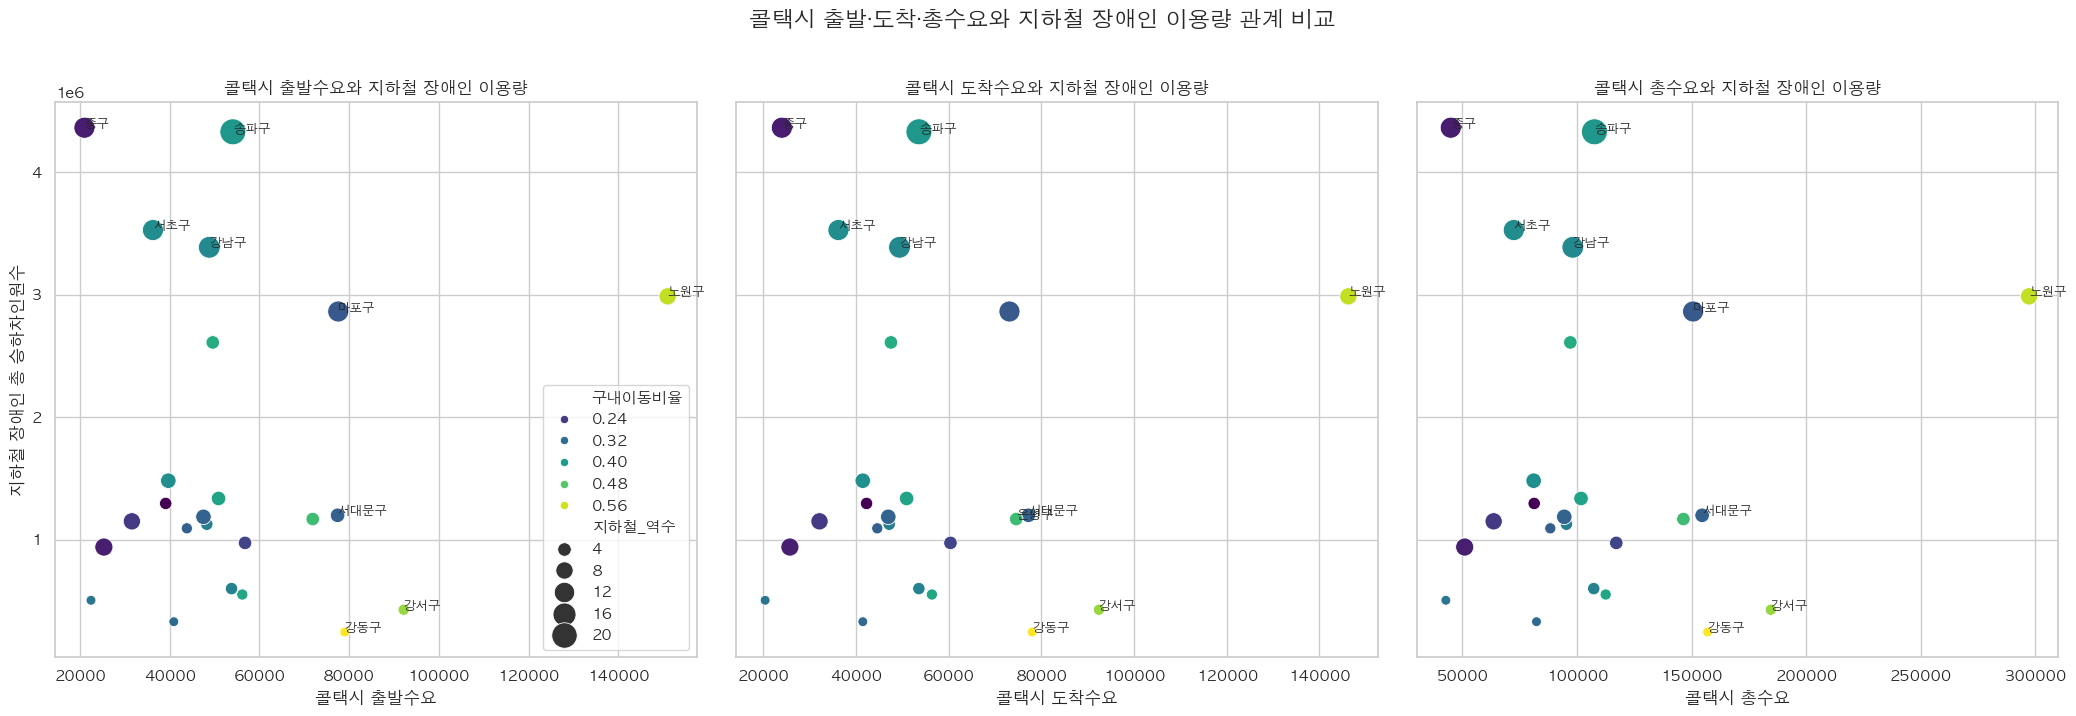

,비교대상,상관계수
0,콜택시 출발수요,0.028186
1,콜택시 도착수요,0.018188
2,콜택시 총수요,0.023291


#### 3-2-1 결과: 지하철 수요와 콜택시 수요 관계

**결과 해석**

- 콜택시 총수요와 지하철 장애인 총 승하차인원의 상관계수는 0.02이다.
- 출발·도착·총수요 중 지하철 수요와의 관계가 상대적으로 가장 크게 나타난 항목은 콜택시 출발수요이며, 상관계수는 0.03이다.
- 정규화 기준 두 수요의 차이가 크게 보이는 구는 중구이다.
- 이 분석은 3-1-1처럼 단순히 정규화 크기를 비교하는 것이 아니라, 콜택시 출발수요·도착수요·총수요가 각각 지하철 수요와 같은 방향으로 움직이는지를 확인한다.

**결론**

- 3-2-1은 3-1-1의 반복이 아니라 관계 검증 단계다. 구별 수요 크기 비교에서 한 단계 더 나아가, 콜택시의 출발·도착·총수요가 지하철 장애인 이용량과 실제로 같은 방향인지 확인했다. 관계가 약하면 두 교통수단은 서로 다른 이동 조건을 설명한다고 보는 편이 안전하다.

**유의미성**

- 네비게이터에서 지하철과 콜택시를 하나의 수요 지표로 합쳐 판단하면 안 된다는 근거가 된다. 출발지 기준 콜택시 수요, 목적지 기준 콜택시 수요, 지하철 시설 정보는 각각 분리해서 추천 로직에 넣는 것이 더 적절하다.

**이 결과를 바탕으로 이어볼 분석**

- 상관관계가 강하지 않다면, 지하철 수요가 높은 지역이 콜택시 수요도 높다고 가정하지 않는다.
- 수요가 어긋나는 구는 접근성 보완 후보로 따로 확인한다.

In [42]:
plot_data = district_compare.loc[
    district_compare['지하철_장애인총승하차인원수'].gt(0) & district_compare['콜택시_총수요건수'].gt(0)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=True)
scatter_specs = [
    ('콜택시_출발건수', '콜택시 출발수요'),
    ('콜택시_도착건수', '콜택시 도착수요'),
    ('콜택시_총수요건수', '콜택시 총수요'),
]
correlation_rows = []
for ax, (x_col, title) in zip(axes, scatter_specs):
    sns.scatterplot(
        data=plot_data,
        x=x_col,
        y='지하철_장애인총승하차인원수',
        size='지하철_역수',
        hue='구내이동비율',
        palette='viridis',
        sizes=(50, 350),
        ax=ax,
        legend=(ax is axes[0]),
    )
    for _, row in plot_data.iterrows():
        if row[x_col] >= plot_data[x_col].quantile(0.80) or row['지하철_장애인총승하차인원수'] >= plot_data['지하철_장애인총승하차인원수'].quantile(0.80):
            ax.text(row[x_col], row['지하철_장애인총승하차인원수'], row['지역명'], fontsize=9)
    corr = plot_data[[x_col, '지하철_장애인총승하차인원수']].corr().iloc[0, 1]
    correlation_rows.append({'비교대상': title, '상관계수': corr})
    ax.set_title(f'{title}와 지하철 장애인 이용량')
    ax.set_xlabel(title)
    ax.set_ylabel('지하철 장애인 총 승하차인원수')
plt.suptitle('콜택시 출발·도착·총수요와 지하철 장애인 이용량 관계 비교', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

correlation_summary = pd.DataFrame(correlation_rows)
display(correlation_summary)

corr_total = correlation_summary.loc[correlation_summary['비교대상'].eq('콜택시 총수요'), '상관계수'].iloc[0]
strongest_corr = correlation_summary.reindex(correlation_summary['상관계수'].abs().sort_values(ascending=False).index).iloc[0]
scatter_focus = plot_data.assign(
    수요차이비율=(plot_data['콜택시수요_정규화'] - plot_data['지하철수요_정규화']).abs()
).sort_values('수요차이비율', ascending=False).iloc[0]
show_result(
    '3-2-1 결과: 지하철 수요와 콜택시 수요 관계',
    [
        f'콜택시 총수요와 지하철 장애인 총 승하차인원의 상관계수는 {corr_total:.2f}이다.',
        f'출발·도착·총수요 중 지하철 수요와의 관계가 상대적으로 가장 크게 나타난 항목은 {strongest_corr["비교대상"]}이며, 상관계수는 {strongest_corr["상관계수"]:.2f}이다.',
        f'정규화 기준 두 수요의 차이가 크게 보이는 구는 {scatter_focus["지역명"]}이다.',
        '이 분석은 3-1-1처럼 단순히 정규화 크기를 비교하는 것이 아니라, 콜택시 출발수요·도착수요·총수요가 각각 지하철 수요와 같은 방향으로 움직이는지를 확인한다.',
    ],
    [
        '상관관계가 강하지 않다면, 지하철 수요가 높은 지역이 콜택시 수요도 높다고 가정하지 않는다.',
        '수요가 어긋나는 구는 접근성 보완 후보로 따로 확인한다.',
    ],
    conclusion='3-2-1은 3-1-1의 반복이 아니라 관계 검증 단계다. 구별 수요 크기 비교에서 한 단계 더 나아가, 콜택시의 출발·도착·총수요가 지하철 장애인 이용량과 실제로 같은 방향인지 확인했다. 관계가 약하면 두 교통수단은 서로 다른 이동 조건을 설명한다고 보는 편이 안전하다.',
    significance='네비게이터에서 지하철과 콜택시를 하나의 수요 지표로 합쳐 판단하면 안 된다는 근거가 된다. 출발지 기준 콜택시 수요, 목적지 기준 콜택시 수요, 지하철 시설 정보는 각각 분리해서 추천 로직에 넣는 것이 더 적절하다.'
)


### 3-3. 수요와 접근성 부족 조건 결합 분석

#### 3-3-1. 수요와 접근성 부족 지표 함께 보기

구별로 다음 원자료 기반 지표를 나란히 비교한다.

- 콜택시 총수요건수
- 지하철 장애인 총 승하차인원수
- 구 내 이동 비율
- 접근성 부족 비율

여기서 `접근성 부족 비율`은 해당 구의 분석 대상 역 중 시설 부족 조건에 해당하는 비율을 단순 계산한 값이다. 가중치를 주지 않고 현재 데이터에서 관찰되는 부족 현황을 보여주는 보조 지표로만 사용한다.

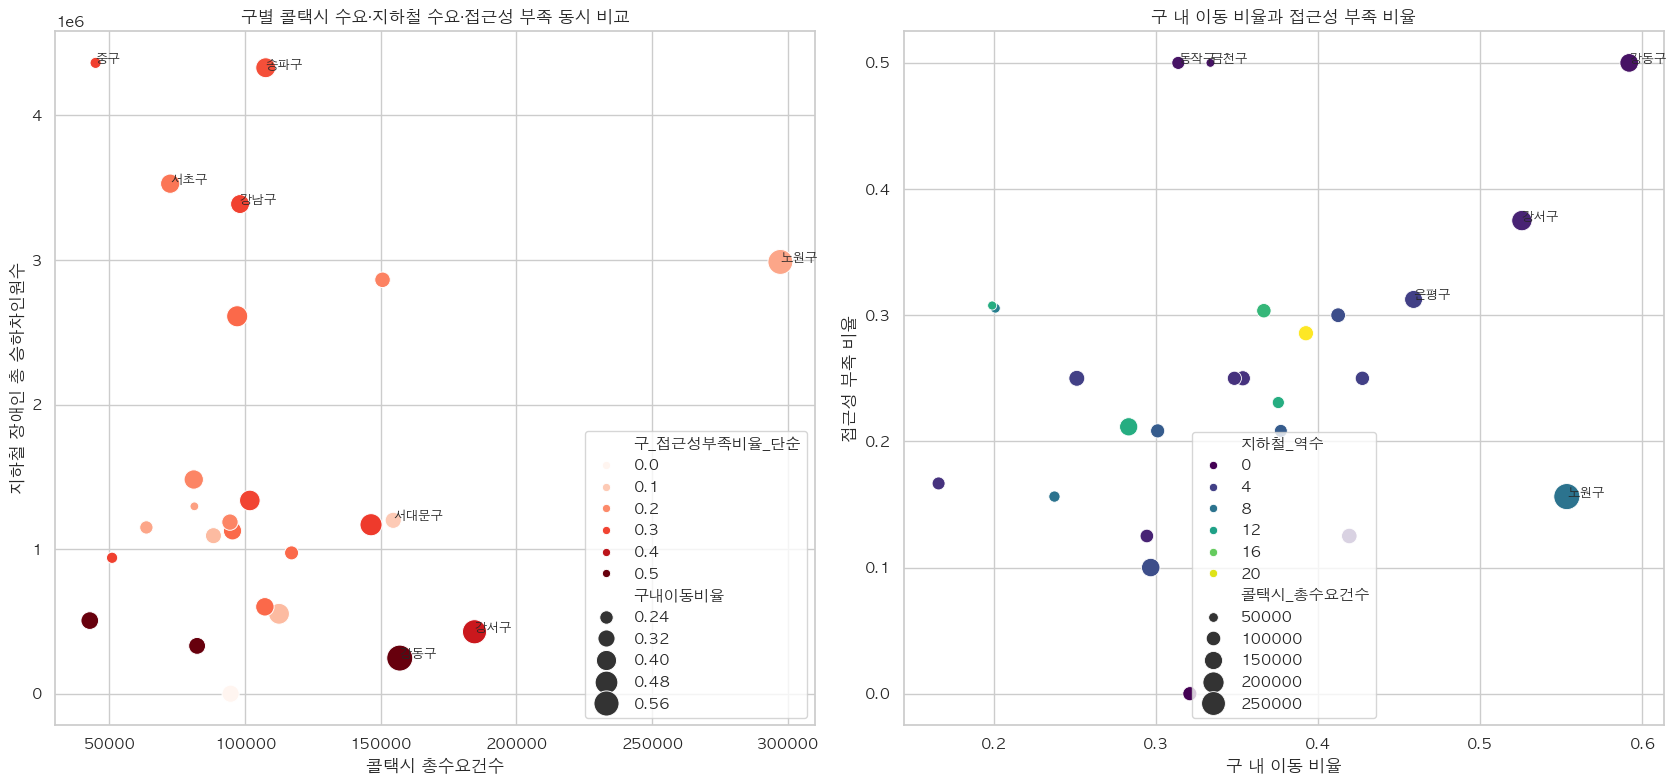

#### 3-3-1 결과: 수요와 접근성 부족 조건 결합

**결과 해석**

- 접근성 부족 비율이 가장 높은 구는 금천구이며, 부족 비율은 0.50이다.
- 구 내 이동 비율이 가장 높은 구는 강동구이며, 구 내 이동 비율은 0.59이다.
- 콜택시 수요 상위 25%이면서 접근성 부족 비율도 상위 25%인 구는 3개다.
- 접근성 부족 비율은 엘리베이터·안전발판·화장실·충전기 부족 조건을 역 수 대비 단순 계산한 값이며, 시설별 가중치는 넣지 않았다.

**결론**

- 수요와 접근성 부족 조건을 함께 보면, 단순히 이용자가 많은 지역과 실제 시설 점검이 필요한 지역을 구분할 수 있다. 특히 콜택시 수요와 접근성 부족이 동시에 높은 지역은 네비게이터에서 지하철 대안을 제시할 때 더 많은 주의 정보가 필요할 수 있다.

**유의미성**

- 임의 점수가 아니라 원자료 기반 조건을 나란히 비교하므로, “어떤 구를 먼저 세부 점검할지” 결정하는 데 유의미하다. 다만 구 평균 지표이므로 역별 시설 위치나 운행 상태를 반드시 이어서 확인해야 한다.

**이 결과를 바탕으로 이어볼 분석**

- 구 단위에서 후보가 확인되면 역 단위 접근성 시설 현황으로 내려가 실제 부족 시설을 확인한다.
- 구 내 이동 비율이 높은 지역은 단거리 이동에서 지하철 접근성이 불편한지 별도로 검토한다.

In [43]:
# 임의 가중치를 만들지 않고, 원자료 기반 지표들을 함께 비교한다.
# 접근성 부족 비율은 시설 부족 역 수를 전체 역 수로 나눈 관찰 지표다.
district_compare['구_접근성부족비율_단순'] = district_compare['구_접근성부족비율']

district_need_view = district_compare.sort_values('콜택시_총수요건수', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
sns.scatterplot(
    data=district_need_view,
    x='콜택시_총수요건수',
    y='지하철_장애인총승하차인원수',
    hue='구_접근성부족비율_단순',
    size='구내이동비율',
    palette='Reds',
    sizes=(40, 350),
    ax=axes[0],
)
for _, row in district_need_view.iterrows():
    if row['콜택시_총수요건수'] >= district_need_view['콜택시_총수요건수'].quantile(0.85) or row['지하철_장애인총승하차인원수'] >= district_need_view['지하철_장애인총승하차인원수'].quantile(0.85):
        axes[0].text(row['콜택시_총수요건수'], row['지하철_장애인총승하차인원수'], row['지역명'], fontsize=9)
axes[0].set_title('구별 콜택시 수요·지하철 수요·접근성 부족 동시 비교')
axes[0].set_xlabel('콜택시 총수요건수')
axes[0].set_ylabel('지하철 장애인 총 승하차인원수')

sns.scatterplot(
    data=district_need_view,
    x='구내이동비율',
    y='구_접근성부족비율_단순',
    size='콜택시_총수요건수',
    hue='지하철_역수',
    palette='viridis',
    sizes=(40, 350),
    ax=axes[1],
)
for _, row in district_need_view.iterrows():
    if row['구내이동비율'] >= district_need_view['구내이동비율'].quantile(0.85) or row['구_접근성부족비율_단순'] >= district_need_view['구_접근성부족비율_단순'].quantile(0.85):
        axes[1].text(row['구내이동비율'], row['구_접근성부족비율_단순'], row['지역명'], fontsize=9)
axes[1].set_title('구 내 이동 비율과 접근성 부족 비율')
axes[1].set_xlabel('구 내 이동 비율')
axes[1].set_ylabel('접근성 부족 비율')
plt.tight_layout()
plt.show()

access_focus = district_need_view.sort_values('구_접근성부족비율_단순', ascending=False).iloc[0]
internal_focus = district_need_view.sort_values('구내이동비율', ascending=False).iloc[0]
combined_focus = district_need_view.assign(
    콜택시상위여부=district_need_view['콜택시_총수요건수'].ge(district_need_view['콜택시_총수요건수'].quantile(0.75)),
    접근성부족상위여부=district_need_view['구_접근성부족비율_단순'].ge(district_need_view['구_접근성부족비율_단순'].quantile(0.75)),
)
combined_count = int((combined_focus['콜택시상위여부'] & combined_focus['접근성부족상위여부']).sum())
show_result(
    '3-3-1 결과: 수요와 접근성 부족 조건 결합',
    [
        f'접근성 부족 비율이 가장 높은 구는 {access_focus["지역명"]}이며, 부족 비율은 {access_focus["구_접근성부족비율_단순"]:.2f}이다.',
        f'구 내 이동 비율이 가장 높은 구는 {internal_focus["지역명"]}이며, 구 내 이동 비율은 {internal_focus["구내이동비율"]:.2f}이다.',
        f'콜택시 수요 상위 25%이면서 접근성 부족 비율도 상위 25%인 구는 {combined_count}개다.',
        '접근성 부족 비율은 엘리베이터·안전발판·화장실·충전기 부족 조건을 역 수 대비 단순 계산한 값이며, 시설별 가중치는 넣지 않았다.',
    ],
    [
        '구 단위에서 후보가 확인되면 역 단위 접근성 시설 현황으로 내려가 실제 부족 시설을 확인한다.',
        '구 내 이동 비율이 높은 지역은 단거리 이동에서 지하철 접근성이 불편한지 별도로 검토한다.',
    ],
    conclusion='수요와 접근성 부족 조건을 함께 보면, 단순히 이용자가 많은 지역과 실제 시설 점검이 필요한 지역을 구분할 수 있다. 특히 콜택시 수요와 접근성 부족이 동시에 높은 지역은 네비게이터에서 지하철 대안을 제시할 때 더 많은 주의 정보가 필요할 수 있다.',
    significance='임의 점수가 아니라 원자료 기반 조건을 나란히 비교하므로, “어떤 구를 먼저 세부 점검할지” 결정하는 데 유의미하다. 다만 구 평균 지표이므로 역별 시설 위치나 운행 상태를 반드시 이어서 확인해야 한다.'
)


## 4. 지하철 접근성 시설 충분성 분석

### 4-1. 지하철 접근성 시설 전체 현황 분석

#### 4-1-1. 접근성 시설 현황 요약

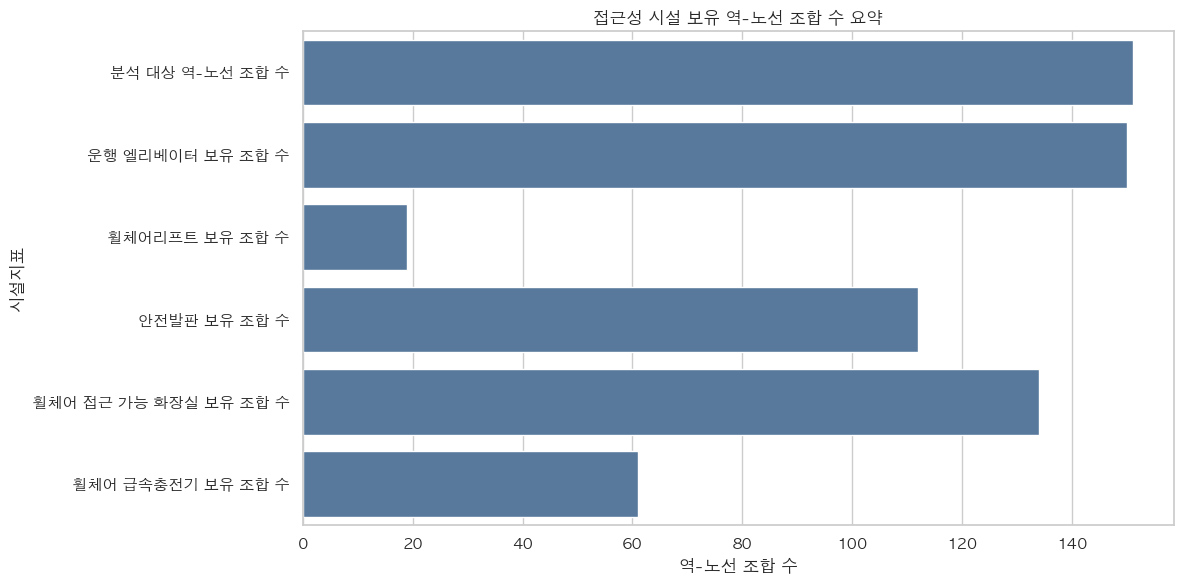

#### 4-1-1 결과: 접근성 시설 현황 요약

**결과 해석**

- 분석 대상 역-노선 조합은 총 151개다.
- 가장 넓게 보유된 시설은 운행 엘리베이터 보유 조합 수이며, 150개 역-노선 조합에서 확인된다.
- 가장 적게 보유된 시설은 휠체어리프트 보유 조합 수이며, 19개 역-노선 조합에서 확인된다.
- 이 그래프는 시설의 존재 여부를 역-노선 조합 기준으로 요약한 것이며, 시설의 실제 위치·연결층·운행 가능 상태까지 설명하지는 않는다.

**결론**

- 전체적으로 어떤 접근성 시설이 넓게 확보되어 있고 어떤 시설이 상대적으로 부족한지 확인할 수 있다. 같은 역명이라도 호선별 접근 조건이 다를 수 있으므로 역-노선 조합 기준으로 보는 것이 더 적절하다.

**유의미성**

- 시설 종류별 데이터 커버리지를 확인하는 단계라서 이후 역별 분석의 신뢰 범위를 판단하는 데 유의미하다. 다만 시설 수 요약만으로 실제 접근 편의성을 판단할 수는 없다.

**이 결과를 바탕으로 이어볼 분석**

- 시설이 부족한 역-노선 조합이 어디인지 확인한다.
- 시설 보유 여부뿐 아니라 이용량이 많은 조합에서 부족 조건이 나타나는지 함께 본다.

In [44]:
facility_summary = pd.Series({
    '분석 대상 역-노선 조합 수': len(station_demand),
    '운행 엘리베이터 보유 조합 수': int(station_demand['운행엘리베이터수'].gt(0).sum()),
    '휠체어리프트 보유 조합 수': int(station_demand['휠체어리프트수'].gt(0).sum()),
    '안전발판 보유 조합 수': int(station_demand['안전발판수'].gt(0).sum()),
    '휠체어 접근 가능 화장실 보유 조합 수': int(station_demand['휠체어접근가능화장실수'].gt(0).sum()),
    '휠체어 급속충전기 보유 조합 수': int(station_demand['휠체어급속충전기수'].gt(0).sum()),
})
facility_summary_df = facility_summary.reset_index()
facility_summary_df.columns = ['시설지표', '역수']

plt.figure(figsize=(12, 6))
sns.barplot(data=facility_summary_df, y='시설지표', x='역수', color='#4C78A8')
plt.title('접근성 시설 보유 역-노선 조합 수 요약')
plt.xlabel('역-노선 조합 수')
plt.ylabel('시설지표')
plt.tight_layout()
plt.show()

facility_total = int(facility_summary['분석 대상 역-노선 조합 수'])
facility_lowest = facility_summary_df.loc[facility_summary_df['시설지표'].ne('분석 대상 역-노선 조합 수')].sort_values('역수').iloc[0]
facility_highest = facility_summary_df.loc[facility_summary_df['시설지표'].ne('분석 대상 역-노선 조합 수')].sort_values('역수', ascending=False).iloc[0]
show_result(
    '4-1-1 결과: 접근성 시설 현황 요약',
    [
        f'분석 대상 역-노선 조합은 총 {facility_total:,}개다.',
        f'가장 넓게 보유된 시설은 {facility_highest["시설지표"]}이며, {facility_highest["역수"]:,.0f}개 역-노선 조합에서 확인된다.',
        f'가장 적게 보유된 시설은 {facility_lowest["시설지표"]}이며, {facility_lowest["역수"]:,.0f}개 역-노선 조합에서 확인된다.',
        '이 그래프는 시설의 존재 여부를 역-노선 조합 기준으로 요약한 것이며, 시설의 실제 위치·연결층·운행 가능 상태까지 설명하지는 않는다.',
    ],
    [
        '시설이 부족한 역-노선 조합이 어디인지 확인한다.',
        '시설 보유 여부뿐 아니라 이용량이 많은 조합에서 부족 조건이 나타나는지 함께 본다.',
    ],
    conclusion='전체적으로 어떤 접근성 시설이 넓게 확보되어 있고 어떤 시설이 상대적으로 부족한지 확인할 수 있다. 같은 역명이라도 호선별 접근 조건이 다를 수 있으므로 역-노선 조합 기준으로 보는 것이 더 적절하다.',
    significance='시설 종류별 데이터 커버리지를 확인하는 단계라서 이후 역별 분석의 신뢰 범위를 판단하는 데 유의미하다. 다만 시설 수 요약만으로 실제 접근 편의성을 판단할 수는 없다.'
)


### 4-2. 역별 접근성 부족 조건 분석

#### 4-2-1. 이용량과 접근성 부족 조건 함께 보기

역별 장애인 이용량과 실제 시설 부족 조건을 함께 본다.

부족 조건은 다음처럼 단순하게 표시한다.

- 운행 엘리베이터가 1개 이하인지
- 안전발판이 없는지
- 휠체어 접근 가능 화장실이 없는지
- 휠체어 급속충전기가 없는지

산점도에서 오른쪽에 있으면서 색이 진한 역은 장애인 이용량이 많고 부족 조건 개수도 많은 역이다. 이런 역은 추가 확인이 필요한 후보로 볼 수 있다.

,구분,노선명,역명,지역명,장애인총승하차인원수,부족조건개수,엘리베이터부족여부,안전발판부족여부,화장실부족여부,충전기부족여부
0,부족조건 상위 5개,7호선,군자(능동),광진구,285948,3,1,1,1,0
1,부족조건 상위 5개,5호선,을지로4가,중구,120988,3,1,1,0,1
2,부족조건 상위 5개,3호선,도곡,강남구,61014,3,1,0,1,1
3,부족조건 상위 5개,6호선,삼각지(전쟁기념관)(전쟁기념관),용산구,55059,3,0,1,1,1
4,부족조건 상위 5개,6호선,삼각지(전쟁기념관),용산구,16455,3,0,1,1,1
5,부족조건 하위 5개,4호선,삼각지(전쟁기념관),용산구,21176,0,0,0,0,0
6,부족조건 하위 5개,4호선,삼각지(전쟁기념관)(전쟁기념관),용산구,71025,0,0,0,0,0
7,부족조건 하위 5개,5호선,충정로(경기대입구),서대문구,71466,0,0,0,0,0
8,부족조건 하위 5개,3호선,잠원,서초구,81109,0,0,0,0,0
9,부족조건 하위 5개,2호선,한양대,성동구,83680,0,0,0,0,0


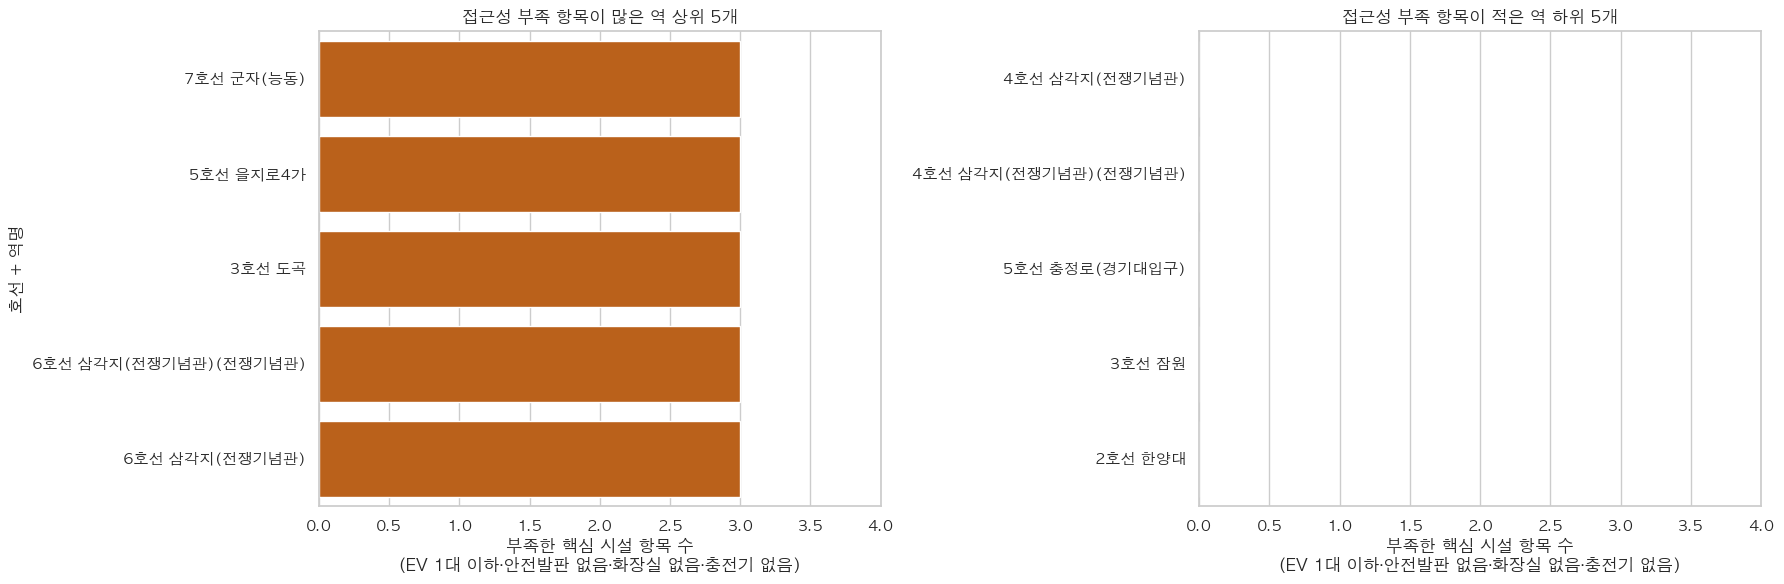

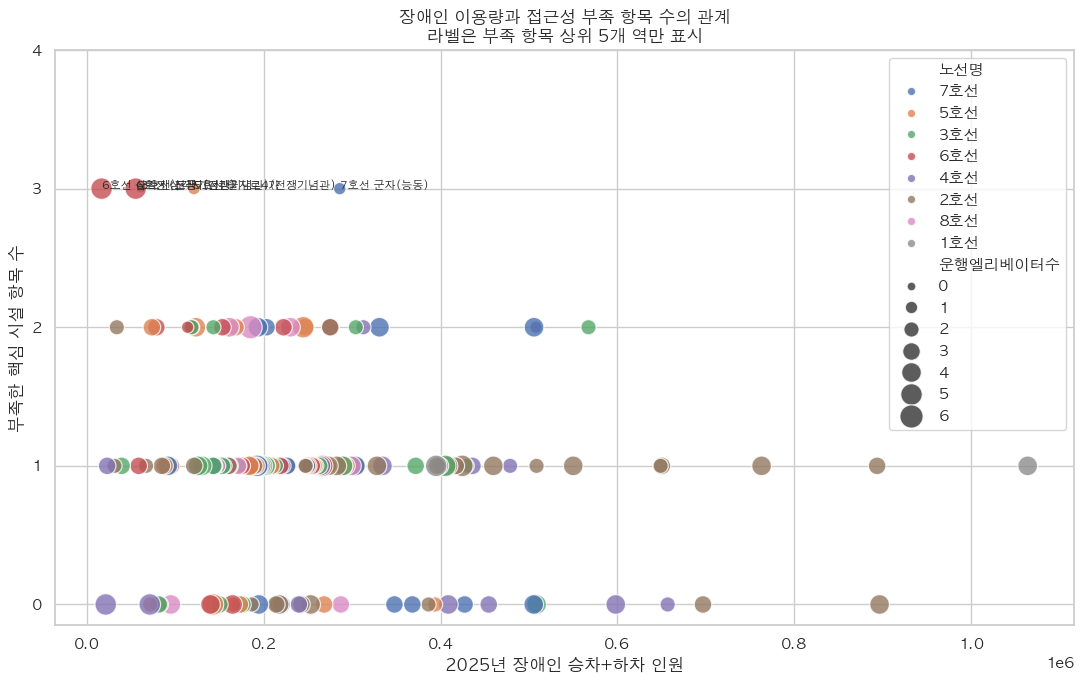

장애인 이용량과 부족조건개수의 상관계수: -0.178
해석: 양수이면 이용량이 많은 역일수록 부족 조건도 같이 많아지는 경향, 음수이면 이용량이 많은 역일수록 부족 조건은 적은 경향이다.


In [45]:
risk = station_demand.copy()
risk['엘리베이터부족여부'] = risk['운행엘리베이터수'].le(1).astype('int64')
risk['안전발판부족여부'] = risk['안전발판수'].eq(0).astype('int64')
risk['화장실부족여부'] = risk['휠체어접근가능화장실수'].eq(0).astype('int64')
risk['충전기부족여부'] = risk['휠체어급속충전기수'].eq(0).astype('int64')
risk['부족조건개수'] = risk[['엘리베이터부족여부', '안전발판부족여부', '화장실부족여부', '충전기부족여부']].sum(axis=1)
risk = risk.sort_values(['부족조건개수', '장애인총승하차인원수'], ascending=[False, False]).reset_index(drop=True)
risk['역표시명'] = risk['노선명'] + ' ' + risk['역명']

risk_top5 = risk.head(5).copy()
risk_bottom5 = risk.sort_values(['부족조건개수', '장애인총승하차인원수'], ascending=[True, True]).head(5).copy()
risk_top_bottom = pd.concat([
    risk_top5.assign(구분='부족조건 상위 5개'),
    risk_bottom5.assign(구분='부족조건 하위 5개'),
], ignore_index=True)

display(risk_top_bottom[[
    '구분', '노선명', '역명', '지역명', '장애인총승하차인원수', '부족조건개수',
    '엘리베이터부족여부', '안전발판부족여부', '화장실부족여부', '충전기부족여부'
]])

risk_top_plot = risk_top_bottom[risk_top_bottom['구분'].eq('부족조건 상위 5개')].sort_values('부족조건개수', ascending=True)
risk_bottom_plot = risk_top_bottom[risk_top_bottom['구분'].eq('부족조건 하위 5개')].sort_values('부족조건개수', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
sns.barplot(data=risk_top_plot, y='역표시명', x='부족조건개수', color='#D55E00', ax=axes[0])
axes[0].set_title('접근성 부족 항목이 많은 역 상위 5개')
axes[0].set_xlabel('부족한 핵심 시설 항목 수\n(EV 1대 이하·안전발판 없음·화장실 없음·충전기 없음)')
axes[0].set_ylabel('호선 + 역명')
axes[0].set_xlim(0, 4)

sns.barplot(data=risk_bottom_plot, y='역표시명', x='부족조건개수', color='#009E73', ax=axes[1])
axes[1].set_title('접근성 부족 항목이 적은 역 하위 5개')
axes[1].set_xlabel('부족한 핵심 시설 항목 수\n(EV 1대 이하·안전발판 없음·화장실 없음·충전기 없음)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))
ax = sns.scatterplot(data=risk, x='장애인총승하차인원수', y='부족조건개수', hue='노선명', size='운행엘리베이터수', sizes=(40, 280), alpha=0.8)
for _, row in risk_top5.iterrows():
    ax.text(row['장애인총승하차인원수'], row['부족조건개수'], row['역표시명'], fontsize=8)
ax.set_title('장애인 이용량과 접근성 부족 항목 수의 관계\n라벨은 부족 항목 상위 5개 역만 표시')
ax.set_xlabel('2025년 장애인 승차+하차 인원')
ax.set_ylabel('부족한 핵심 시설 항목 수')
ax.set_yticks([0, 1, 2, 3, 4])
plt.tight_layout()
plt.show()

risk_corr = risk[['장애인총승하차인원수', '부족조건개수']].corr(numeric_only=True).loc['장애인총승하차인원수', '부족조건개수']
print(f'장애인 이용량과 부족조건개수의 상관계수: {risk_corr:.3f}')
print('해석: 양수이면 이용량이 많은 역일수록 부족 조건도 같이 많아지는 경향, 음수이면 이용량이 많은 역일수록 부족 조건은 적은 경향이다.')


In [46]:
risk_focus = risk.sort_values(['부족조건개수', '장애인총승하차인원수'], ascending=[False, False]).iloc[0]
risk_low_focus = risk.sort_values(['부족조건개수', '장애인총승하차인원수'], ascending=[True, True]).iloc[0]
show_result(
    '4-2-1 결과: 이용량과 접근성 부족 조건',
    [
        f'부족 조건이 많으면서 이용량도 큰 조합으로는 {risk_focus["역명"]}({risk_focus["노선명"]}, {risk_focus["지역명"]})이 먼저 확인된다.',
        f'부족 조건이 가장 적은 하위 예시는 {risk_low_focus["역명"]}({risk_low_focus["노선명"]})이다.',
        '부족조건개수는 엘리베이터·안전발판·장애인화장실·휠체어충전기 부족 여부를 단순 개수로 센 값이며 임의 가중치는 없다.',
        '전체 역을 다 나열하지 않고 부족조건 상위 5개·하위 5개 조합만 표로 보여준다.',
    ],
    [
        '부족 조건이 많은 조합을 실제 시설 위치 정보와 함께 검토한다.',
        '이용량은 높지만 시설 부족이 낮은 조합은 비교 기준으로 둔다.',
    ],
    conclusion='접근성 부족 조건을 역-노선 조합별 이용량과 함께 보면, 같은 역명 안에서도 호선별 점검 필요성이 다르게 보일 수 있다. 이용량이 낮은 조합의 시설 부족과 이용량이 높은 조합의 시설 부족은 실제 이용자에게 주는 영향이 다를 수 있다.',
    significance='이용량과 부족 조건을 함께 보므로 시설 부족의 이용자 영향 가능성을 탐색하는 데 유의미하다. 다만 부족 조건의 개수는 단순 집계이며 시설별 중요도 차이를 반영하지 않는다.'
)


#### 4-2-1 결과: 이용량과 접근성 부족 조건

**결과 해석**

- 부족 조건이 많으면서 이용량도 큰 조합으로는 군자(능동)(7호선, 광진구)이 먼저 확인된다.
- 부족 조건이 가장 적은 하위 예시는 삼각지(전쟁기념관)(4호선)이다.
- 부족조건개수는 엘리베이터·안전발판·장애인화장실·휠체어충전기 부족 여부를 단순 개수로 센 값이며 임의 가중치는 없다.
- 전체 역을 다 나열하지 않고 부족조건 상위 5개·하위 5개 조합만 표로 보여준다.

**결론**

- 접근성 부족 조건을 역-노선 조합별 이용량과 함께 보면, 같은 역명 안에서도 호선별 점검 필요성이 다르게 보일 수 있다. 이용량이 낮은 조합의 시설 부족과 이용량이 높은 조합의 시설 부족은 실제 이용자에게 주는 영향이 다를 수 있다.

**유의미성**

- 이용량과 부족 조건을 함께 보므로 시설 부족의 이용자 영향 가능성을 탐색하는 데 유의미하다. 다만 부족 조건의 개수는 단순 집계이며 시설별 중요도 차이를 반영하지 않는다.

**이 결과를 바탕으로 이어볼 분석**

- 부족 조건이 많은 조합을 실제 시설 위치 정보와 함께 검토한다.
- 이용량은 높지만 시설 부족이 낮은 조합은 비교 기준으로 둔다.

### 4-3. 역별 접근성 시설 보유 현황 분석

#### 4-3-1. 이용량과 접근성 시설 현황 함께 보기

역별 장애인 이용량과 실제 시설 개수/보유 여부를 함께 본다.

여기서는 다음을 확인한다.

- 장애인 이용량이 많은 역에 운행 엘리베이터가 충분히 있는가?
- 안전발판, 휠체어 접근 가능 화장실, 휠체어 급속충전기가 어느 역에 함께 있는가?
- 시설이 좋은 역을 임의 점수로 확정하지 않고, 실제 시설 조합을 그대로 비교한다.

,구분,노선명,역명,지역명,장애인총승하차인원수,핵심시설보유개수,운행엘리베이터수,안전발판수,휠체어접근가능화장실수,휠체어급속충전기수
0,핵심시설 보유 상위 5개,2호선,신도림,구로구,896846,4,4,1,2,1
1,핵심시설 보유 상위 5개,2호선,선릉,강남구,696988,4,3,1,1,1
2,핵심시설 보유 상위 5개,4호선,미아사거리,강북구,657037,4,2,1,1,1
3,핵심시설 보유 상위 5개,4호선,혜화,종로구,598285,4,4,1,1,1
4,핵심시설 보유 상위 5개,3호선,수서,강남구,508708,4,4,1,1,1
5,핵심시설 보유 하위 5개,6호선,삼각지(전쟁기념관),용산구,16455,1,5,0,0,0
6,핵심시설 보유 하위 5개,6호선,삼각지(전쟁기념관)(전쟁기념관),용산구,55059,1,5,0,0,0
7,핵심시설 보유 하위 5개,3호선,도곡,강남구,61014,1,0,1,0,0
8,핵심시설 보유 하위 5개,2호선,도림천,구로구,33742,2,2,1,0,0
9,핵심시설 보유 하위 5개,5호선,오금,송파구,73379,2,3,0,1,0


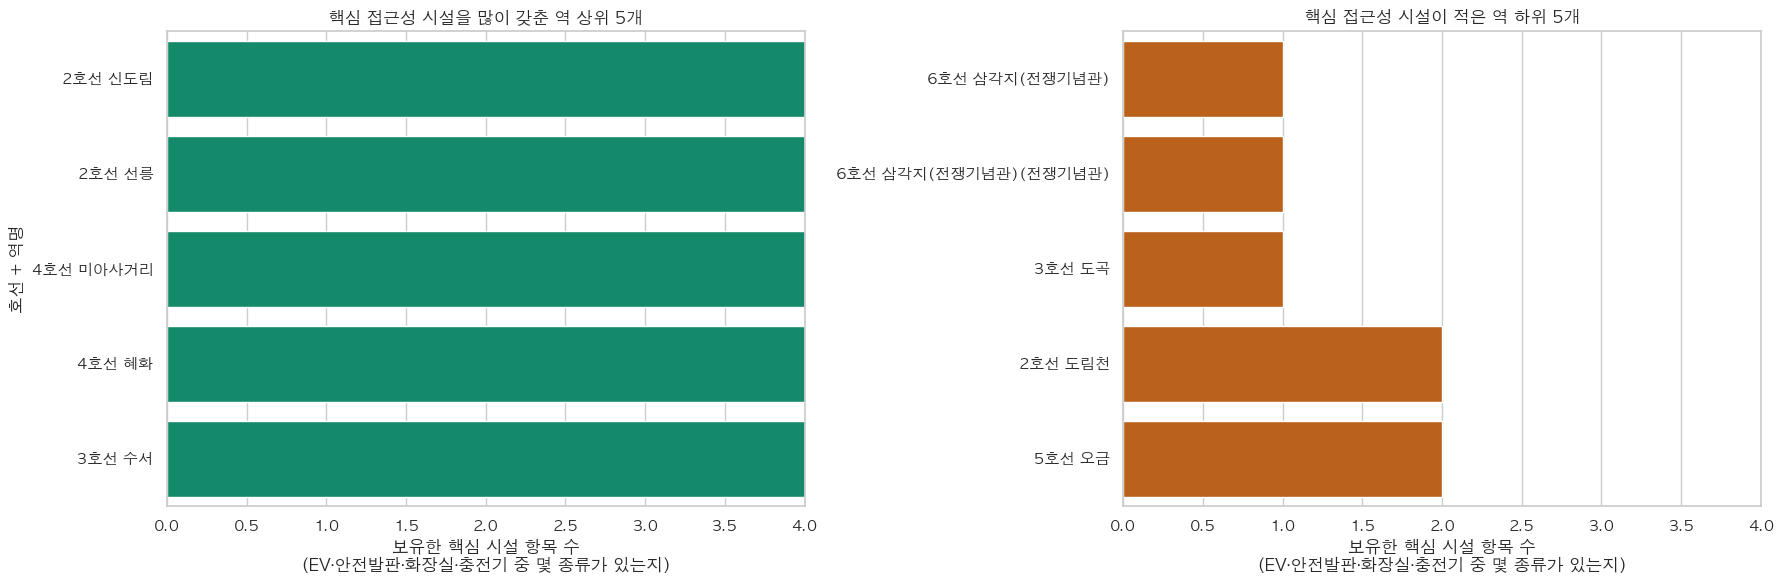

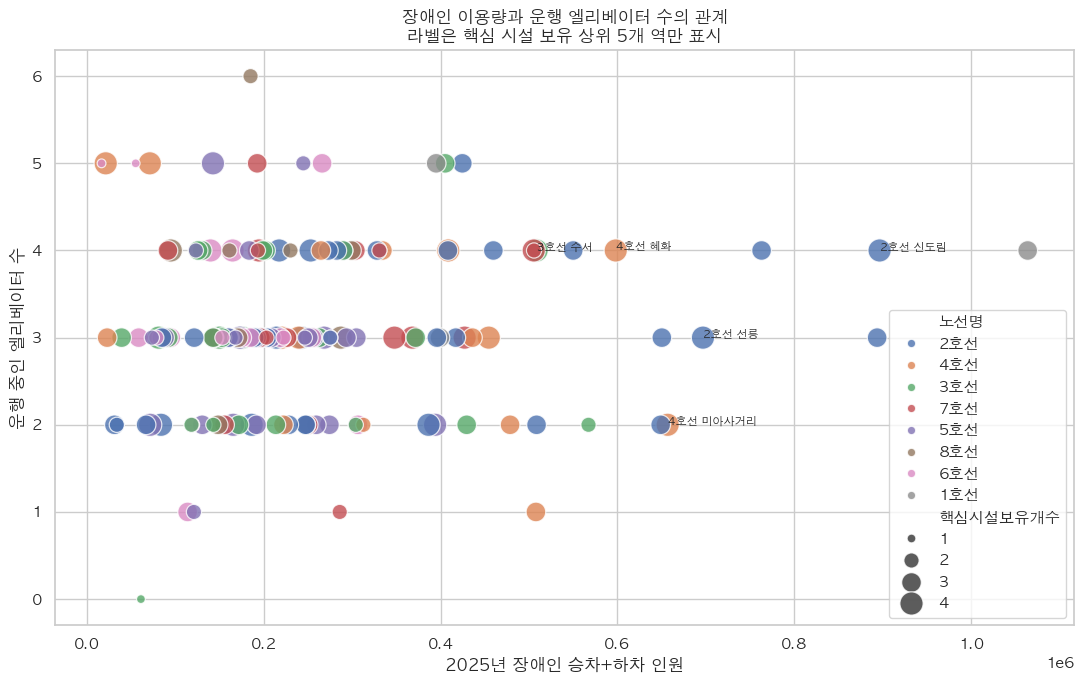

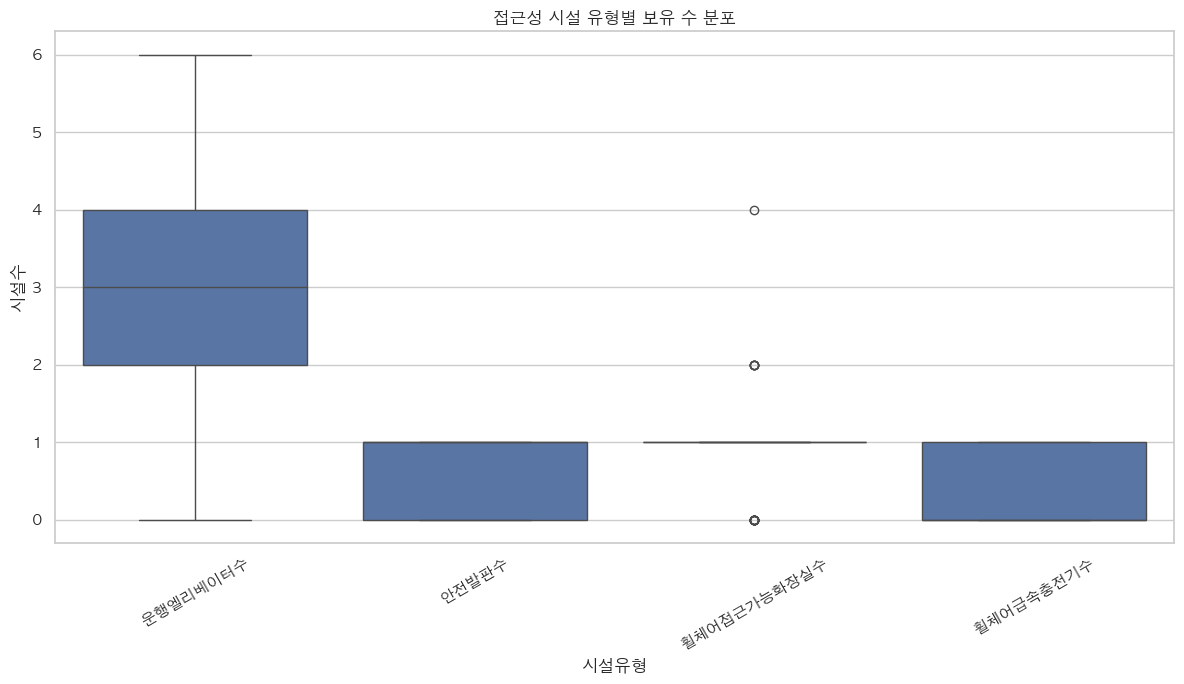

In [47]:
good = station_demand.copy()
good['핵심시설보유개수'] = good[[
    '운행엘리베이터수', '안전발판수', '휠체어접근가능화장실수', '휠체어급속충전기수'
]].gt(0).sum(axis=1)
good = good.sort_values(['핵심시설보유개수', '장애인총승하차인원수'], ascending=[False, False]).reset_index(drop=True)
good['역표시명'] = good['노선명'] + ' ' + good['역명']

good_top5 = good.head(5).copy()
good_bottom5 = good.sort_values(['핵심시설보유개수', '장애인총승하차인원수'], ascending=[True, True]).head(5).copy()
good_top_bottom = pd.concat([
    good_top5.assign(구분='핵심시설 보유 상위 5개'),
    good_bottom5.assign(구분='핵심시설 보유 하위 5개'),
], ignore_index=True)

display(good_top_bottom[[
    '구분', '노선명', '역명', '지역명', '장애인총승하차인원수', '핵심시설보유개수',
    '운행엘리베이터수', '안전발판수', '휠체어접근가능화장실수', '휠체어급속충전기수'
]])

good_top_plot = good_top_bottom[good_top_bottom['구분'].eq('핵심시설 보유 상위 5개')].sort_values('핵심시설보유개수', ascending=True)
good_bottom_plot = good_top_bottom[good_top_bottom['구분'].eq('핵심시설 보유 하위 5개')].sort_values('핵심시설보유개수', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
sns.barplot(data=good_top_plot, y='역표시명', x='핵심시설보유개수', color='#009E73', ax=axes[0])
axes[0].set_title('핵심 접근성 시설을 많이 갖춘 역 상위 5개')
axes[0].set_xlabel('보유한 핵심 시설 항목 수\n(EV·안전발판·화장실·충전기 중 몇 종류가 있는지)')
axes[0].set_ylabel('호선 + 역명')
axes[0].set_xlim(0, 4)

sns.barplot(data=good_bottom_plot, y='역표시명', x='핵심시설보유개수', color='#D55E00', ax=axes[1])
axes[1].set_title('핵심 접근성 시설이 적은 역 하위 5개')
axes[1].set_xlabel('보유한 핵심 시설 항목 수\n(EV·안전발판·화장실·충전기 중 몇 종류가 있는지)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))
ax = sns.scatterplot(data=good, x='장애인총승하차인원수', y='운행엘리베이터수', hue='노선명', size='핵심시설보유개수', sizes=(40, 280), alpha=0.8)
for _, row in good_top5.iterrows():
    ax.text(row['장애인총승하차인원수'], row['운행엘리베이터수'], row['역표시명'], fontsize=8)
ax.set_title('장애인 이용량과 운행 엘리베이터 수의 관계\n라벨은 핵심 시설 보유 상위 5개 역만 표시')
ax.set_xlabel('2025년 장애인 승차+하차 인원')
ax.set_ylabel('운행 중인 엘리베이터 수')
plt.tight_layout()
plt.show()

facility_long = good.melt(
    id_vars=['역표시명', '노선명', '장애인총승하차인원수'],
    value_vars=['운행엘리베이터수', '안전발판수', '휠체어접근가능화장실수', '휠체어급속충전기수'],
    var_name='시설유형',
    value_name='시설수',
)
plt.figure(figsize=(12, 7))
sns.boxplot(data=facility_long, x='시설유형', y='시설수')
plt.title('접근성 시설 유형별 보유 수 분포')
plt.xlabel('시설유형')
plt.ylabel('시설수')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [48]:
good_focus = good.sort_values(['핵심시설보유개수', '장애인총승하차인원수'], ascending=[False, False]).iloc[0]
good_low_focus = good.sort_values(['핵심시설보유개수', '장애인총승하차인원수'], ascending=[True, True]).iloc[0]
show_result(
    '4-3-1 결과: 이용량과 접근성 시설 현황',
    [
        f'핵심시설 보유가 많고 이용량도 큰 조합으로는 {good_focus["역명"]}({good_focus["노선명"]}, {good_focus["지역명"]})이 확인된다.',
        f'핵심시설 보유가 적은 하위 예시는 {good_low_focus["역명"]}({good_low_focus["노선명"]})이다.',
        '핵심시설보유개수는 운행 엘리베이터·안전발판·장애인화장실·휠체어충전기 보유 여부를 단순 합산한 값이다.',
        '전체 역을 모두 나열하지 않고 핵심시설 보유 상위 5개·하위 5개 조합만 표로 보여준다.',
    ],
    [
        '우수 조합과 취약 조합을 비교해 어떤 시설 차이가 실제 접근성 차이를 만드는지 본다.',
        '네비게이터에서 우선 안내해야 할 시설 정보를 정리한다.',
    ],
    conclusion='접근성 시설 보유 현황이 좋은 역-노선 조합은 취약 조합과 비교할 기준점이 된다. 같은 역명이라도 호선별 승강장과 시설 위치가 다를 수 있으므로 조합 단위 비교가 필요하다.',
    significance='접근성 시설이 상대적으로 잘 갖춰진 조합을 파악해 취약 조합과 비교하는 기준을 만드는 데 유의미하다. 단, 시설 수만으로 실제 이용 편의성을 확정할 수 없으므로 위치와 운행 상태 정보가 필요하다.'
)


#### 4-3-1 결과: 이용량과 접근성 시설 현황

**결과 해석**

- 핵심시설 보유가 많고 이용량도 큰 조합으로는 신도림(2호선, 구로구)이 확인된다.
- 핵심시설 보유가 적은 하위 예시는 삼각지(전쟁기념관)(6호선)이다.
- 핵심시설보유개수는 운행 엘리베이터·안전발판·장애인화장실·휠체어충전기 보유 여부를 단순 합산한 값이다.
- 전체 역을 모두 나열하지 않고 핵심시설 보유 상위 5개·하위 5개 조합만 표로 보여준다.

**결론**

- 접근성 시설 보유 현황이 좋은 역-노선 조합은 취약 조합과 비교할 기준점이 된다. 같은 역명이라도 호선별 승강장과 시설 위치가 다를 수 있으므로 조합 단위 비교가 필요하다.

**유의미성**

- 접근성 시설이 상대적으로 잘 갖춰진 조합을 파악해 취약 조합과 비교하는 기준을 만드는 데 유의미하다. 단, 시설 수만으로 실제 이용 편의성을 확정할 수 없으므로 위치와 운행 상태 정보가 필요하다.

**이 결과를 바탕으로 이어볼 분석**

- 우수 조합과 취약 조합을 비교해 어떤 시설 차이가 실제 접근성 차이를 만드는지 본다.
- 네비게이터에서 우선 안내해야 할 시설 정보를 정리한다.

## 5. 분석 요약 그래프

### 5-1. 핵심 분석 결과 종합

#### 5-1-1. 앞선 세부 분석 결과를 종합한 핵심 대시보드

앞에서 계산한 주요 지표를 임의 가중치 없이 원자료 기반으로 종합한다. 이 섹션은 새로운 점수를 만드는 구간이 아니라, 2~4번 분석에서 나온 결과를 네비게이터 관점에서 다시 정리하는 구간이다.

정리 기준은 네 가지다.

- 구 단위 수요: 지하철 장애인 이용량과 콜택시 수요가 어느 구에서 크게 나타나는가?
- 수요 관계: 두 수요가 같은 방향으로 움직이는가, 아니면 서로 다른 패턴을 보이는가?
- 역 단위 접근성: 이용량이 많은 역 중 시설 부담이나 부족 조건이 큰 역은 어디인가?
- 시설 단위 커버리지: 엘리베이터, 휠체어리프트, 안전발판, 화장실, 충전기 중 상대적으로 부족하게 잡히는 시설은 무엇인가?

주의할 점은 이 요약이 최종 추천 알고리즘이 아니라는 것이다. 현재 데이터만으로는 실제 이동 시간, 콜택시 대기시간, 실시간 엘리베이터 운행 상태, 출입구별 경사도까지 알 수 없기 때문에, 여기서는 “네비게이터 개발에서 우선 확인해야 할 지역과 역”을 정리하는 데 집중한다.


구 단위 핵심 요약: 콜택시 총수요 상위 5개·하위 5개 구


,지역명,콜택시_출발건수,콜택시_도착건수,콜택시_총수요건수,지하철_장애인총승하차인원수,지하철_역수,구_접근성부족비율_단순,구내이동비율,콜택시수요순위,지하철수요순위,수요순위차이,구분
0,노원구,151013,146230,297243,2986937.0,8.0,0.156250,0.553370,1,5,-4,콜택시 총수요 상위 5개 구
1,강서구,92167,92405,184572,428383.0,2.0,0.375000,0.525644,2,22,-20,콜택시 총수요 상위 5개 구
2,강동구,79032,77991,157023,246482.0,1.0,0.500000,0.591862,3,24,-21,콜택시 총수요 상위 5개 구
3,서대문구,77432,77185,154617,1199473.0,5.0,0.100000,0.296583,4,11,-7,콜택시 총수요 상위 5개 구
4,마포구,77582,73099,150681,2863372.0,13.0,0.211538,0.282978,5,6,-1,콜택시 총수요 상위 5개 구
5,금천구,22457,20378,42835,505802.0,1.0,0.500000,0.333393,25,21,4,콜택시 총수요 하위 5개 구
6,중구,20988,23986,44974,4363819.0,13.0,0.307692,0.198733,24,1,23,콜택시 총수요 하위 5개 구
7,용산구,25328,25722,51050,940307.0,9.0,0.305556,0.200687,23,18,5,콜택시 총수요 하위 5개 구
8,성동구,31570,32112,63682,1150266.0,8.0,0.156250,0.237156,22,14,8,콜택시 총수요 하위 5개 구
9,서초구,36272,36190,72462,3528251.0,13.0,0.230769,0.375331,21,3,18,콜택시 총수요 하위 5개 구


역 단위 핵심 요약: 부족 조건이 많고 이용량도 큰 역-노선 조합 5개


,노선명,역명,지역명,장애인총승하차인원수,부족조건개수,엘리베이터부족여부,안전발판부족여부,화장실부족여부,충전기부족여부
0,7호선,군자(능동),광진구,285948,3,1,1,1,0
1,5호선,을지로4가,중구,120988,3,1,1,0,1
2,3호선,도곡,강남구,61014,3,1,0,1,1
3,6호선,삼각지(전쟁기념관)(전쟁기념관),용산구,55059,3,0,1,1,1
4,6호선,삼각지(전쟁기념관),용산구,16455,3,0,1,1,1


시설 단위 핵심 요약: 시설별 보유 역 수와 비율


,시설지표,역수,전체대상대비보유비율
2,휠체어리프트 보유 조합 수,19,0.125828
5,휠체어 급속충전기 보유 조합 수,61,0.403974
3,안전발판 보유 조합 수,112,0.741722
4,휠체어 접근 가능 화장실 보유 조합 수,134,0.887417
1,운행 엘리베이터 보유 조합 수,150,0.993377
0,분석 대상 역-노선 조합 수,151,1.000000


수요 관계 요약: 콜택시 수요와 지하철 장애인 이용량 상관계수


,콜택시 수요 기준,상관계수
0,콜택시_출발건수,0.028186
1,콜택시_도착건수,0.018188
2,콜택시_총수요건수,0.023291


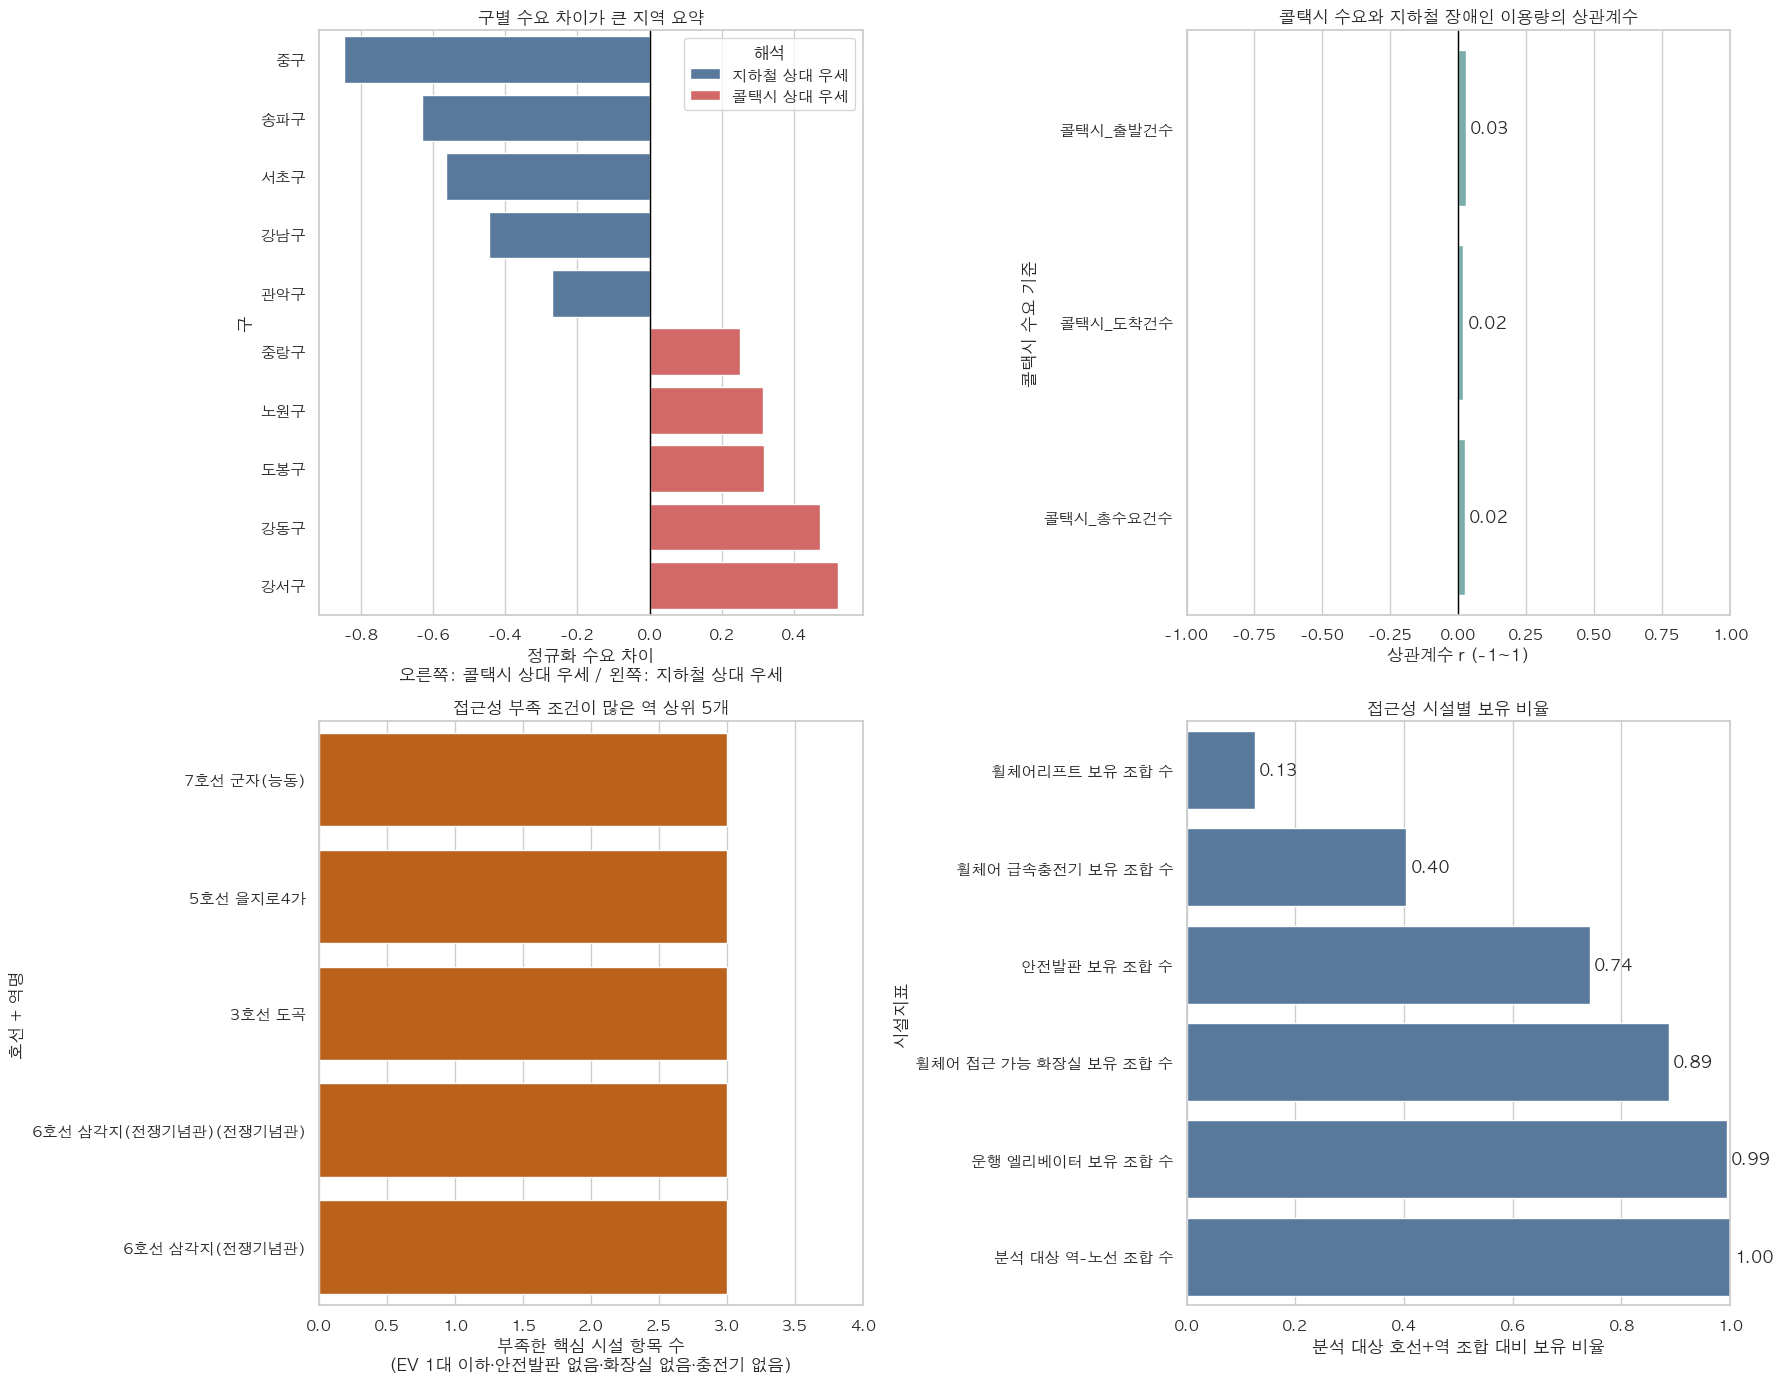

#### 5-1-1 결과: 핵심 분석 결과 종합

**결과 해석**

- 콜택시 총수요가 가장 큰 구는 노원구이며, 총수요는 297,243건이다.
- 지하철 장애인 총 승하차인원수가 가장 큰 구는 중구이며, 총 승하차인원수는 4,363,819명이다.
- 콜택시 수요 순위와 지하철 수요 순위 차이가 가장 큰 구는 중구이며, 순위 차이는 23이다.
- 콜택시 총수요와 지하철 장애인 이용량의 상관계수는 0.02로, 구 단위에서 두 수요가 함께 움직이는 정도는 낮다.
- 부족 조건이 많고 이용량도 큰 역으로 먼저 확인되는 곳은 군자(능동)(7호선, 광진구)이다.
- 접근성 시설 중 보유 역 수가 가장 적은 항목은 휠체어리프트 보유 조합 수이며, 19개 역-노선 조합에서 확인된다. 가장 넓게 확인되는 항목은 분석 대상 역-노선 조합 수이다.
- 이 요약은 새 점수나 임의 가중치를 만들지 않고, 앞에서 계산한 수요·상관계수·부족조건·시설 보유 현황을 그대로 묶은 것이다.

**결론**

- 5번 종합 결과에서 가장 중요한 점은 지하철 수요와 콜택시 수요를 하나의 숫자로 합쳐 판단하면 안 된다는 것이다. 구 단위 상관관계가 약하게 나타나므로, 네비게이터는 콜택시 수요가 큰 지역과 지하철 시설 조건이 좋은 지역을 따로 계산한 뒤 사용자 상황에 맞게 비교해야 한다. 또한 역-노선 조합 단위에서는 이용량이 큰데 부족 조건이 많은 조합을 먼저 확인해야 하며, 시설 수뿐 아니라 연결층과 설치 위치까지 안내해야 실제 이동 판단에 도움이 된다.

**유의미성**

- 이 종합은 개발 단계로 넘어가기 위한 기준 정리에 유의미하다. 어떤 지역에서 콜택시 수요를 더 조심스럽게 봐야 하는지, 어떤 역에서 지하철 이용 안내를 더 자세히 해야 하는지, 어떤 시설 정보가 부족한지를 한 번에 확인할 수 있기 때문이다. 다만 최종 경로 추천을 확정하려면 실시간성과 개인 이동 조건 데이터가 추가로 필요하다.

**이 결과를 바탕으로 이어볼 분석**

- 네비게이터에 직접 쓸 수 있는 핵심 입력값과 보조 자료를 구분한다.
- 구 단위 후보를 먼저 좁힌 뒤, 해당 구 안의 역-노선 조합별 시설 상세 후보로 내려간다.
- 실제 추천 단계에서는 현재 분석에 없는 콜택시 대기시간, 실시간 열차 시간, 엘리베이터 운행 상태, 출입구 위치 정보를 추가로 붙인다.

In [49]:
# 5번은 새 점수를 만들지 않고, 앞선 분석에서 계산한 원자료 기반 지표를 요약한다.
summary_corr = plot_data[[
    '콜택시_출발건수', '콜택시_도착건수', '콜택시_총수요건수', '지하철_장애인총승하차인원수'
]].corr(numeric_only=True)['지하철_장애인총승하차인원수'].drop('지하철_장애인총승하차인원수')

summary_district = district_need_view[[
    '지역명', '콜택시_출발건수', '콜택시_도착건수', '콜택시_총수요건수',
    '지하철_장애인총승하차인원수', '지하철_역수', '구_접근성부족비율_단순', '구내이동비율'
]].copy()
summary_district['콜택시수요순위'] = summary_district['콜택시_총수요건수'].rank(ascending=False, method='min').astype(int)
summary_district['지하철수요순위'] = summary_district['지하철_장애인총승하차인원수'].rank(ascending=False, method='min').astype(int)
summary_district['수요순위차이'] = summary_district['콜택시수요순위'] - summary_district['지하철수요순위']
summary_district_view = pd.concat([summary_district.nlargest(5, '콜택시_총수요건수').assign(구분='콜택시 총수요 상위 5개 구'), summary_district.nsmallest(5, '콜택시_총수요건수').assign(구분='콜택시 총수요 하위 5개 구')], ignore_index=True)

summary_station_risk = risk[[
    '노선명', '역명', '지역명', '장애인총승하차인원수', '부족조건개수',
    '엘리베이터부족여부', '안전발판부족여부', '화장실부족여부', '충전기부족여부'
]].sort_values(['부족조건개수', '장애인총승하차인원수'], ascending=[False, False]).head(5)

summary_facility = facility_summary_df.loc[facility_summary_df['시설지표'].ne('분석 대상 역 수')].copy()
summary_facility['전체대상대비보유비율'] = summary_facility['역수'] / facility_total
summary_facility = summary_facility.sort_values('역수')

print('구 단위 핵심 요약: 콜택시 총수요 상위 5개·하위 5개 구')
display(summary_district_view)
print('역 단위 핵심 요약: 부족 조건이 많고 이용량도 큰 역-노선 조합 5개')
display(summary_station_risk)
print('시설 단위 핵심 요약: 시설별 보유 역 수와 비율')
display(summary_facility)
print('수요 관계 요약: 콜택시 수요와 지하철 장애인 이용량 상관계수')
display(summary_corr.rename('상관계수').reset_index().rename(columns={'index': '콜택시 수요 기준'}))

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1) 구별 수요 차이 요약: 산점도 대신 차이가 큰 구만 막대그래프로 보여준다.
summary_gap_plot = summary_district.copy()
summary_gap_plot['지하철수요_정규화'] = summary_gap_plot['지하철_장애인총승하차인원수'] / summary_gap_plot['지하철_장애인총승하차인원수'].max()
summary_gap_plot['콜택시수요_정규화'] = summary_gap_plot['콜택시_총수요건수'] / summary_gap_plot['콜택시_총수요건수'].max()
summary_gap_plot['콜택시_지하철_상대차이'] = summary_gap_plot['콜택시수요_정규화'] - summary_gap_plot['지하철수요_정규화']
summary_gap_top_bottom = pd.concat([
    summary_gap_plot.nlargest(5, '콜택시_지하철_상대차이').assign(구분='콜택시 쪽 상대 우세'),
    summary_gap_plot.nsmallest(5, '콜택시_지하철_상대차이').assign(구분='지하철 쪽 상대 우세'),
], ignore_index=True).sort_values('콜택시_지하철_상대차이')
summary_gap_top_bottom['색상구분'] = np.where(summary_gap_top_bottom['콜택시_지하철_상대차이'].gt(0), '콜택시 상대 우세', '지하철 상대 우세')

sns.barplot(
    data=summary_gap_top_bottom,
    y='지역명',
    x='콜택시_지하철_상대차이',
    hue='색상구분',
    dodge=False,
    palette={'콜택시 상대 우세': '#E45756', '지하철 상대 우세': '#4C78A8'},
    ax=axes[0, 0],
)
axes[0, 0].axvline(0, color='black', linewidth=1)
axes[0, 0].set_title('구별 수요 차이가 큰 지역 요약')
axes[0, 0].set_xlabel('정규화 수요 차이\n오른쪽: 콜택시 상대 우세 / 왼쪽: 지하철 상대 우세')
axes[0, 0].set_ylabel('구')
axes[0, 0].legend(title='해석')

# 2) 상관계수 요약: 출발·도착·총수요 중 어떤 기준도 지하철 수요와 강하게 맞물리는지 확인한다.
summary_corr_plot = summary_corr.rename('상관계수').reset_index().rename(columns={'index': '콜택시 수요 기준'})
sns.barplot(data=summary_corr_plot, y='콜택시 수요 기준', x='상관계수', color='#72B7B2', ax=axes[0, 1])
axes[0, 1].axvline(0, color='black', linewidth=1)
axes[0, 1].set_xlim(-1, 1)
axes[0, 1].set_title('콜택시 수요와 지하철 장애인 이용량의 상관계수')
axes[0, 1].set_xlabel('상관계수 r (-1~1)')
axes[0, 1].set_ylabel('콜택시 수요 기준')
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt='%.2f', padding=3)

# 3) 접근성 부족 역 요약: 전체 역을 모두 찍지 않고, 부족 조건이 많은 상위 5개만 보여준다.
summary_station_risk_plot = summary_station_risk.copy()
summary_station_risk_plot['역표시명'] = summary_station_risk_plot['노선명'] + ' ' + summary_station_risk_plot['역명']
summary_station_risk_plot = summary_station_risk_plot.sort_values('부족조건개수', ascending=True)
sns.barplot(data=summary_station_risk_plot, y='역표시명', x='부족조건개수', color='#D55E00', ax=axes[1, 0])
axes[1, 0].set_xlim(0, 4)
axes[1, 0].set_title('접근성 부족 조건이 많은 역 상위 5개')
axes[1, 0].set_xlabel('부족한 핵심 시설 항목 수\n(EV 1대 이하·안전발판 없음·화장실 없음·충전기 없음)')
axes[1, 0].set_ylabel('호선 + 역명')

# 4) 시설별 보유 비율: 사용자가 보기 괜찮다고 한 오른쪽 아래 그래프는 유지한다.
sns.barplot(data=summary_facility, y='시설지표', x='전체대상대비보유비율', color='#4C78A8', ax=axes[1, 1])
axes[1, 1].set_title('접근성 시설별 보유 비율')
axes[1, 1].set_xlabel('분석 대상 호선+역 조합 대비 보유 비율')
axes[1, 1].set_ylabel('시설지표')
axes[1, 1].set_xlim(0, 1)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

summary_risk = risk.sort_values(['부족조건개수', '장애인총승하차인원수'], ascending=[False, False]).iloc[0]
facility_lowest = summary_facility.sort_values('역수').iloc[0]
facility_highest = summary_facility.sort_values('역수', ascending=False).iloc[0]
top_taxi_district = summary_district.sort_values('콜택시_총수요건수', ascending=False).iloc[0]
top_subway_district = summary_district.sort_values('지하철_장애인총승하차인원수', ascending=False).iloc[0]
rank_gap_district = summary_district.reindex(summary_district['수요순위차이'].abs().sort_values(ascending=False).index).iloc[0]
weak_relation_text = '낮다' if abs(summary_corr['콜택시_총수요건수']) < 0.3 else '뚜렷한 편이다'

show_result(
    '5-1-1 결과: 핵심 분석 결과 종합',
    [
        f'콜택시 총수요가 가장 큰 구는 {top_taxi_district["지역명"]}이며, 총수요는 {top_taxi_district["콜택시_총수요건수"]:,.0f}건이다.',
        f'지하철 장애인 총 승하차인원수가 가장 큰 구는 {top_subway_district["지역명"]}이며, 총 승하차인원수는 {top_subway_district["지하철_장애인총승하차인원수"]:,.0f}명이다.',
        f'콜택시 수요 순위와 지하철 수요 순위 차이가 가장 큰 구는 {rank_gap_district["지역명"]}이며, 순위 차이는 {rank_gap_district["수요순위차이"]:.0f}이다.',
        f'콜택시 총수요와 지하철 장애인 이용량의 상관계수는 {summary_corr["콜택시_총수요건수"]:.2f}로, 구 단위에서 두 수요가 함께 움직이는 정도는 {weak_relation_text}.',
        f'부족 조건이 많고 이용량도 큰 역으로 먼저 확인되는 곳은 {summary_risk["역명"]}({summary_risk["노선명"]}, {summary_risk["지역명"]})이다.',
        f'접근성 시설 중 보유 역 수가 가장 적은 항목은 {facility_lowest["시설지표"]}이며, {facility_lowest["역수"]:,.0f}개 역-노선 조합에서 확인된다. 가장 넓게 확인되는 항목은 {facility_highest["시설지표"]}이다.',
        '이 요약은 새 점수나 임의 가중치를 만들지 않고, 앞에서 계산한 수요·상관계수·부족조건·시설 보유 현황을 그대로 묶은 것이다.',
    ],
    [
        '네비게이터에 직접 쓸 수 있는 핵심 입력값과 보조 자료를 구분한다.',
        '구 단위 후보를 먼저 좁힌 뒤, 해당 구 안의 역-노선 조합별 시설 상세 후보로 내려간다.',
        '실제 추천 단계에서는 현재 분석에 없는 콜택시 대기시간, 실시간 열차 시간, 엘리베이터 운행 상태, 출입구 위치 정보를 추가로 붙인다.',
    ],
    conclusion='5번 종합 결과에서 가장 중요한 점은 지하철 수요와 콜택시 수요를 하나의 숫자로 합쳐 판단하면 안 된다는 것이다. 구 단위 상관관계가 약하게 나타나므로, 네비게이터는 콜택시 수요가 큰 지역과 지하철 시설 조건이 좋은 지역을 따로 계산한 뒤 사용자 상황에 맞게 비교해야 한다. 또한 역-노선 조합 단위에서는 이용량이 큰데 부족 조건이 많은 조합을 먼저 확인해야 하며, 시설 수뿐 아니라 연결층과 설치 위치까지 안내해야 실제 이동 판단에 도움이 된다.',
    significance='이 종합은 개발 단계로 넘어가기 위한 기준 정리에 유의미하다. 어떤 지역에서 콜택시 수요를 더 조심스럽게 봐야 하는지, 어떤 역에서 지하철 이용 안내를 더 자세히 해야 하는지, 어떤 시설 정보가 부족한지를 한 번에 확인할 수 있기 때문이다. 다만 최종 경로 추천을 확정하려면 실시간성과 개인 이동 조건 데이터가 추가로 필요하다.'
)


#### 5-1-2. 지하철 혼잡도와 저상버스 혼잡 부담 요약

앞선 요약은 수요와 접근성 시설 중심이었기 때문에, 여기서는 네비게이터 판단에 직접 연결되는 혼잡 관련 결과를 따로 정리한다.

정리 기준은 두 가지다.

- 지하철 혼잡도: 서울교통공사 혼잡도 데이터의 실제 시간대별 혼잡도 값
- 저상버스 혼잡 부담: 버스 승하차 인원과 정류장 순서로 추정한 `저상버스 1대당 추정 재차인원`

주의할 점은 두 지표의 성격이 다르다는 것이다. 지하철은 실제 혼잡도 값이고, 저상버스는 실제 차내 혼잡률이 아니라 공급 대비 수요 부담을 보는 대체 지표다.


지하철 혼잡도 요약: 최대 혼잡도 상위 5개 역


,역표시명,지역명,최대혼잡도,평균혼잡도,장애인총승하차인원수,운행엘리베이터수
68,5호선 마포,마포구,164.3,33.115665,191808,2
62,5호선 공덕,마포구,149.1,32.295708,165443,2
7,2호선 방배,서초구,147.3,45.365880,198199,3
10,2호선 서초,서초구,145.7,45.409657,253033,4
90,7호선 가산디지털단지,금천구,141.3,33.112983,505802,4


저상버스 혼잡 부담 요약: 저상버스 1대당 추정 재차인원 상위 5개 노선


,노선표시명,노선명,시간대,방향,역명,추정재차인원_보정,저상버스대수,저상버스비율,저상버스1대당_추정재차인원
0,3317번,3317(남한산성입구~잠실새내역),8,잠실새내역,가락쌍용1차아파트(00011),58394,1,0.090909,58394.0
1,8561번,8561번(신림동~여의도환승센터),7,여의도환승센터,공군호텔(00009),55026,1,0.250000,55026.0
2,2112번,2112번(면목동~성북동),18,면목동,장한평역3번출구(00091),96765,2,0.142857,48382.5
3,8551번,8551번(봉천역~노량진역),7,노량진역,상도2동아이파크.포스코더샵아파트(00008),43695,1,0.200000,43695.0
4,6613번,6613(양천공영차고지~대림역),7,대림역,은정초등학교(00030),39676,1,0.100000,39676.0


지하철-저상버스 보완 가능성 요약


,보완가능성분류,역조합수,평균지하철최고혼잡도,평균대안노선수
0,저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요,70,112.350000,26.1
1,지하철 우선 가능: 큰 불편 없음 + 저상버스 대안 없음,4,76.475000,0.0
2,콜택시 우선 검토: 지하철 불편 + 저상버스 대안 없음,37,67.727027,0.0


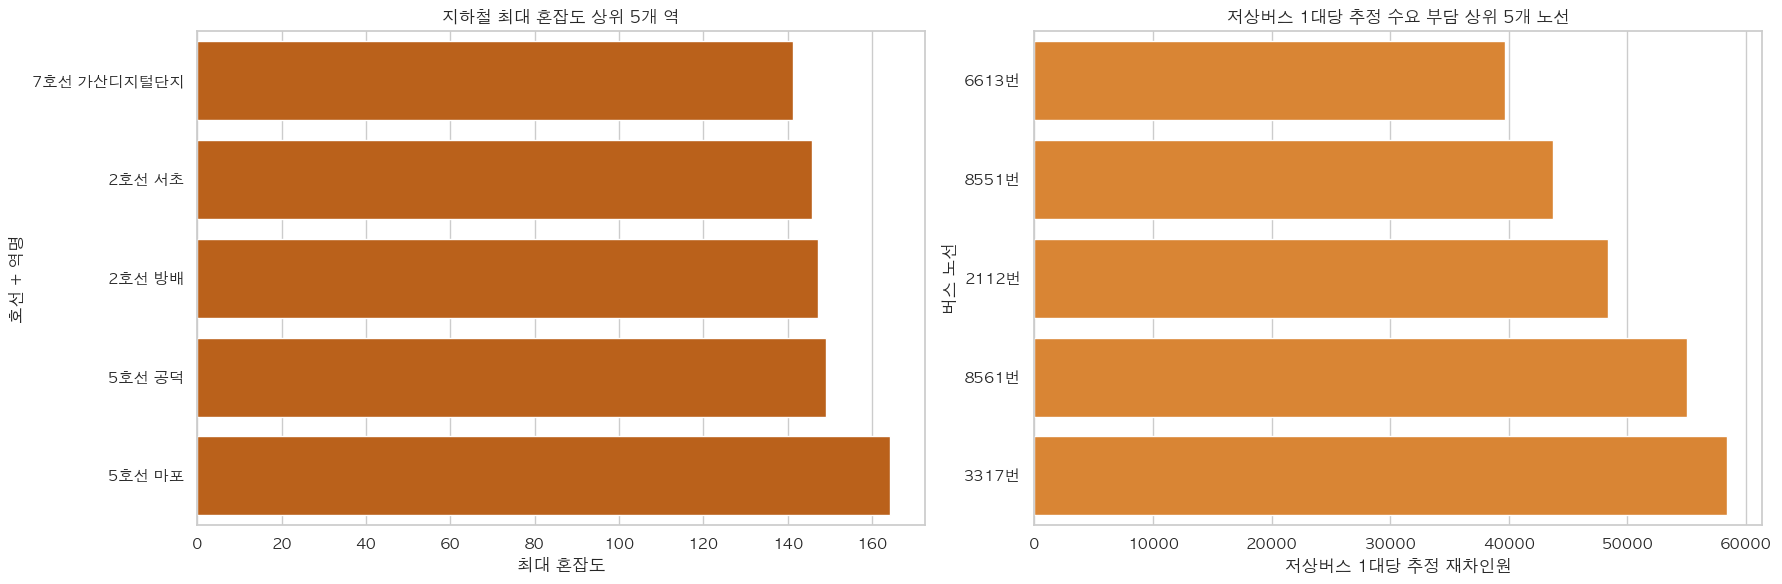

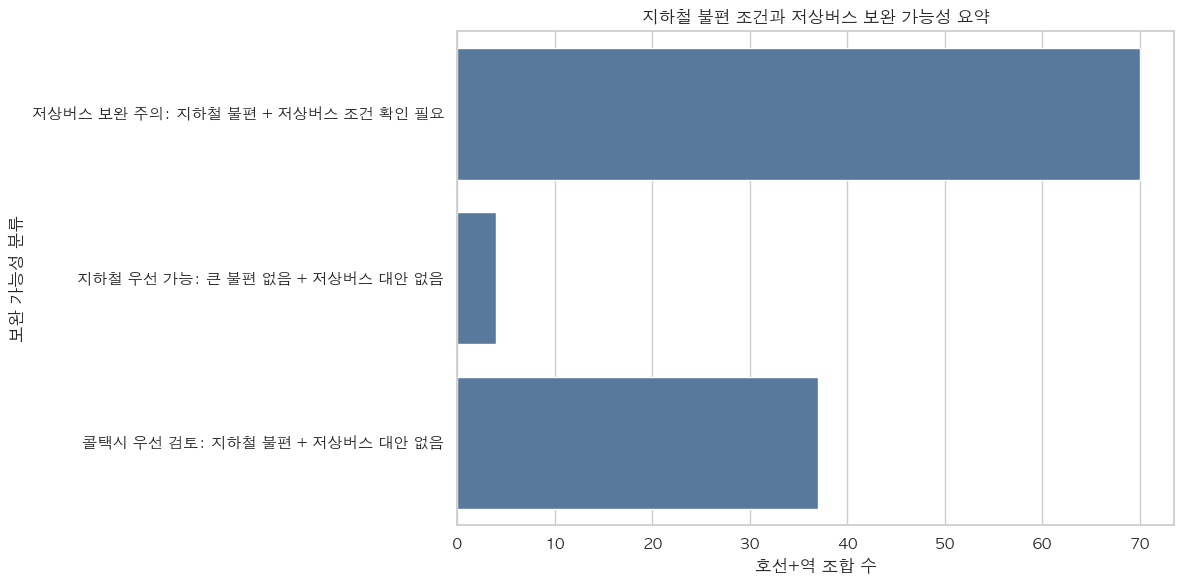

#### 5-1-2 결과: 지하철 혼잡도와 저상버스 혼잡 부담 요약

**결과 해석**

- 지하철 최대 혼잡도가 가장 높은 후보는 5호선 마포이며, 최대 혼잡도는 164.3이다.
- 저상버스 1대당 추정 수요 부담이 가장 큰 후보는 3317번이며, 8시 기준 저상버스 1대당 추정 재차인원은 58,394명이다.
- 지하철 불편 조건에서 저상버스 보완 가능으로 분류된 조합은 0개, 보완 주의 조합은 70개다.
- 지하철도 불편하고 주변 저상버스 대안도 확인되지 않아 콜택시 우선 검토로 분류된 조합은 37개다.

**결론**

- 혼잡 관련 요약을 따로 보면, 지하철과 저상버스를 단순히 어느 쪽 수요가 큰지로 비교하는 것이 아니라 실제 추천 상황에서 어떤 대안을 보여줘야 하는지 판단할 수 있다. 지하철 혼잡도가 높아도 저상버스 조건이 양호하면 버스 대안을 제시할 수 있고, 저상버스도 부담이 크거나 대안이 없으면 콜택시 비교가 필요하다.

**유의미성**

- 이 요약은 개발 로직으로 바로 연결된다. 사용자가 특정 시간대에 이동하려 할 때 지하철 혼잡도, 저상버스 공급 부담, 콜택시 대기 조건을 함께 비교하는 구조의 근거가 된다.

**이 결과를 바탕으로 이어볼 분석**

- 지하철 혼잡도는 실제 혼잡도 값이므로 시간대 회피 안내에 직접 활용한다.
- 저상버스 혼잡 부담은 실제 차내 혼잡률이 아니라 승하차 기반 추정 지표이므로 보조 경고로 사용한다.
- 지하철 혼잡 + 저상버스 보완 주의 또는 대안 없음인 경우 콜택시 비교를 함께 제공한다.

In [50]:
summary_subway_congestion = peak_station_top5[[
    '노선명', '출발역', '지역명', '최대혼잡도', '평균혼잡도', '장애인총승하차인원수', '운행엘리베이터수'
]].copy()
summary_subway_congestion['역표시명'] = summary_subway_congestion['노선명'] + ' ' + summary_subway_congestion['출발역']

summary_bus_congestion = lowfloor_peak_top5[[
    '노선번호', '노선명', '시간대', '방향', '역명', '추정재차인원_보정',
    '저상버스대수', '저상버스비율', '저상버스1대당_추정재차인원'
]].copy()
summary_bus_congestion['노선표시명'] = summary_bus_congestion['노선번호'].astype(str) + '번'

summary_complement = complement_summary.copy()

print('지하철 혼잡도 요약: 최대 혼잡도 상위 5개 역')
display(summary_subway_congestion[[
    '역표시명', '지역명', '최대혼잡도', '평균혼잡도', '장애인총승하차인원수', '운행엘리베이터수'
]])
print('저상버스 혼잡 부담 요약: 저상버스 1대당 추정 재차인원 상위 5개 노선')
display(summary_bus_congestion[[
    '노선표시명', '노선명', '시간대', '방향', '역명', '추정재차인원_보정',
    '저상버스대수', '저상버스비율', '저상버스1대당_추정재차인원'
]])
print('지하철-저상버스 보완 가능성 요약')
display(summary_complement)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
subway_plot = summary_subway_congestion.sort_values('최대혼잡도')
sns.barplot(data=subway_plot, y='역표시명', x='최대혼잡도', color='#D55E00', ax=axes[0])
axes[0].set_title('지하철 최대 혼잡도 상위 5개 역')
axes[0].set_xlabel('최대 혼잡도')
axes[0].set_ylabel('호선 + 역명')

bus_plot = summary_bus_congestion.sort_values('저상버스1대당_추정재차인원')
sns.barplot(data=bus_plot, y='노선표시명', x='저상버스1대당_추정재차인원', color='#F58518', ax=axes[1])
axes[1].set_title('저상버스 1대당 추정 수요 부담 상위 5개 노선')
axes[1].set_xlabel('저상버스 1대당 추정 재차인원')
axes[1].set_ylabel('버스 노선')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=summary_complement, y='보완가능성분류', x='역조합수', color='#4C78A8')
plt.title('지하철 불편 조건과 저상버스 보완 가능성 요약')
plt.xlabel('호선+역 조합 수')
plt.ylabel('보완 가능성 분류')
plt.tight_layout()
plt.show()

top_subway_congestion_summary = summary_subway_congestion.sort_values('최대혼잡도', ascending=False).iloc[0]
top_bus_congestion_summary = summary_bus_congestion.sort_values('저상버스1대당_추정재차인원', ascending=False).iloc[0]
complement_possible_count = int(summary_complement.loc[
    summary_complement['보완가능성분류'].eq('저상버스 보완 가능: 지하철 불편 + 저상버스 조건 양호'),
    '역조합수'
].sum())
complement_caution_count = int(summary_complement.loc[
    summary_complement['보완가능성분류'].eq('저상버스 보완 주의: 지하철 불편 + 저상버스 조건 확인 필요'),
    '역조합수'
].sum())

taxi_first_count = int(summary_complement.loc[
    summary_complement['보완가능성분류'].eq('콜택시 우선 검토: 지하철 불편 + 저상버스 대안 없음'),
    '역조합수'
].sum())

show_result(
    '5-1-2 결과: 지하철 혼잡도와 저상버스 혼잡 부담 요약',
    [
        f'지하철 최대 혼잡도가 가장 높은 후보는 {top_subway_congestion_summary["역표시명"]}이며, 최대 혼잡도는 {top_subway_congestion_summary["최대혼잡도"]:.1f}이다.',
        f'저상버스 1대당 추정 수요 부담이 가장 큰 후보는 {top_bus_congestion_summary["노선표시명"]}이며, {int(top_bus_congestion_summary["시간대"])}시 기준 저상버스 1대당 추정 재차인원은 {top_bus_congestion_summary["저상버스1대당_추정재차인원"]:,.0f}명이다.',
        f'지하철 불편 조건에서 저상버스 보완 가능으로 분류된 조합은 {complement_possible_count:,}개, 보완 주의 조합은 {complement_caution_count:,}개다.',
        f'지하철도 불편하고 주변 저상버스 대안도 확인되지 않아 콜택시 우선 검토로 분류된 조합은 {taxi_first_count:,}개다.',
    ],
    [
        '지하철 혼잡도는 실제 혼잡도 값이므로 시간대 회피 안내에 직접 활용한다.',
        '저상버스 혼잡 부담은 실제 차내 혼잡률이 아니라 승하차 기반 추정 지표이므로 보조 경고로 사용한다.',
        '지하철 혼잡 + 저상버스 보완 주의 또는 대안 없음인 경우 콜택시 비교를 함께 제공한다.',
    ],
    conclusion='혼잡 관련 요약을 따로 보면, 지하철과 저상버스를 단순히 어느 쪽 수요가 큰지로 비교하는 것이 아니라 실제 추천 상황에서 어떤 대안을 보여줘야 하는지 판단할 수 있다. 지하철 혼잡도가 높아도 저상버스 조건이 양호하면 버스 대안을 제시할 수 있고, 저상버스도 부담이 크거나 대안이 없으면 콜택시 비교가 필요하다.',
    significance='이 요약은 개발 로직으로 바로 연결된다. 사용자가 특정 시간대에 이동하려 할 때 지하철 혼잡도, 저상버스 공급 부담, 콜택시 대기 조건을 함께 비교하는 구조의 근거가 된다.'
)
